In [1]:
import pandas as pd
from glob import glob

In [50]:
metric_mapping = {
    'sanity.data_mismatch.score': 'DataMismatchScore',
    'sanity.common_rows_proportion.score': 'CommonRowsProportion',
    'sanity.nearest_syn_neighbor_distance.mean': 'NearestSyntheticNeighborDistance',
    'sanity.close_values_probability.score': 'CloseValuesProbability',
    'sanity.distant_values_probability.score': 'DistantValuesProbability',
    'stats.jensenshannon_dist.marginal': 'JensenShannonDistance',
    'stats.chi_squared_test.marginal': 'ChiSquaredTest',
    'stats.inv_kl_divergence.marginal': 'InverseKLDivergence',
    'stats.ks_test.marginal': 'KolmogorovSmirnovTest',
    'stats.max_mean_discrepancy.joint': 'MaximumMeanDiscrepancy',
    'stats.wasserstein_dist.joint': 'WassersteinDistance',
    'stats.prdc.precision': 'PRDCScore',
    'stats.prdc.recall': 'PRDCScore',
    'stats.prdc.density': 'PRDCScore',
    'stats.prdc.coverage': 'PRDCScore',
    'stats.alpha_precision.delta_precision_alpha_OC': 'AlphaPrecision',
    'stats.alpha_precision.delta_coverage_beta_OC': 'AlphaPrecision',
    'stats.alpha_precision.authenticity_OC': 'AlphaPrecision',
    'stats.alpha_precision.delta_precision_alpha_naive': 'AlphaPrecision',
    'stats.alpha_precision.delta_coverage_beta_naive': 'AlphaPrecision',
    'stats.alpha_precision.authenticity_naive': 'AlphaPrecision',
    'performance.linear_model.syn_id': 'AugmentationPerformanceEvaluatorLinear',
    'performance.linear_model.syn_ood': 'AugmentationPerformanceEvaluatorLinear',
    'performance.mlp.syn_id': 'AugmentationPerformanceEvaluatorMLP',
    'performance.mlp.syn_ood': 'AugmentationPerformanceEvaluatorMLP',
    'performance.xgb.syn_id': 'AugmentationPerformanceEvaluatorXGB',
    'performance.xgb.syn_ood': 'AugmentationPerformanceEvaluatorXGB',
    'performance.feat_rank_distance.corr': 'FeatureImportanceRankDistance',
    'performance.feat_rank_distance.pvalue': 'FeatureImportanceRankDistance',
    'detection.detection_xgb.mean': 'SyntheticDetectionXGB',
    'detection.detection_mlp.mean': 'SyntheticDetectionMLP',
    'detection.detection_gmm.mean': 'SyntheticDetectionGMM',
    'detection.detection_linear.mean': 'SyntheticDetectionLinear',
    'privacy.delta-presence.score': 'DeltaPresence',
    'privacy.k-anonymization.syn': 'kAnonymization',
    'privacy.k-map.score': 'kMap',
    'privacy.distinct l-diversity.syn': 'lDiversityDistinct',
    'privacy.identifiability_score.score': 'IdentifiabilityScore',
    'privacy.identifiability_score.score_OC': 'IdentifiabilityScore'
}

In [53]:
direction_mapping = {'CloseValuesProbability': 'maximize',
 'CommonRowsProportion': 'minimize',
 'DataMismatchScore': 'minimize',
 'DistantValuesProbability': 'minimize',
 'MetricEvaluator': None,
 'NearestSyntheticNeighborDistance': 'minimize',
 'AlphaPrecision': 'maximize',
 'ChiSquaredTest': 'maximize',
 'FrechetInceptionDistance': 'minimize',
 'InverseKLDivergence': 'maximize',
 'JensenShannonDistance': 'minimize',
 'KolmogorovSmirnovTest': 'maximize',
 'MaximumMeanDiscrepancy': 'minimize',
 'PRDCScore': 'maximize',
 'StatisticalEvaluator': None,
 'SurvivalKMDistance': 'minimize',
 'WassersteinDistance': 'minimize',
 'AugmentationPerformanceEvaluatorLinear': 'maximize',
 'AugmentationPerformanceEvaluatorMLP': 'maximize',
 'AugmentationPerformanceEvaluatorXGB': 'maximize',
 'FeatureImportanceRankDistance': 'minimize',
 'PerformanceEvaluator': 'maximize',
 'PerformanceEvaluatorLinear': 'maximize',
 'PerformanceEvaluatorMLP': 'maximize',
 'PerformanceEvaluatorXGB': 'maximize',
 'DetectionEvaluator': 'minimize',
 'SyntheticDetectionGMM': 'minimize',
 'SyntheticDetectionLinear': 'minimize',
 'SyntheticDetectionMLP': 'minimize',
 'SyntheticDetectionXGB': 'minimize',
 'DeltaPresence': 'maximize',
 'DomiasMIA': 'minimize',
 'DomiasMIABNAF': 'minimize',
 'DomiasMIAKDE': 'minimize',
 'DomiasMIAPrior': 'minimize',
 'IdentifiabilityScore': 'minimize',
 'PrivacyEvaluator': None,
 'kAnonymization': 'maximize',
 'kMap': 'maximize',
 'lDiversityDistinct': 'maximize',
 'AttackEvaluator': None,
 'DataLeakageLinear': 'minimize',
 'DataLeakageMLP': 'minimize',
 'DataLeakageXGB': 'minimize'}

In [4]:
files = glob('../results/*.csv')

In [9]:
pd.read_csv(files[0]).head()

,Metric,Better Results,Magnitude,orig,privgen
0,sanity.data_mismatch.score,results 2,marginally,0.0,0.000000
1,sanity.common_rows_proportion.score,results 2,by far,1.0,0.939072
2,sanity.nearest_syn_neighbor_distance.mean,results 1,marginally,0.0,0.027928
3,sanity.close_values_probability.score,results 1,marginally,1.0,0.954545
4,sanity.distant_values_probability.score,results 1,marginally,0.0,0.012573


In [11]:
names = [file.split('/')[-1].split('.')[0].split('_', 1)[1] for file in files]

In [12]:
names

['dummy_sampler',
 'nflow',
 'ctgan',
 'arf',
 'marginal_distributions',
 'decaf',
 'tvae',
 'adsgan',
 'bayesian_network',
 'rtvae']

In [14]:
df_list = []
for file in files:
    name = file.split('/')[-1].split('.')[0].split('_', 1)[1]
    temp = pd.read_csv(file)
    temp['synthesizer'] = name
    df_list.append(temp)
    
df = pd.concat(df_list)
    

In [15]:
df

,Metric,Better Results,Magnitude,orig,privgen,synthesizer
0,sanity.data_mismatch.score,results 2,marginally,0.000000,0.000000,dummy_sampler
1,sanity.common_rows_proportion.score,results 2,by far,1.000000,0.939072,dummy_sampler
2,sanity.nearest_syn_neighbor_distance.mean,results 1,marginally,0.000000,0.027928,dummy_sampler
3,sanity.close_values_probability.score,results 1,marginally,1.000000,0.954545,dummy_sampler
4,sanity.distant_values_probability.score,results 1,marginally,0.000000,0.012573,dummy_sampler
...,...,...,...,...,...,...
34,privacy.k-anonymization.syn,results 1,by far,15.000000,1.000000,rtvae
35,privacy.k-map.score,results 2,by far,66.000000,144.000000,rtvae
36,privacy.distinct l-diversity.syn,results 1,by far,15.000000,1.000000,rtvae
37,privacy.identifiability_score.score,results 1,marginally,0.004545,0.006770,rtvae


In [18]:
melted_df = pd.melt(
    df,
    id_vars=[col for col in df.columns if col not in ['orig', 'privgen']],  # Keep all other columns
    value_vars=['orig', 'privgen'],  # Columns to stack
    var_name='Source',  # New column indicating whether the value is from 'orig' or 'privgen'
    value_name='Value'  # New column with the values
)

In [19]:
melted_df

,Metric,Better Results,Magnitude,synthesizer,Source,Value
0,sanity.data_mismatch.score,results 2,marginally,dummy_sampler,orig,0.000000
1,sanity.common_rows_proportion.score,results 2,by far,dummy_sampler,orig,1.000000
2,sanity.nearest_syn_neighbor_distance.mean,results 1,marginally,dummy_sampler,orig,0.000000
3,sanity.close_values_probability.score,results 1,marginally,dummy_sampler,orig,1.000000
4,sanity.distant_values_probability.score,results 1,marginally,dummy_sampler,orig,0.000000
...,...,...,...,...,...,...
775,privacy.k-anonymization.syn,results 1,by far,rtvae,privgen,1.000000
776,privacy.k-map.score,results 2,by far,rtvae,privgen,144.000000
777,privacy.distinct l-diversity.syn,results 1,by far,rtvae,privgen,1.000000
778,privacy.identifiability_score.score,results 1,marginally,rtvae,privgen,0.006770


In [27]:
synths = melted_df['synthesizer'].unique().tolist()
metrics = melted_df['Metric'].unique().tolist()

In [31]:
metrics

['sanity.data_mismatch.score',
 'sanity.common_rows_proportion.score',
 'sanity.nearest_syn_neighbor_distance.mean',
 'sanity.close_values_probability.score',
 'sanity.distant_values_probability.score',
 'stats.jensenshannon_dist.marginal',
 'stats.chi_squared_test.marginal',
 'stats.inv_kl_divergence.marginal',
 'stats.ks_test.marginal',
 'stats.max_mean_discrepancy.joint',
 'stats.wasserstein_dist.joint',
 'stats.prdc.precision',
 'stats.prdc.recall',
 'stats.prdc.density',
 'stats.prdc.coverage',
 'stats.alpha_precision.delta_precision_alpha_OC',
 'stats.alpha_precision.delta_coverage_beta_OC',
 'stats.alpha_precision.authenticity_OC',
 'stats.alpha_precision.delta_precision_alpha_naive',
 'stats.alpha_precision.delta_coverage_beta_naive',
 'stats.alpha_precision.authenticity_naive',
 'performance.linear_model.syn_id',
 'performance.linear_model.syn_ood',
 'performance.mlp.syn_id',
 'performance.mlp.syn_ood',
 'performance.xgb.syn_id',
 'performance.xgb.syn_ood',
 'performance.feat_

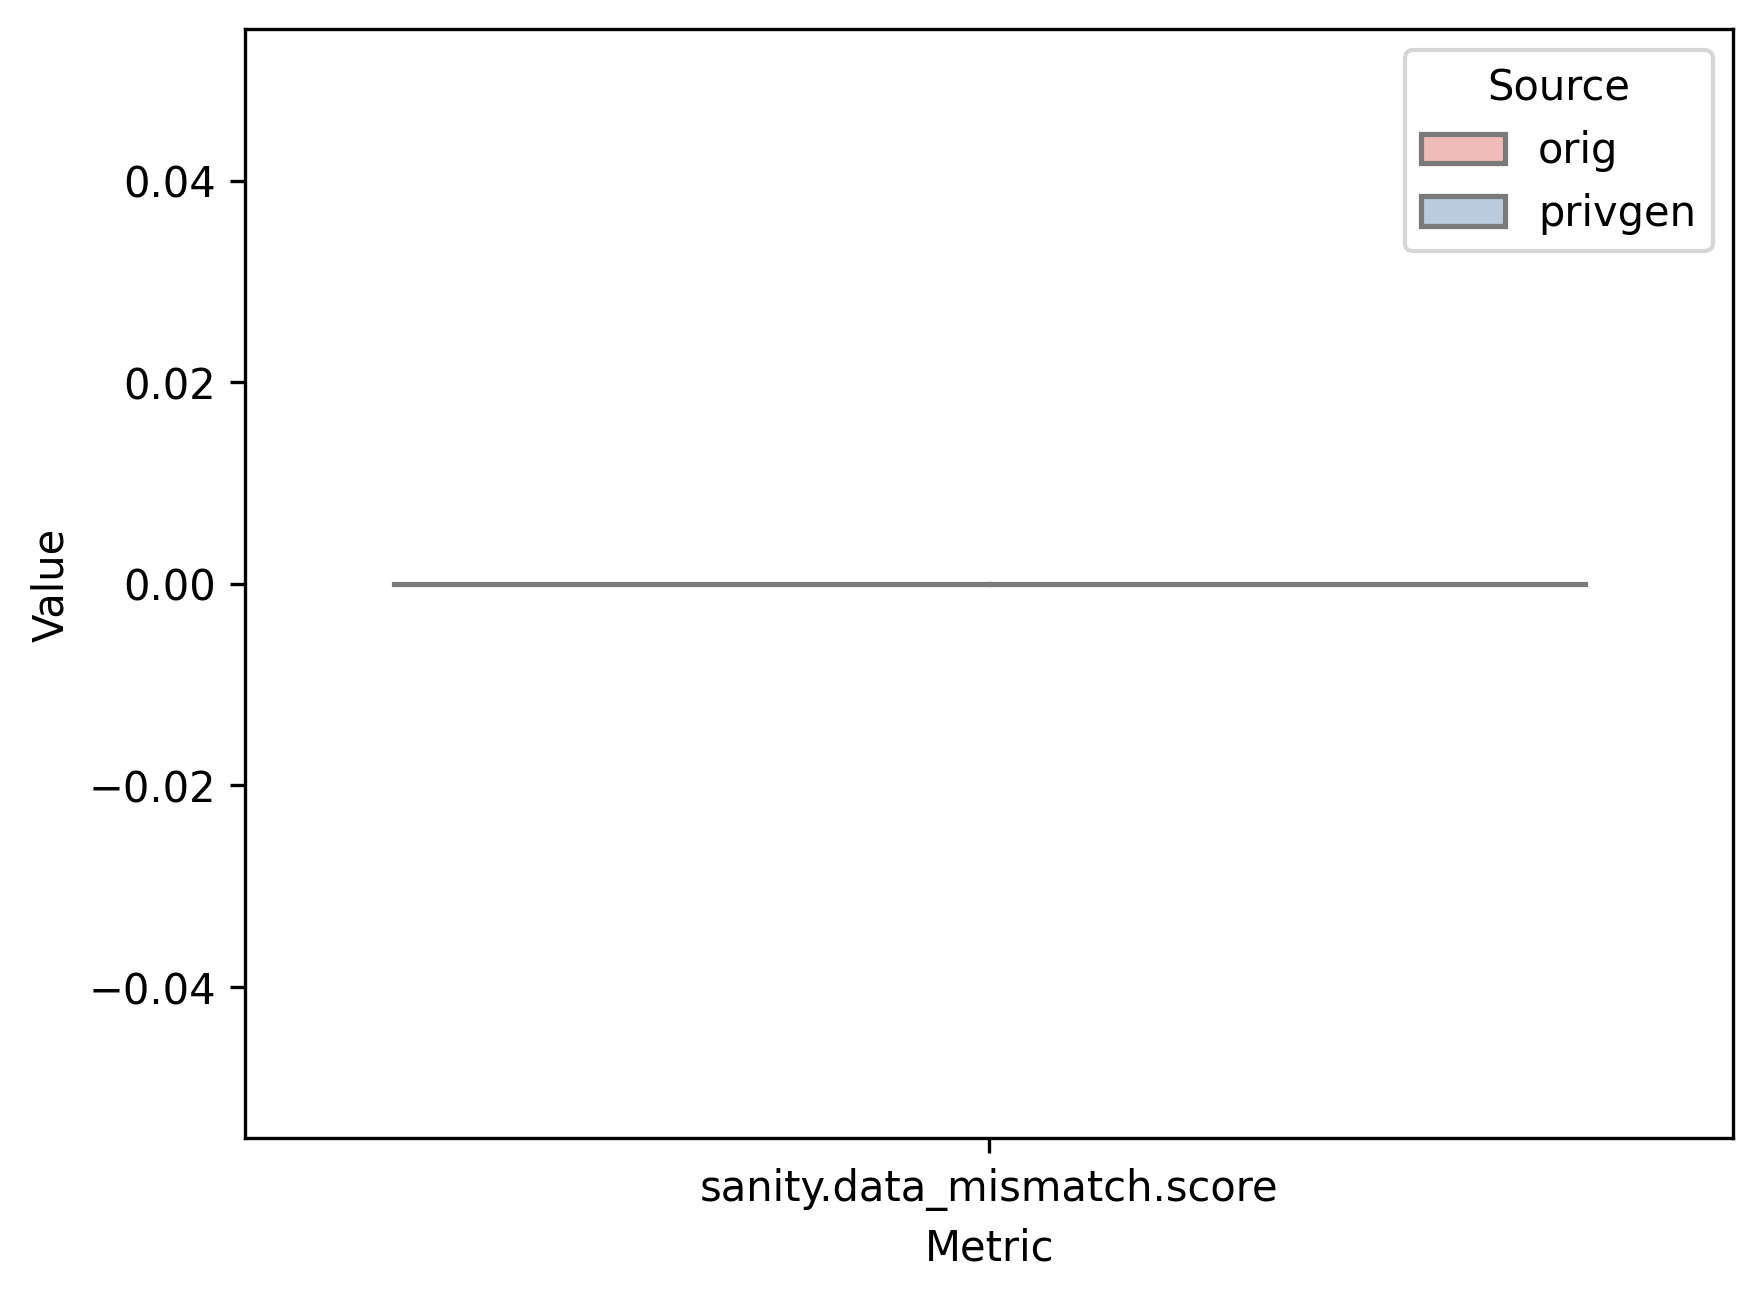

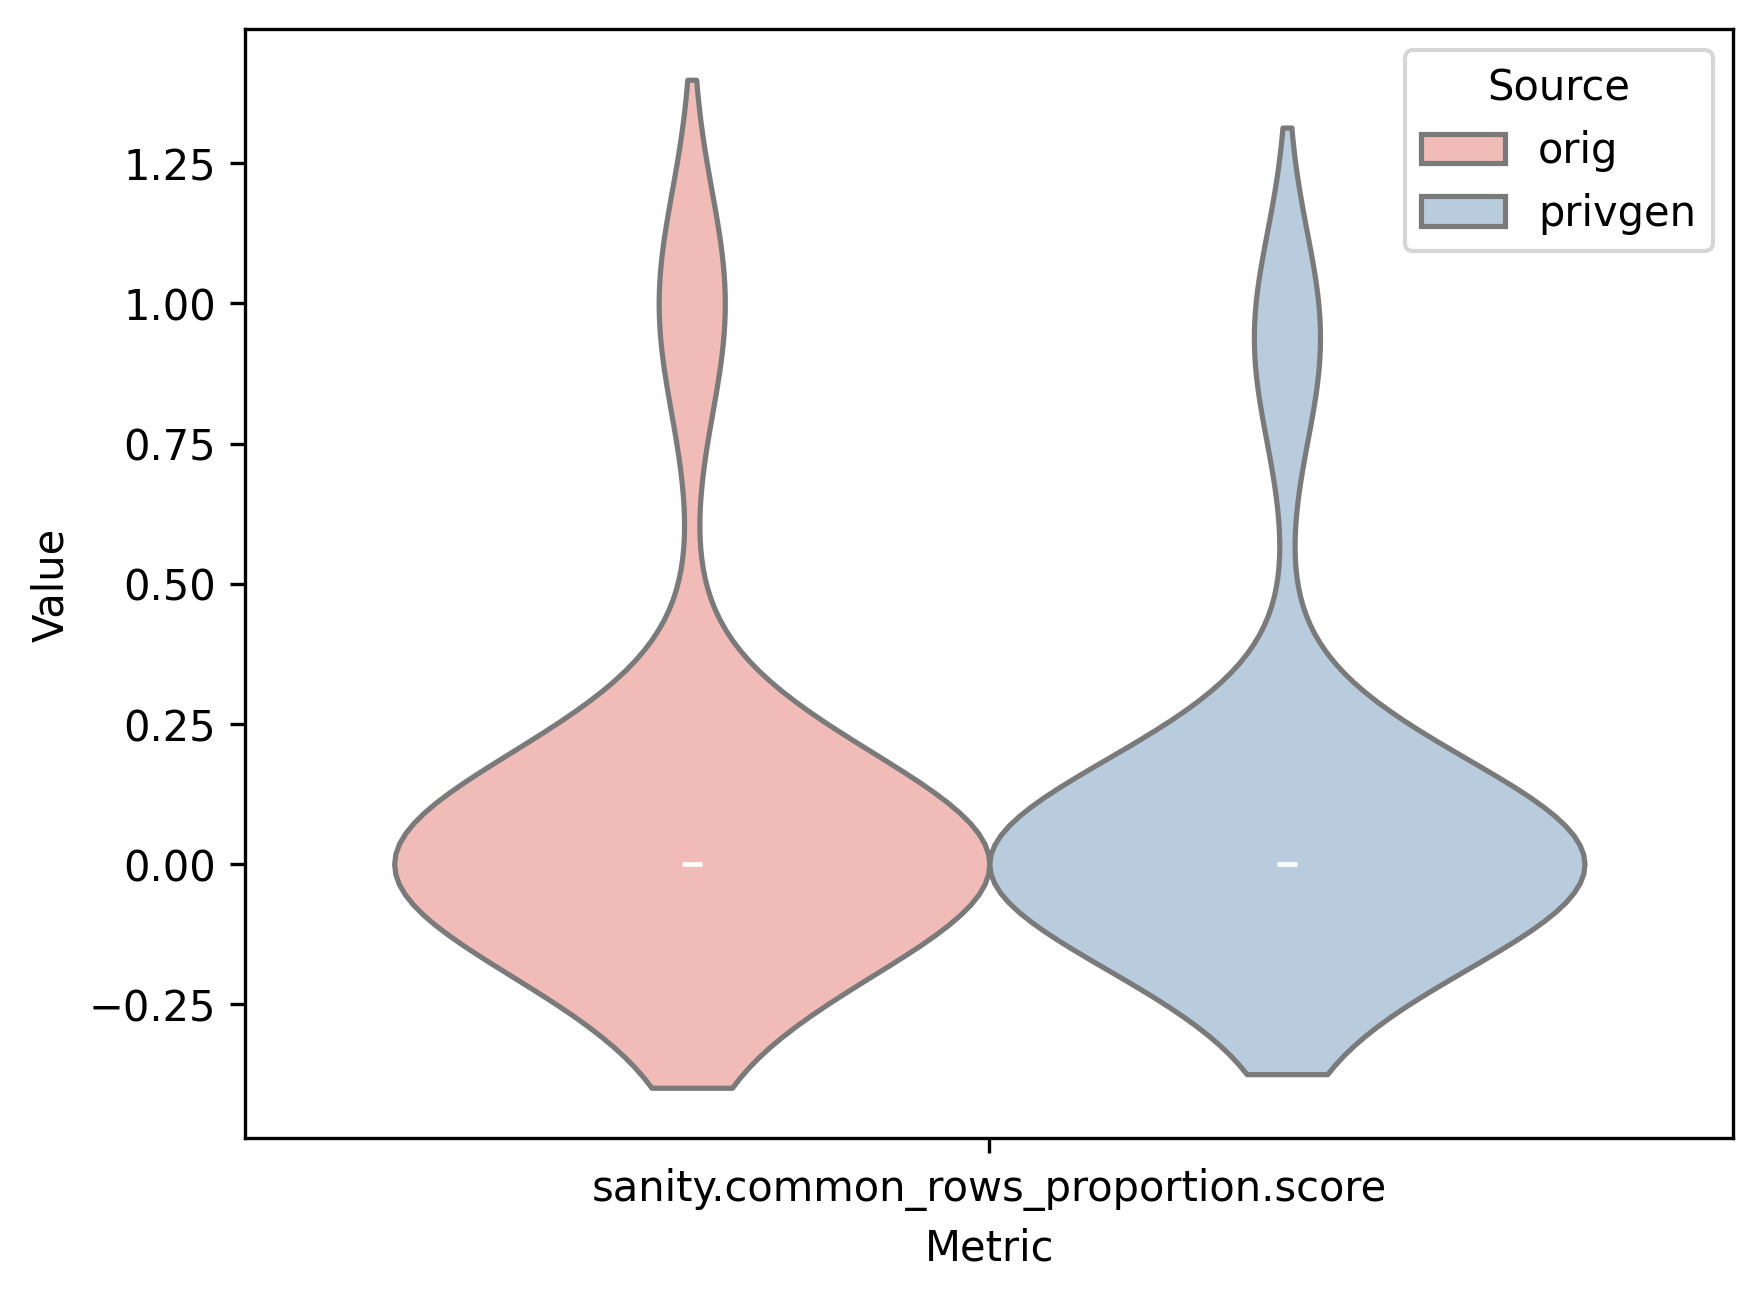

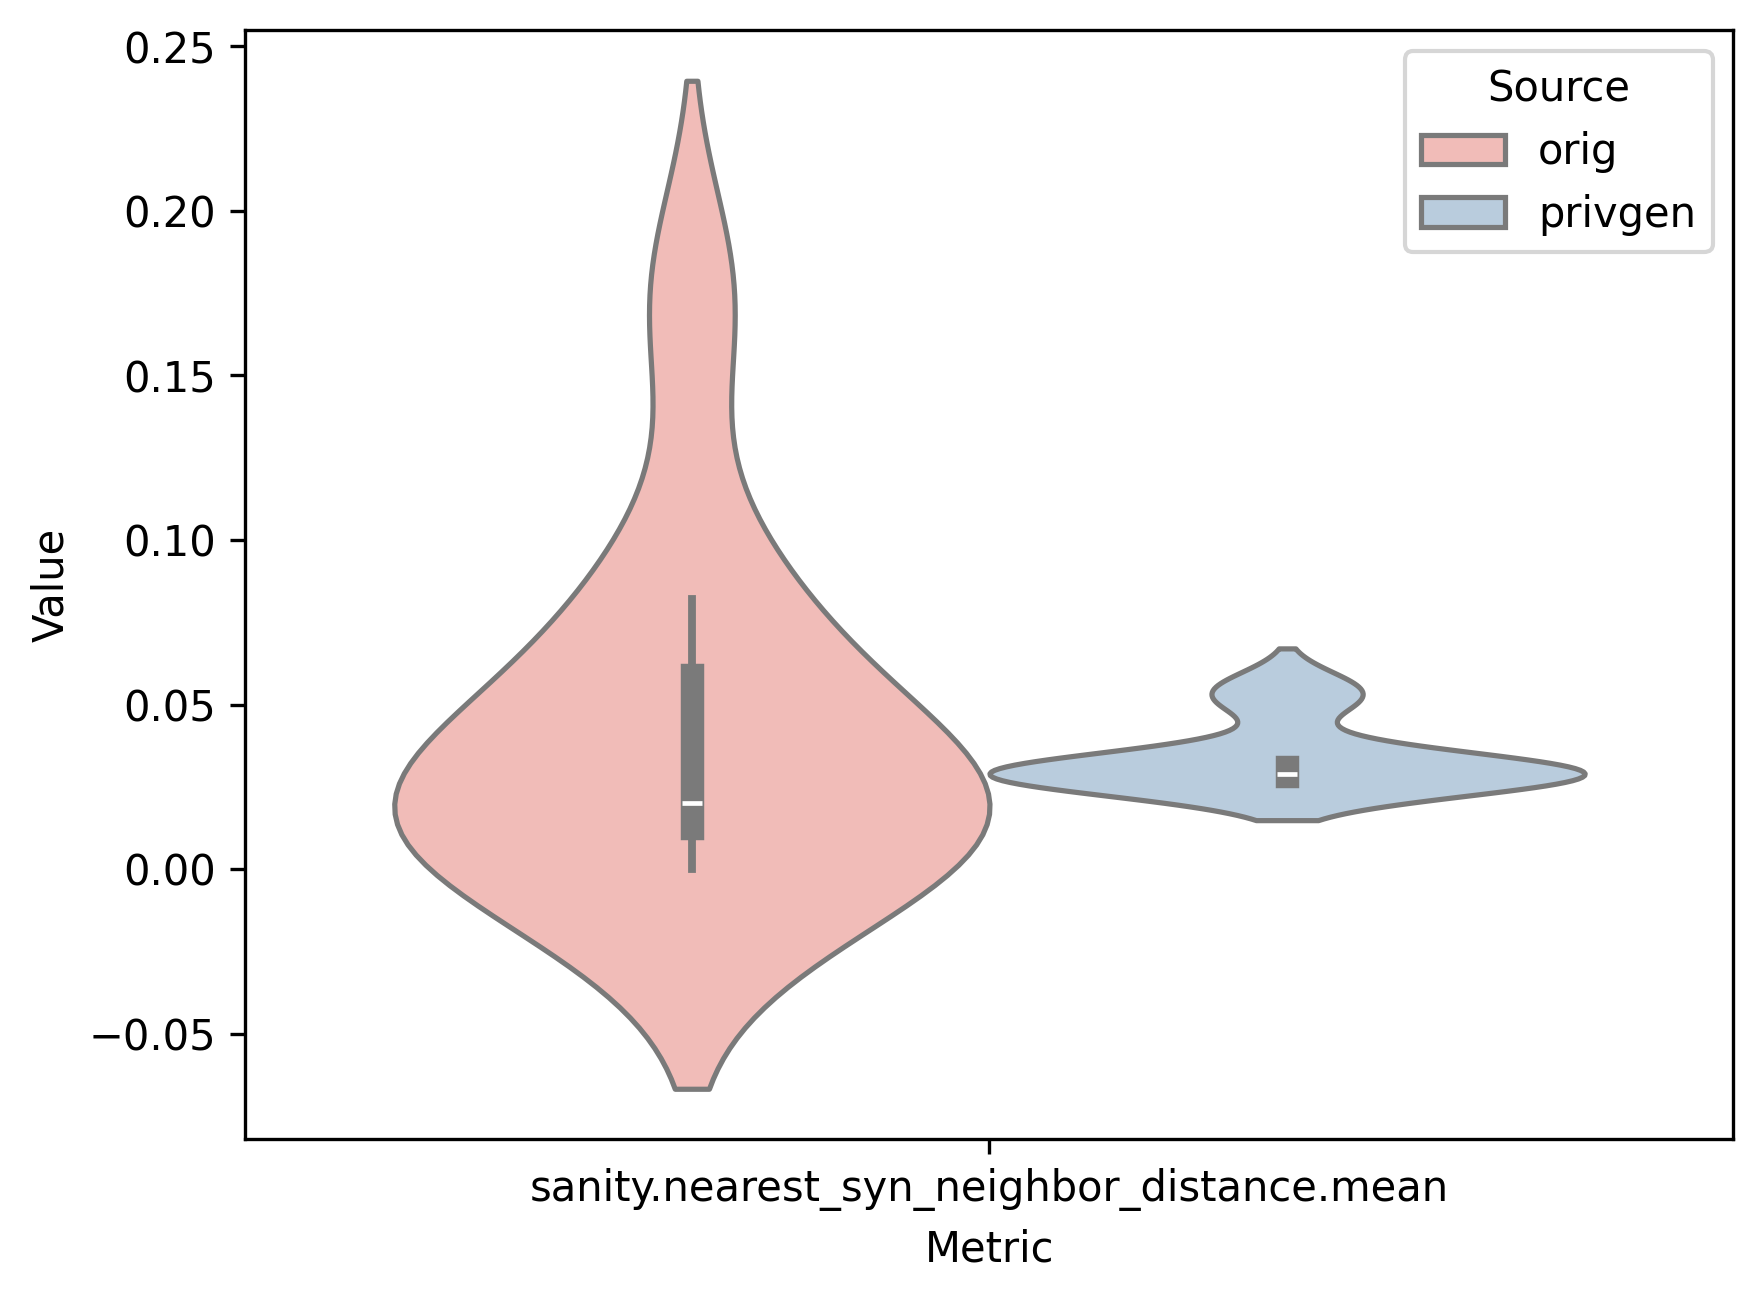

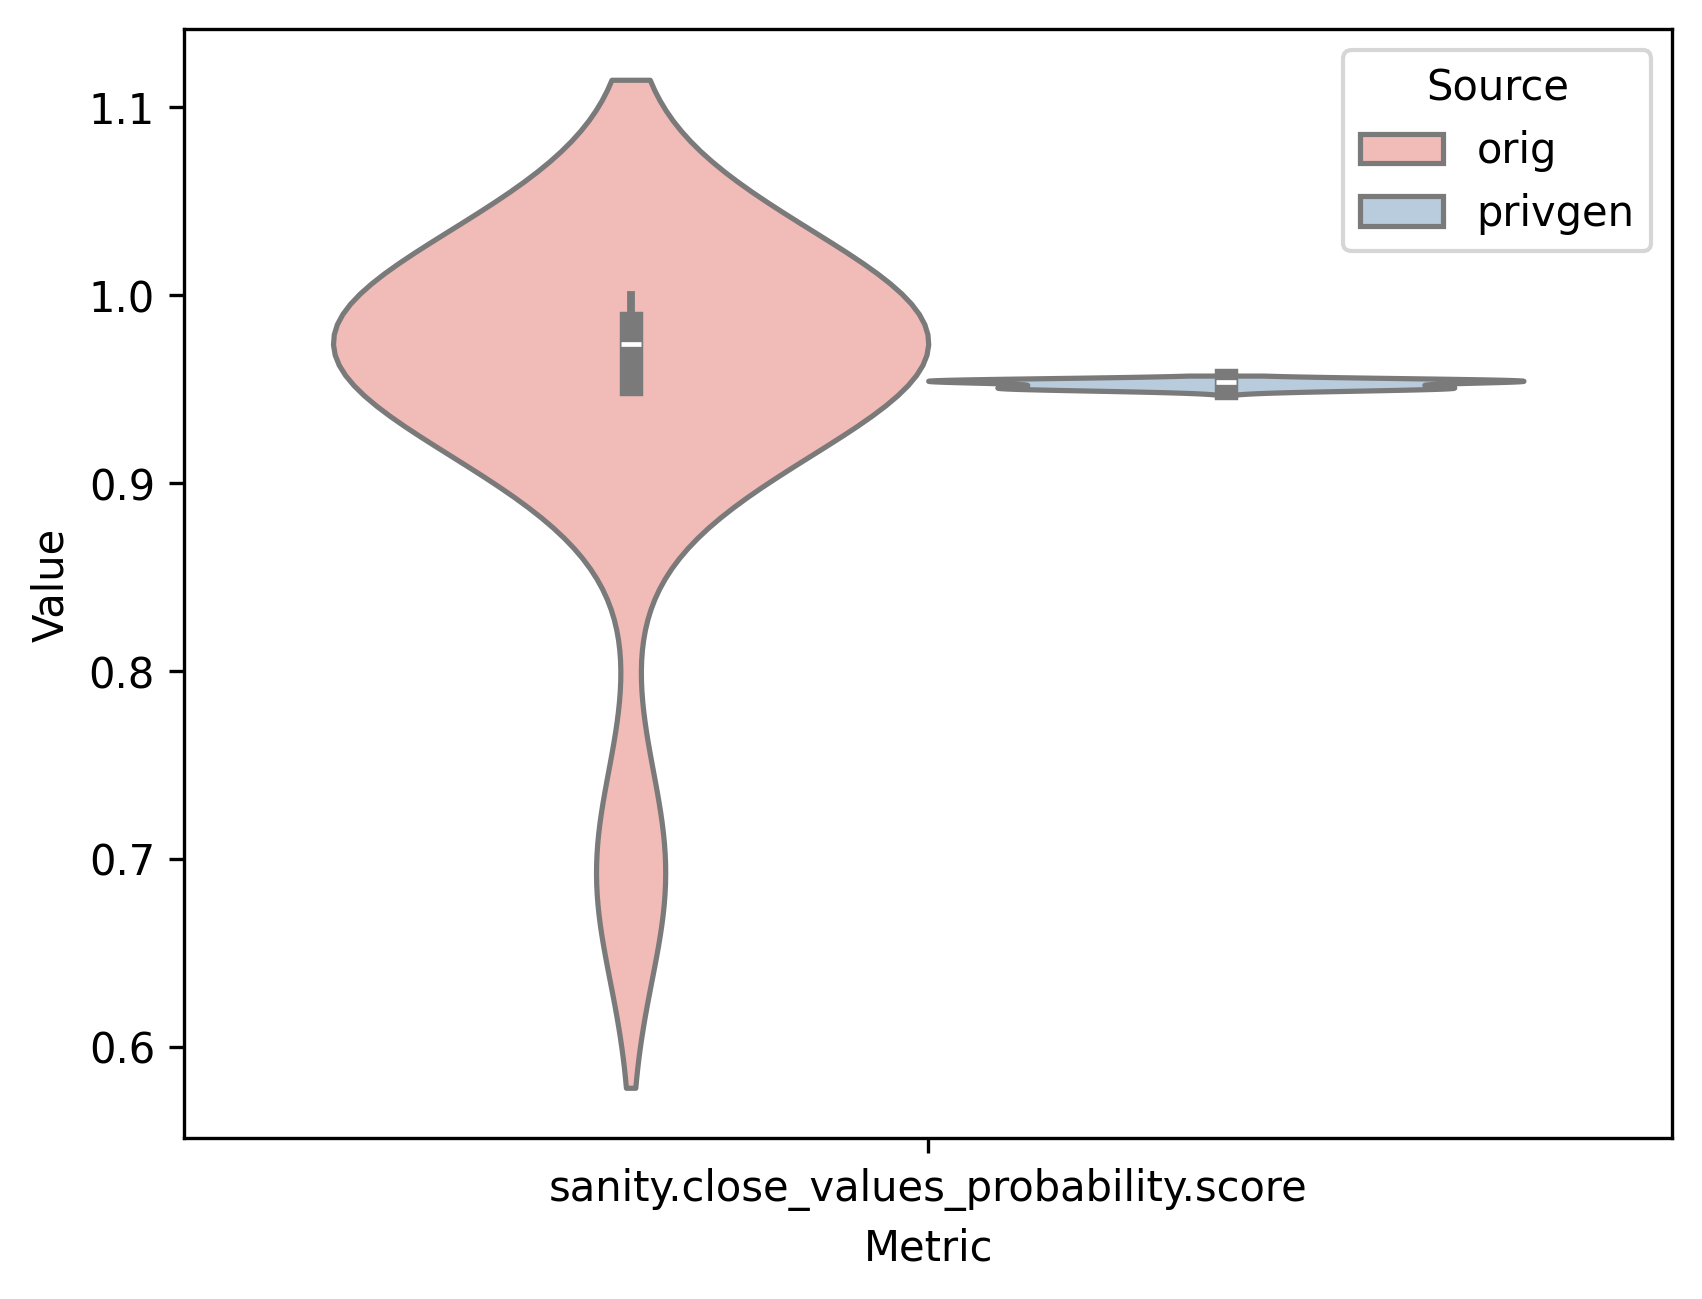

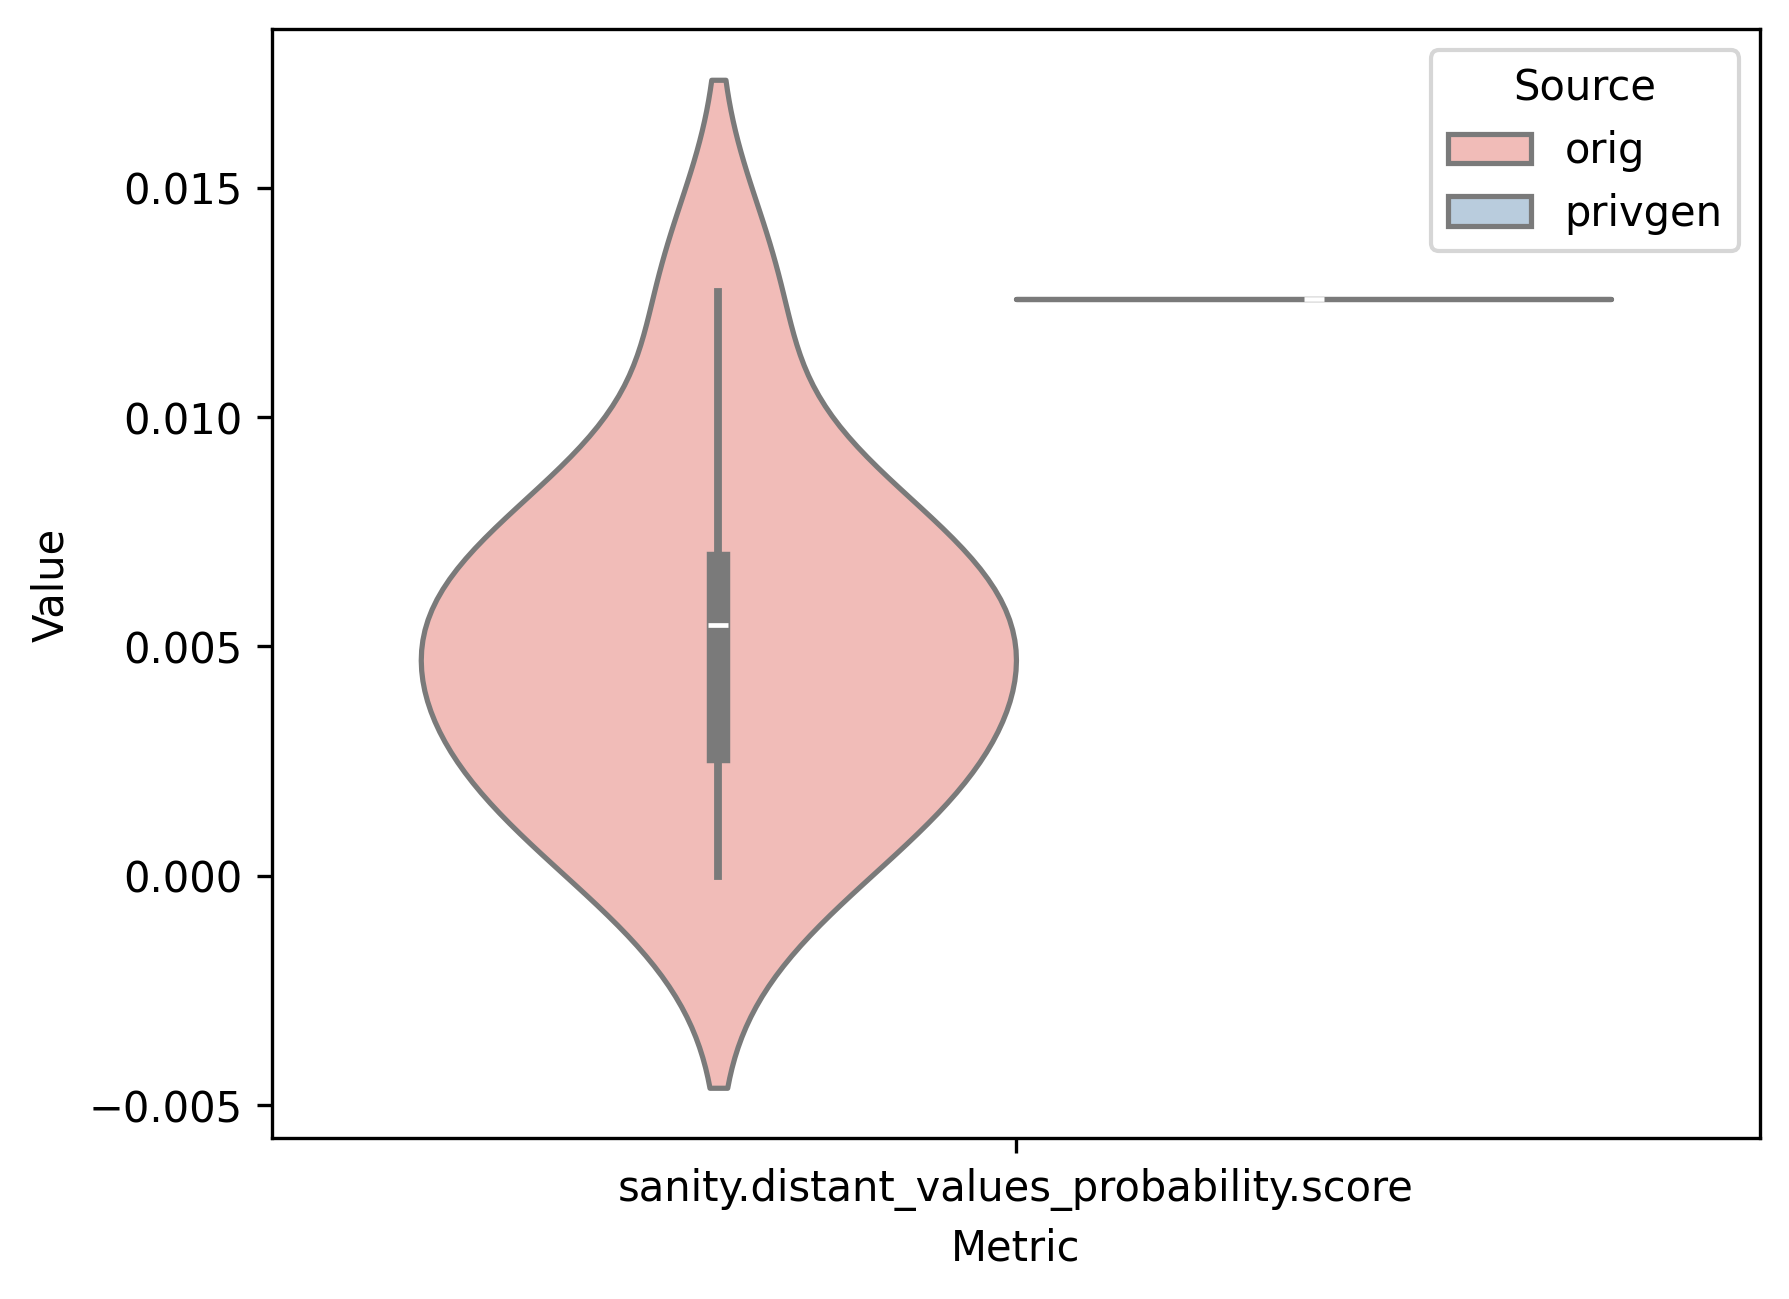

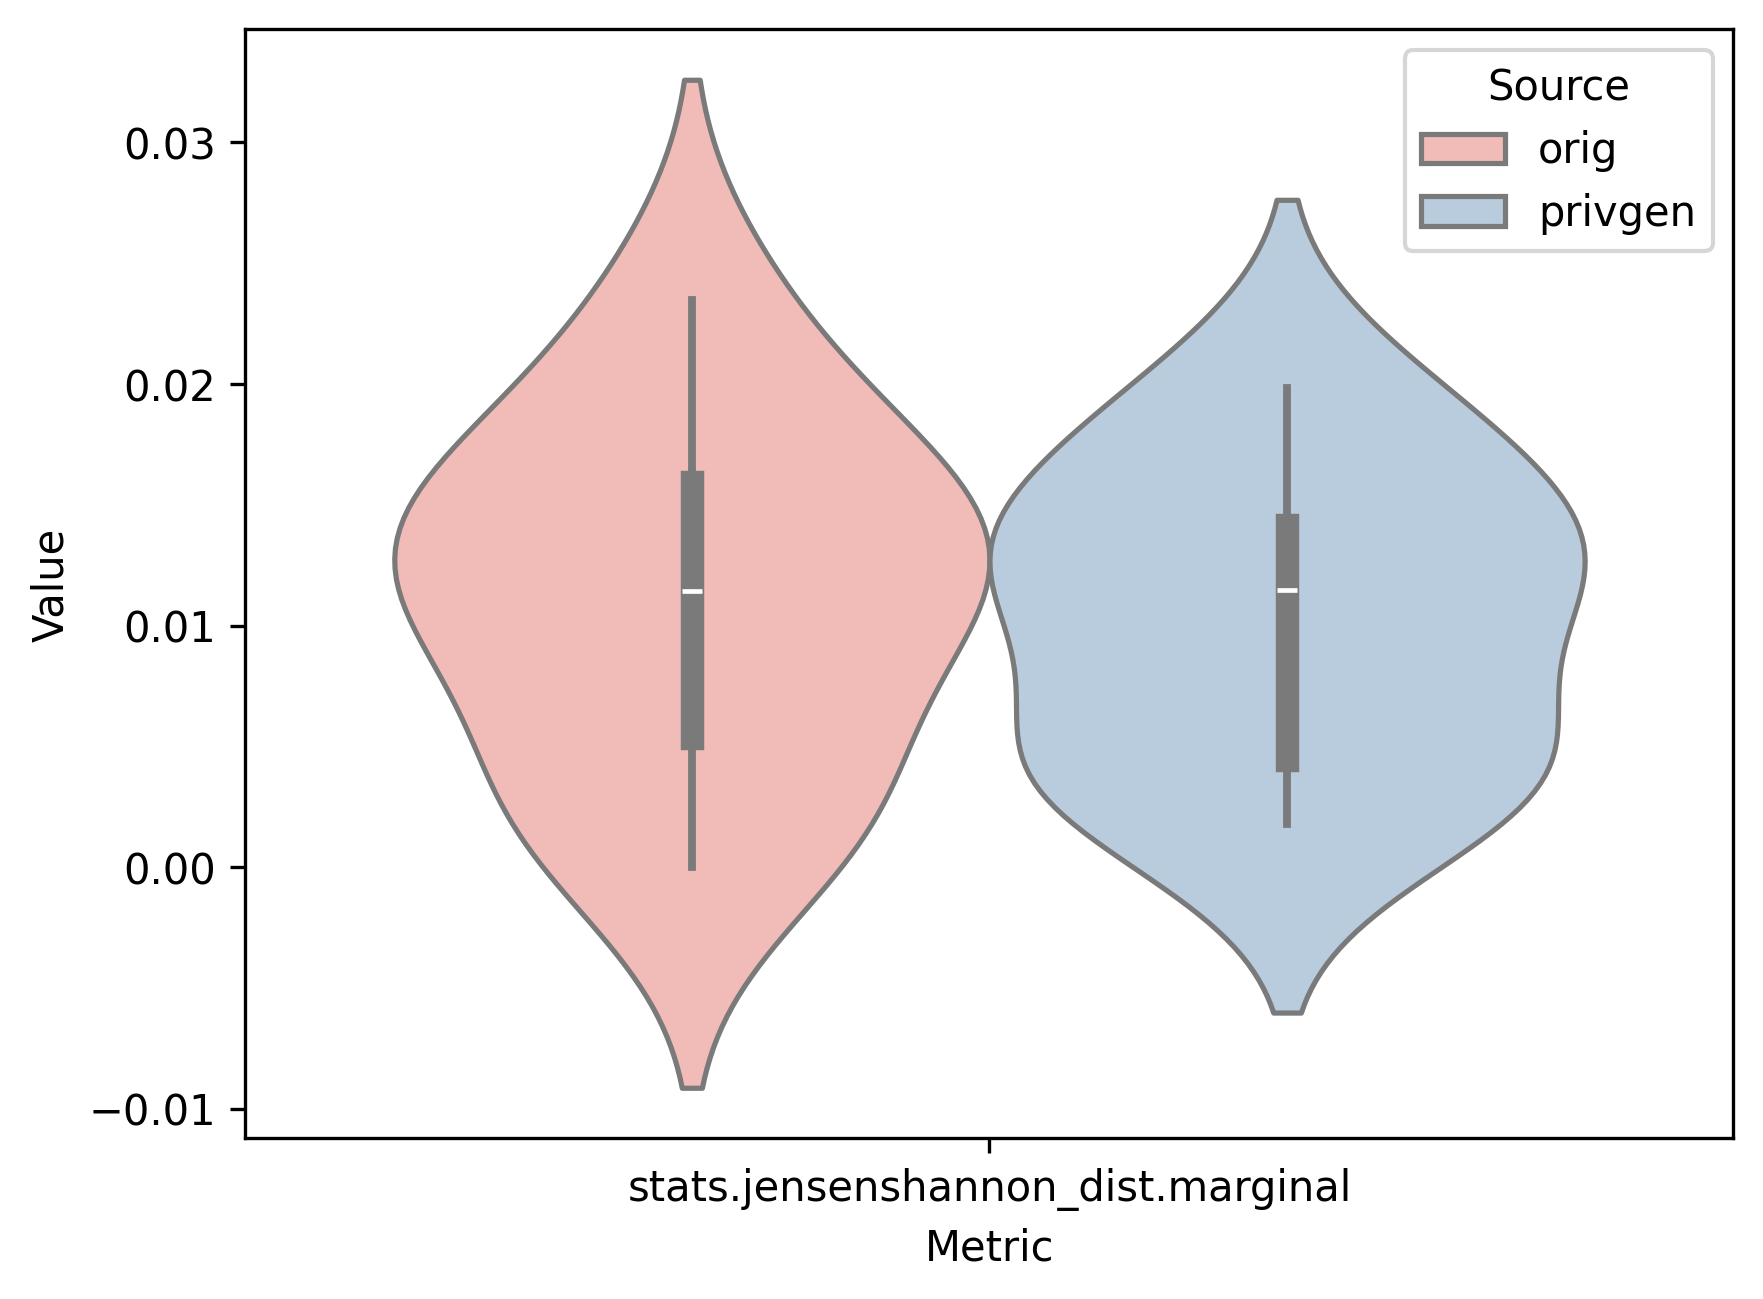

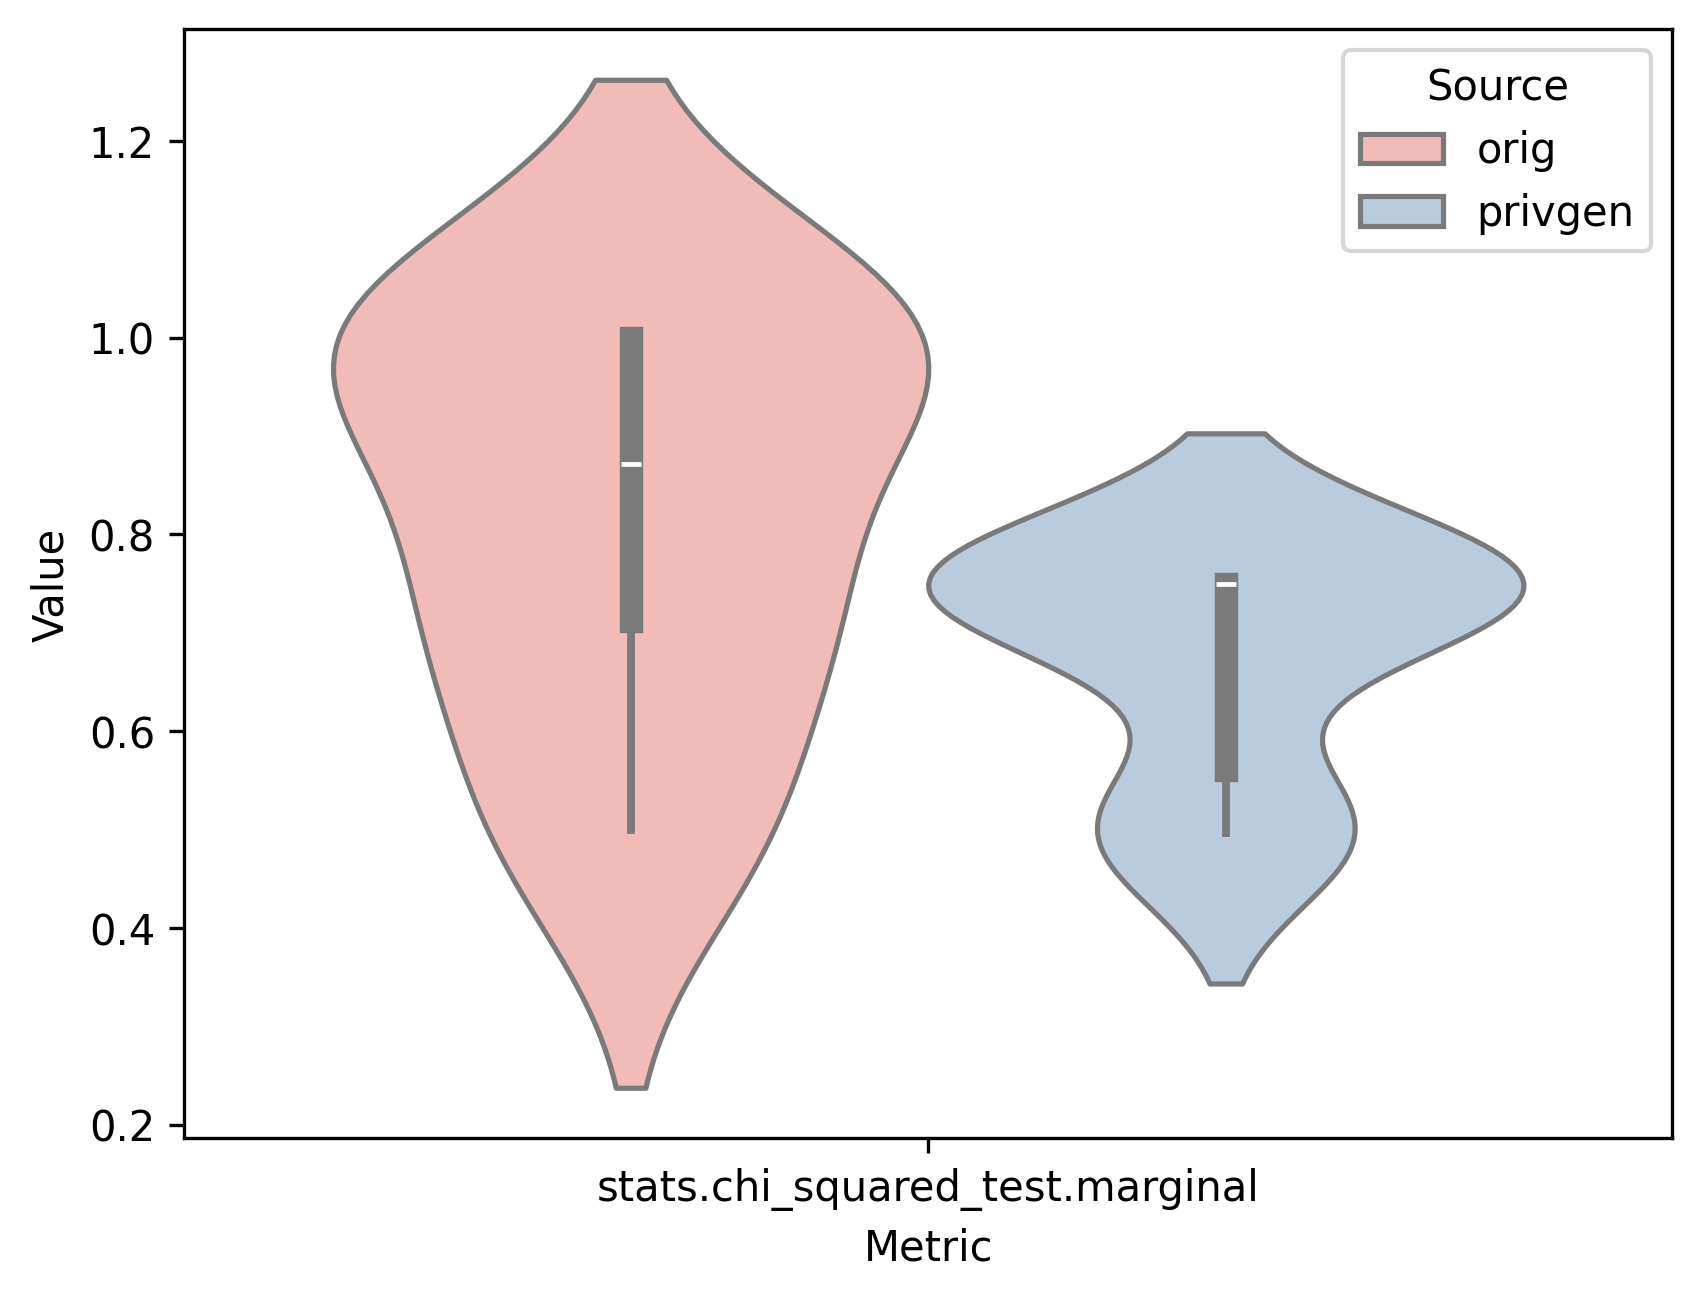

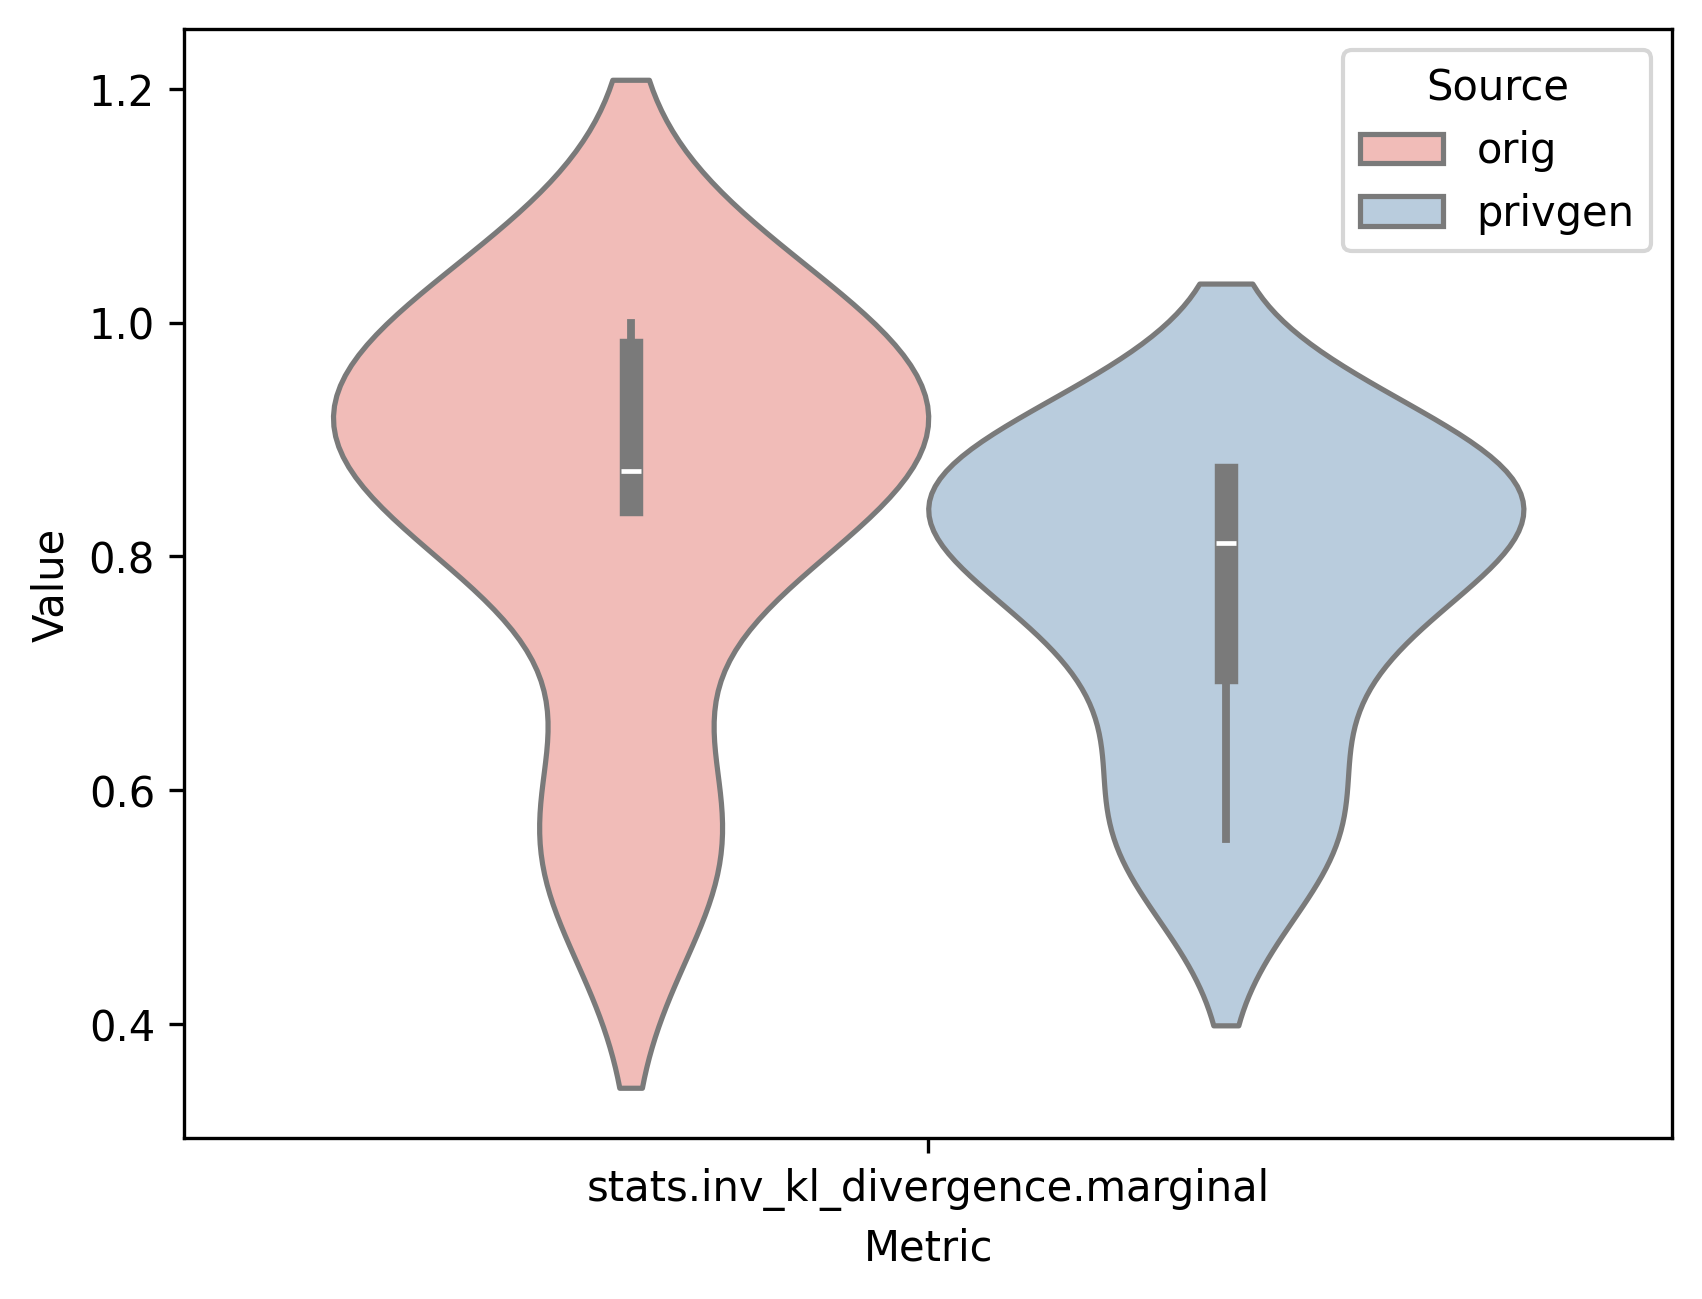

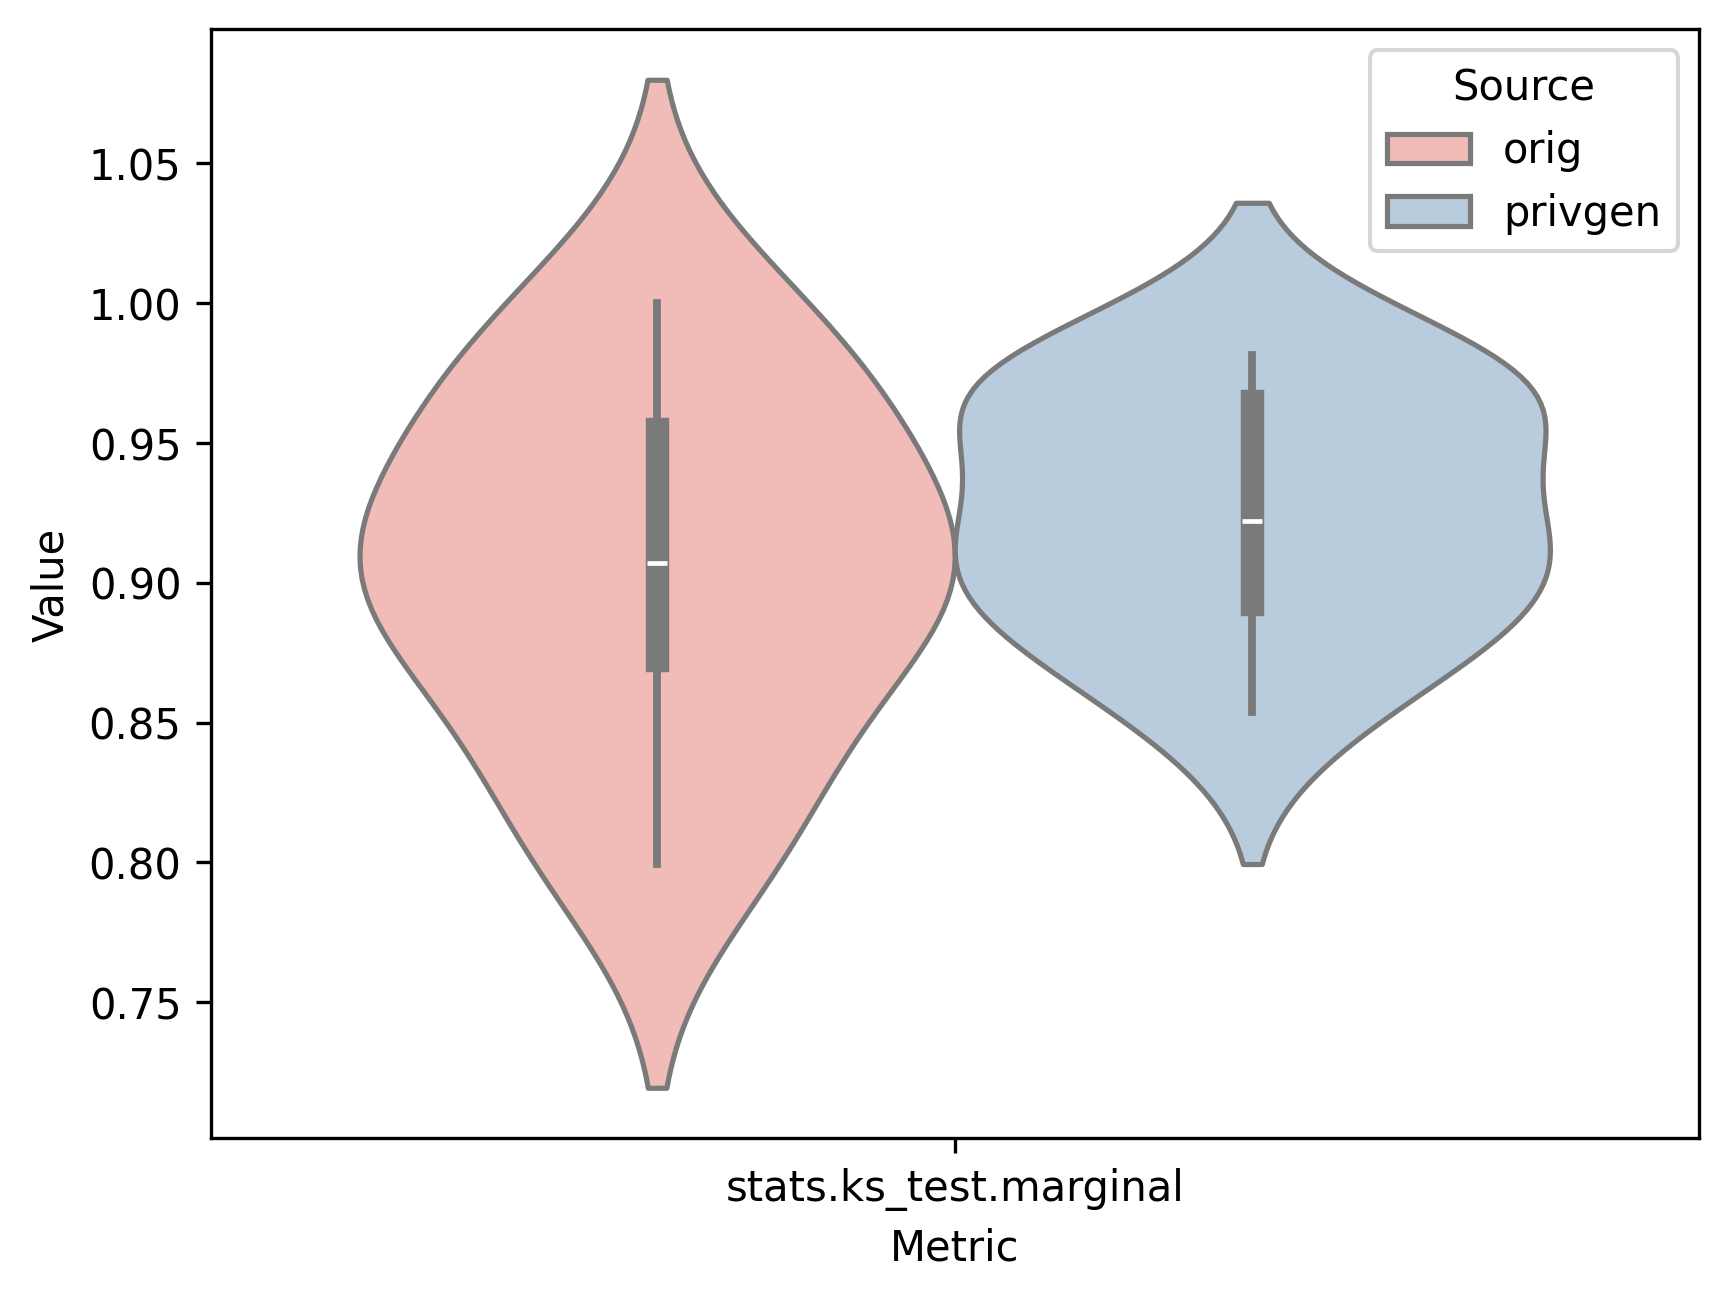

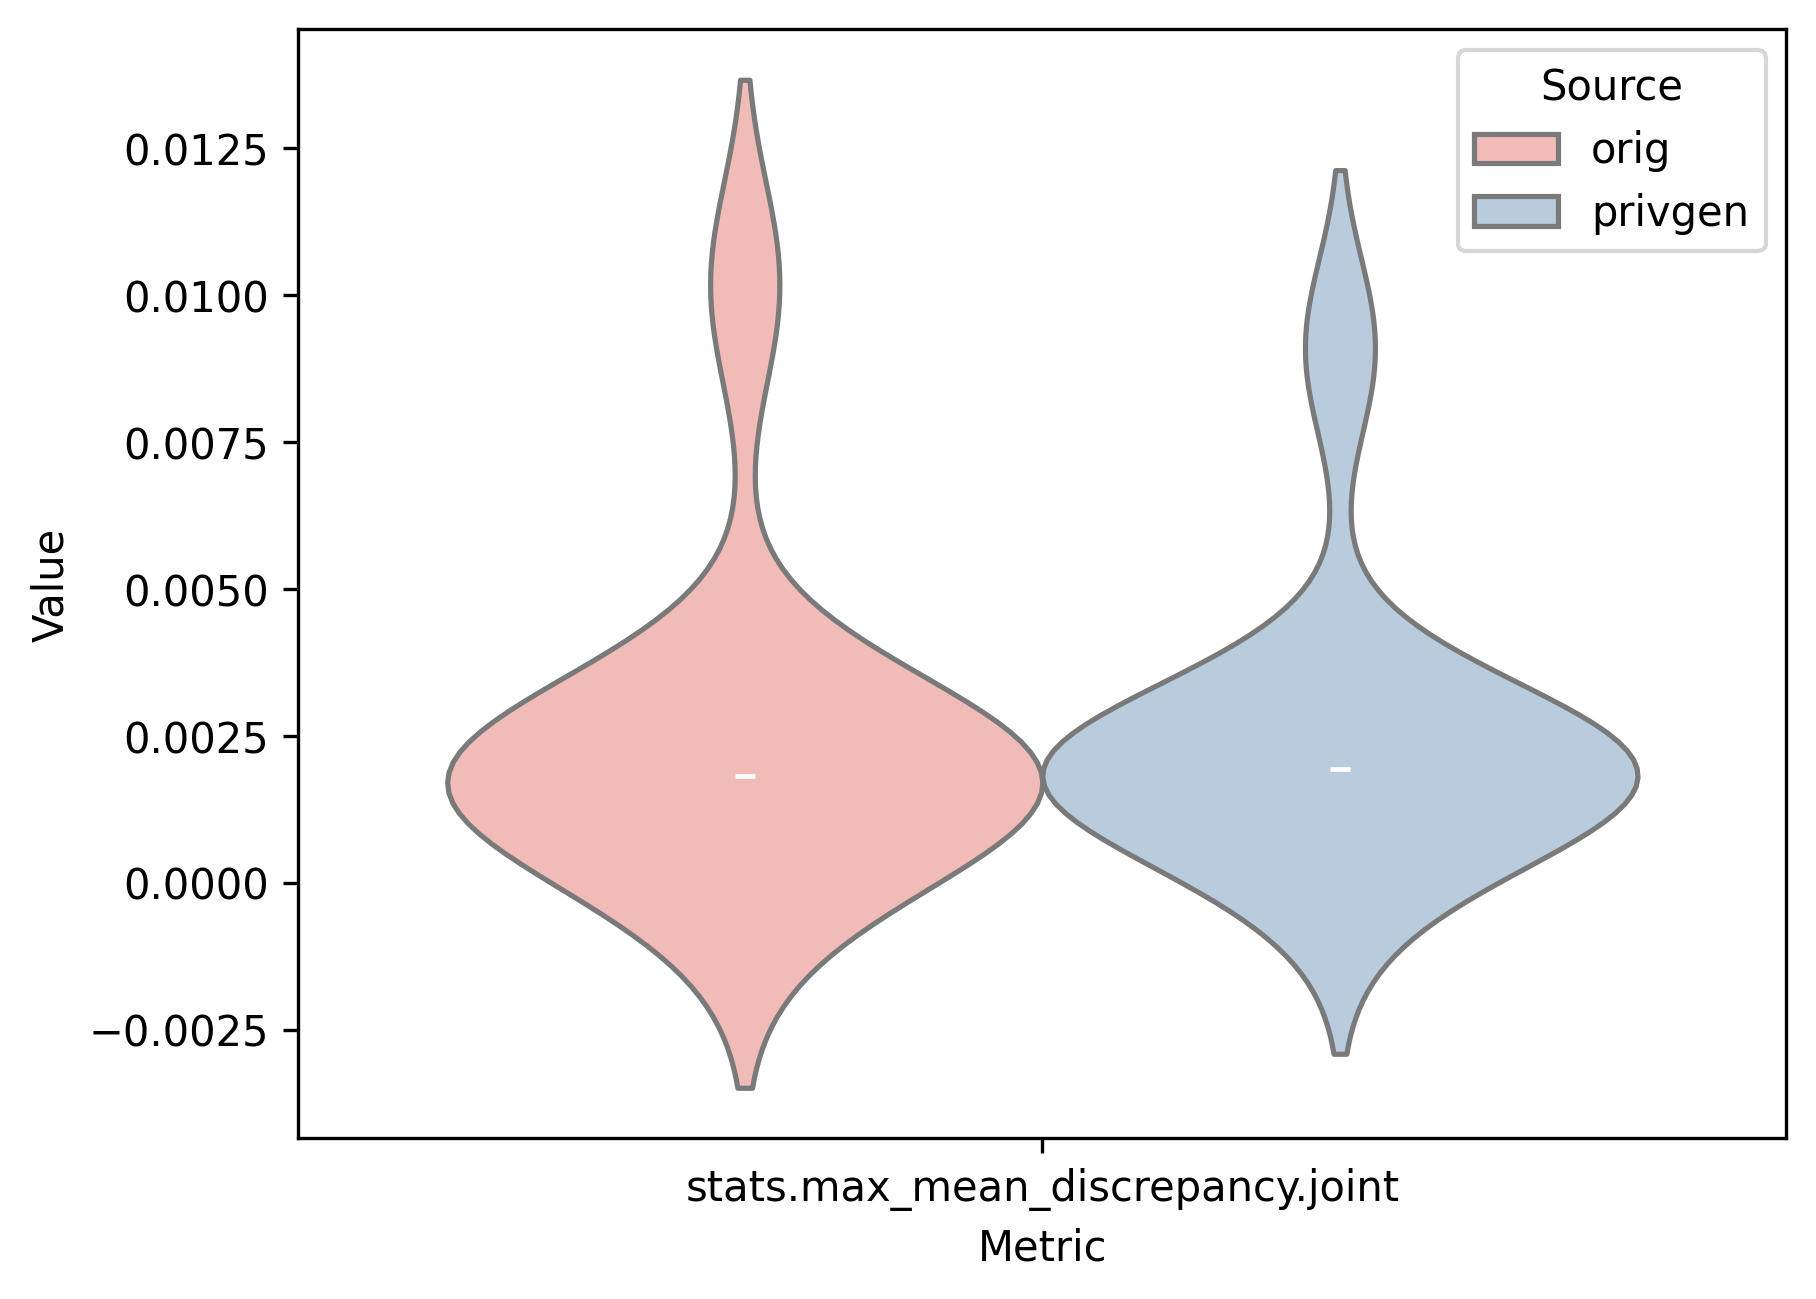

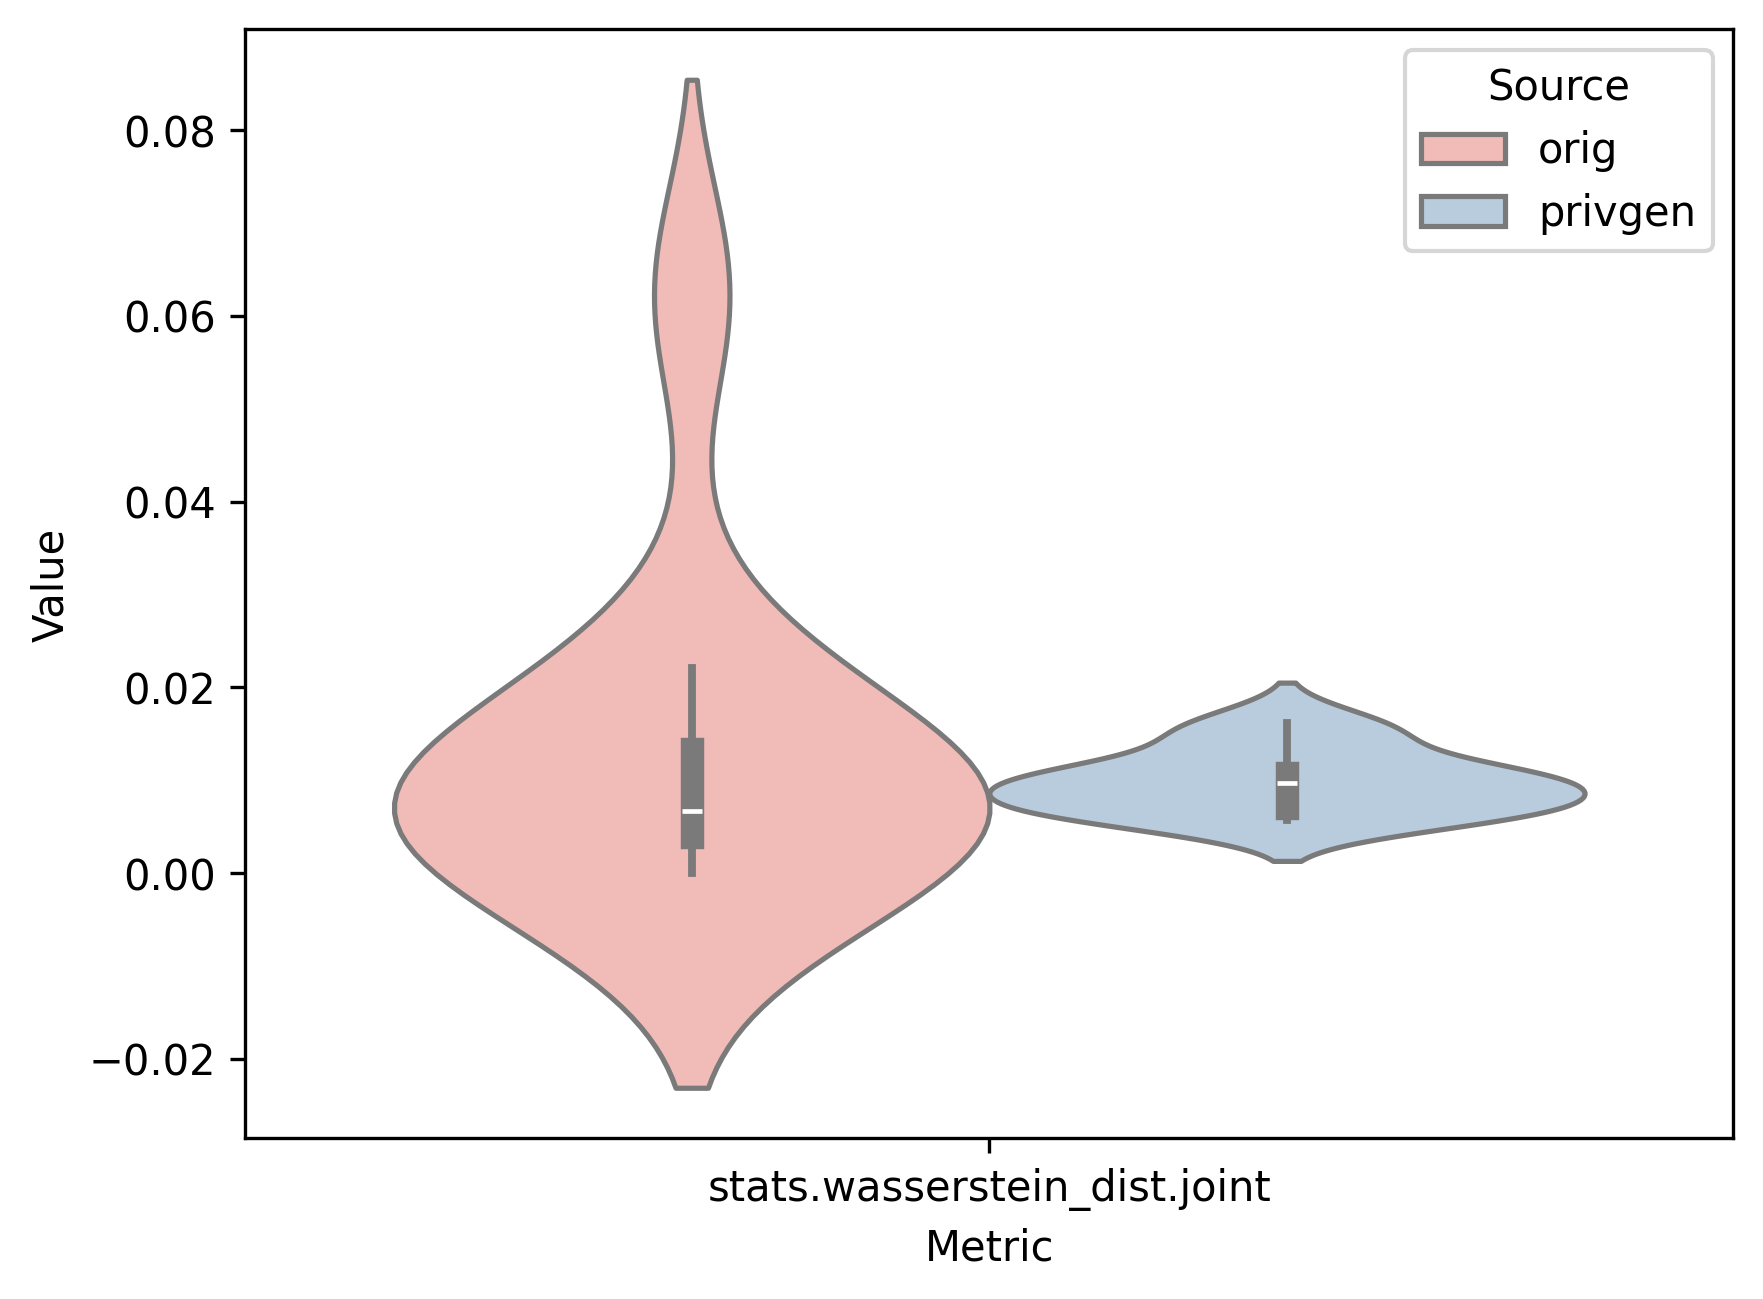

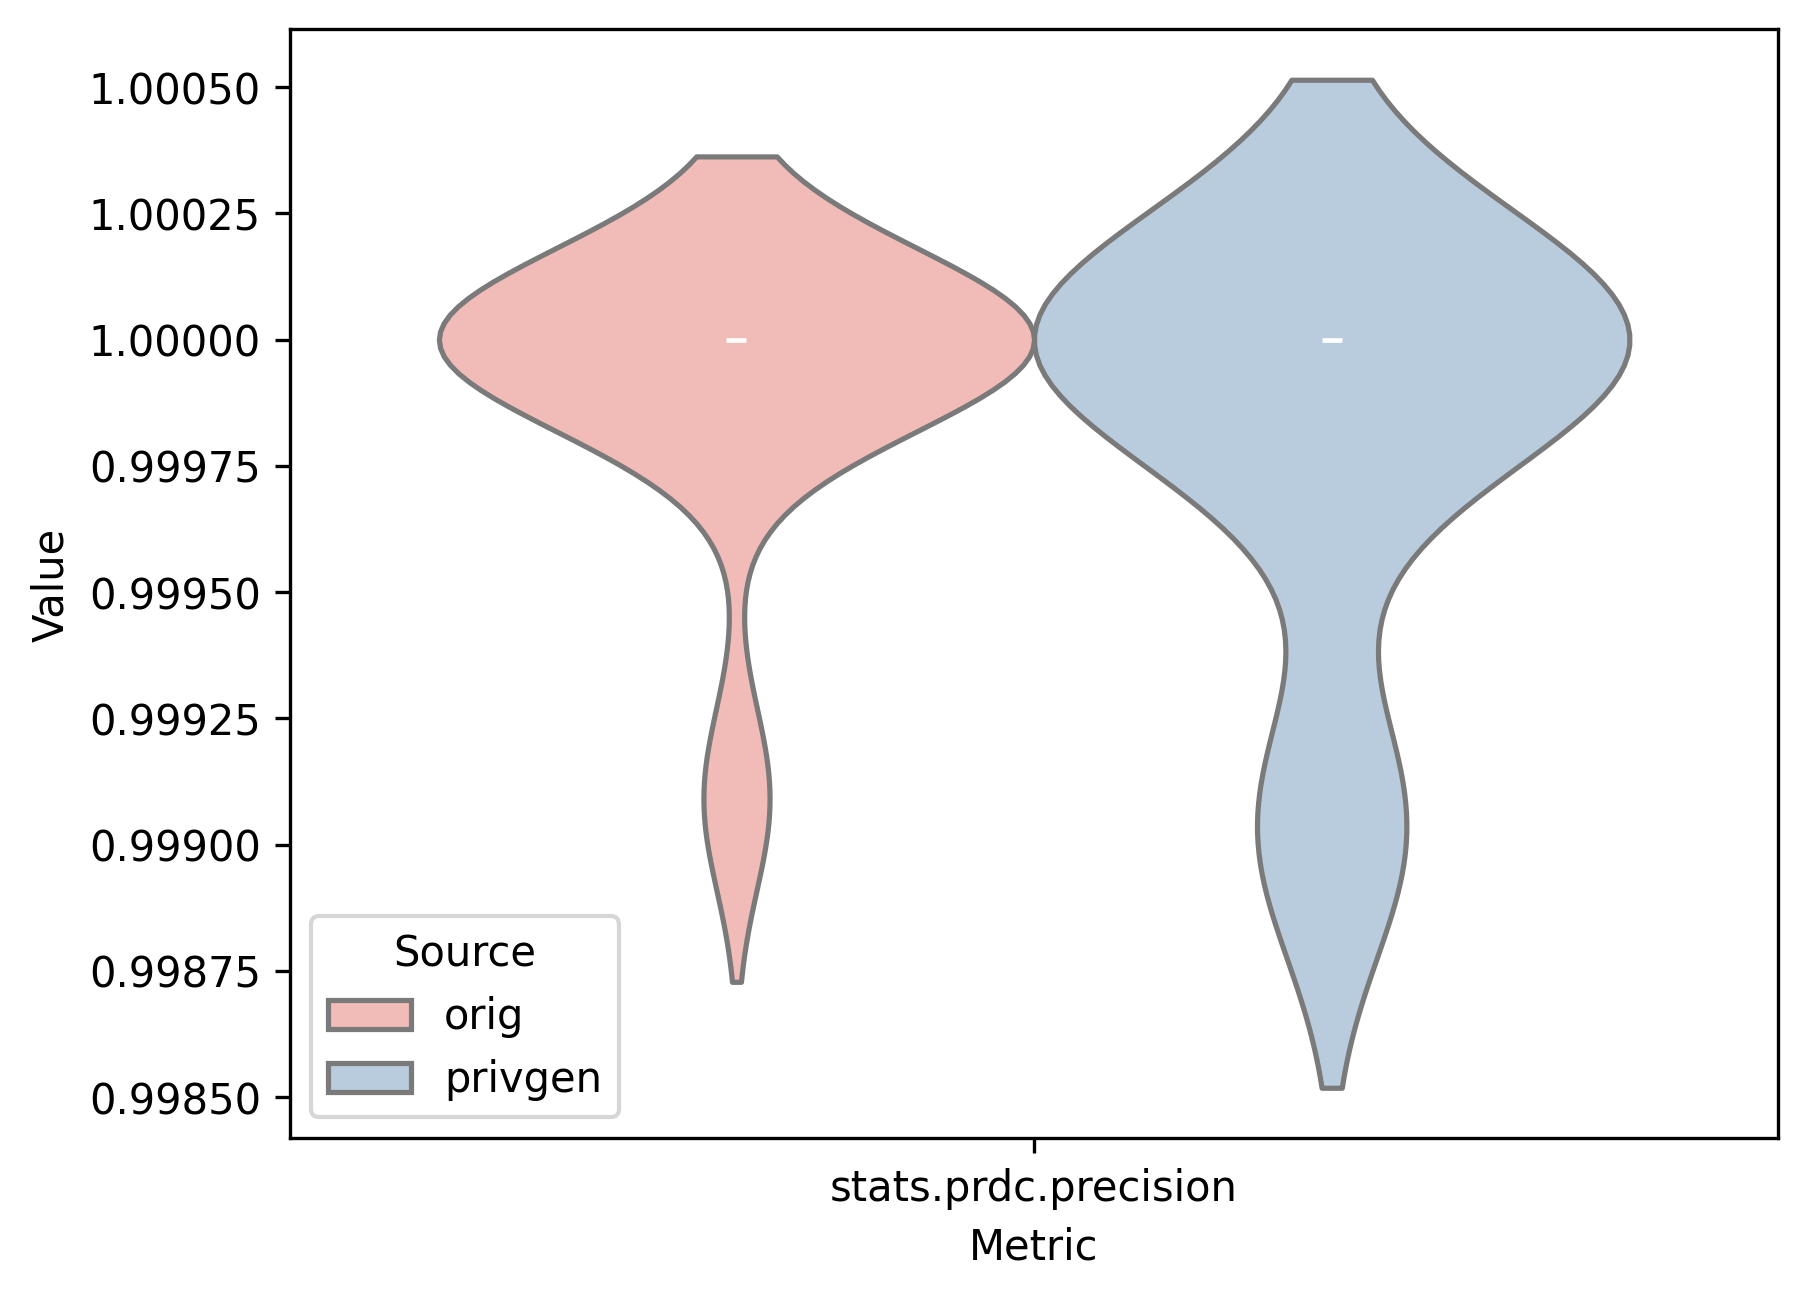

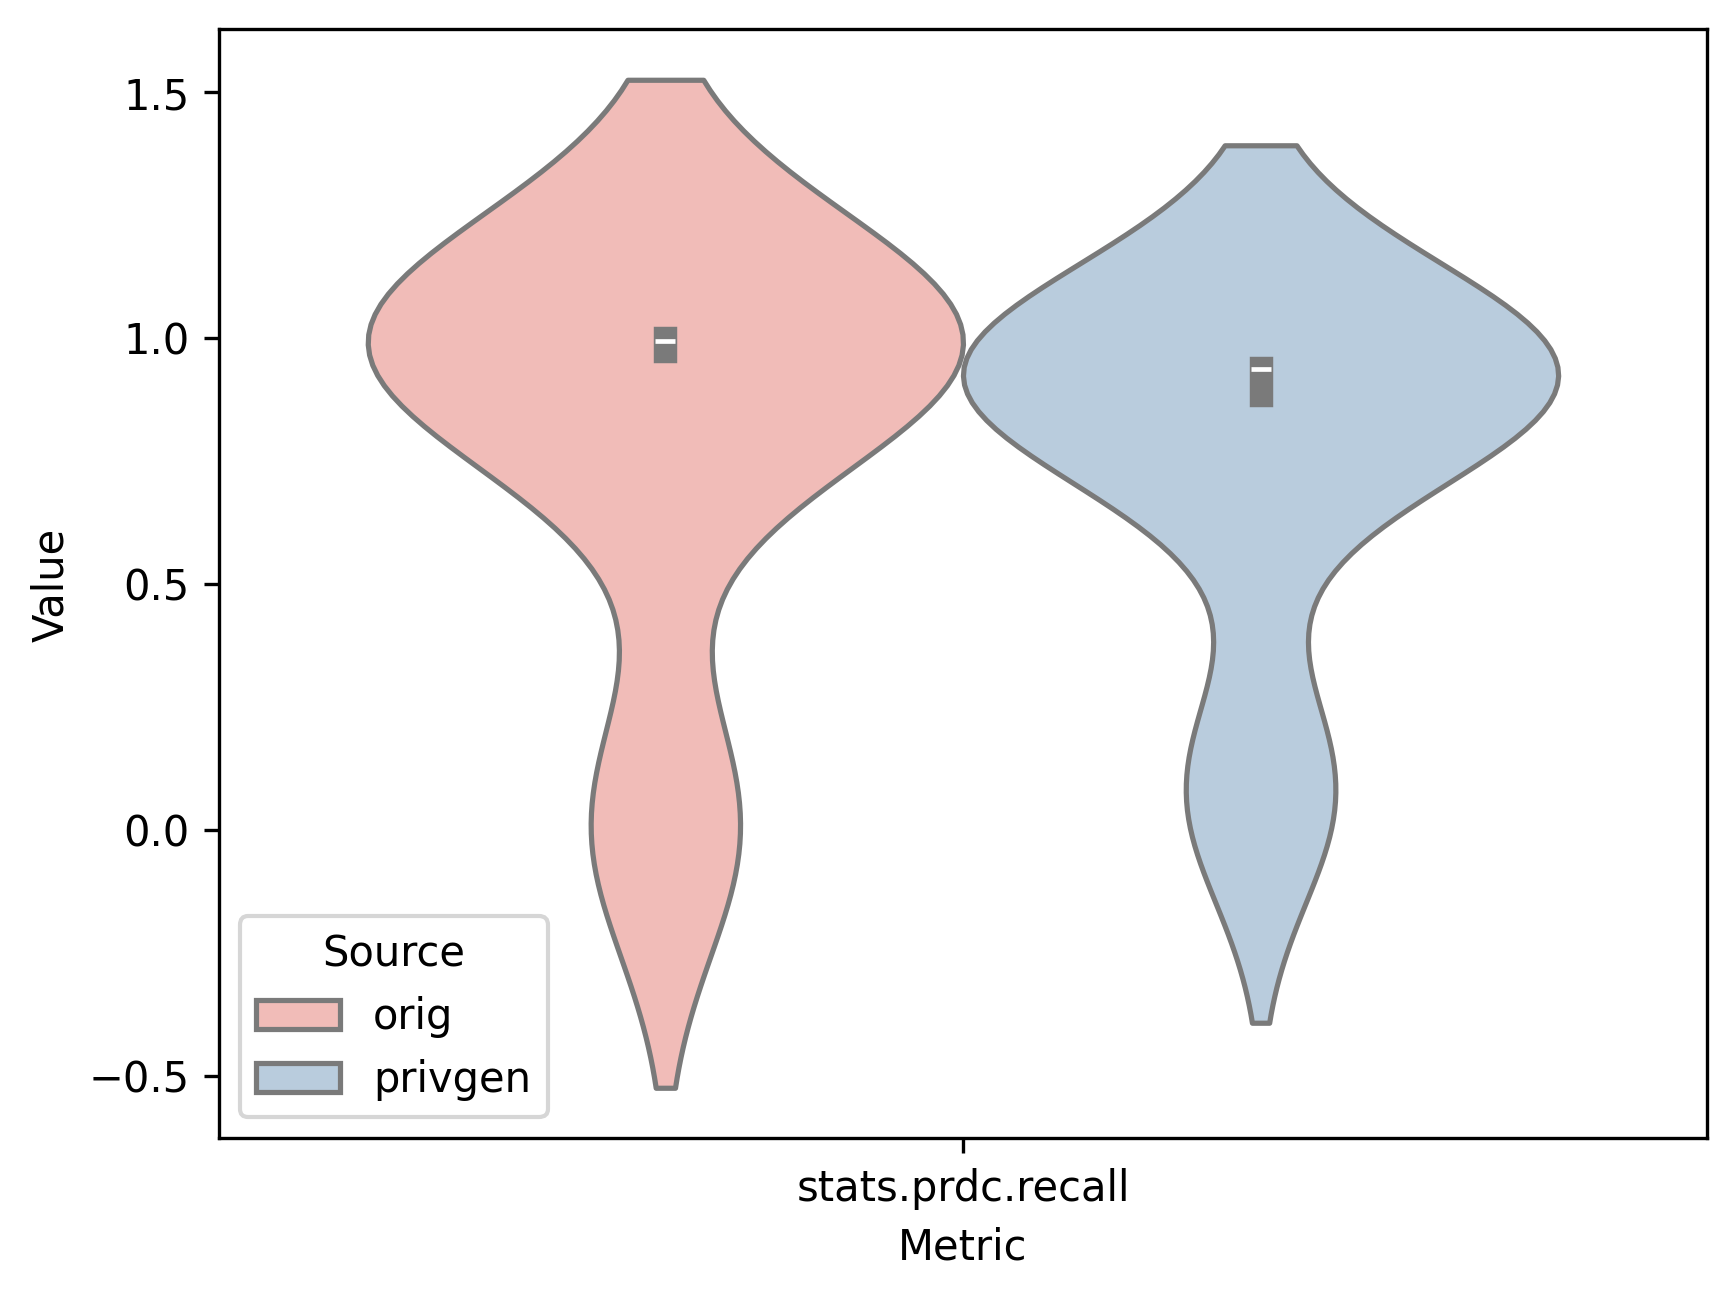

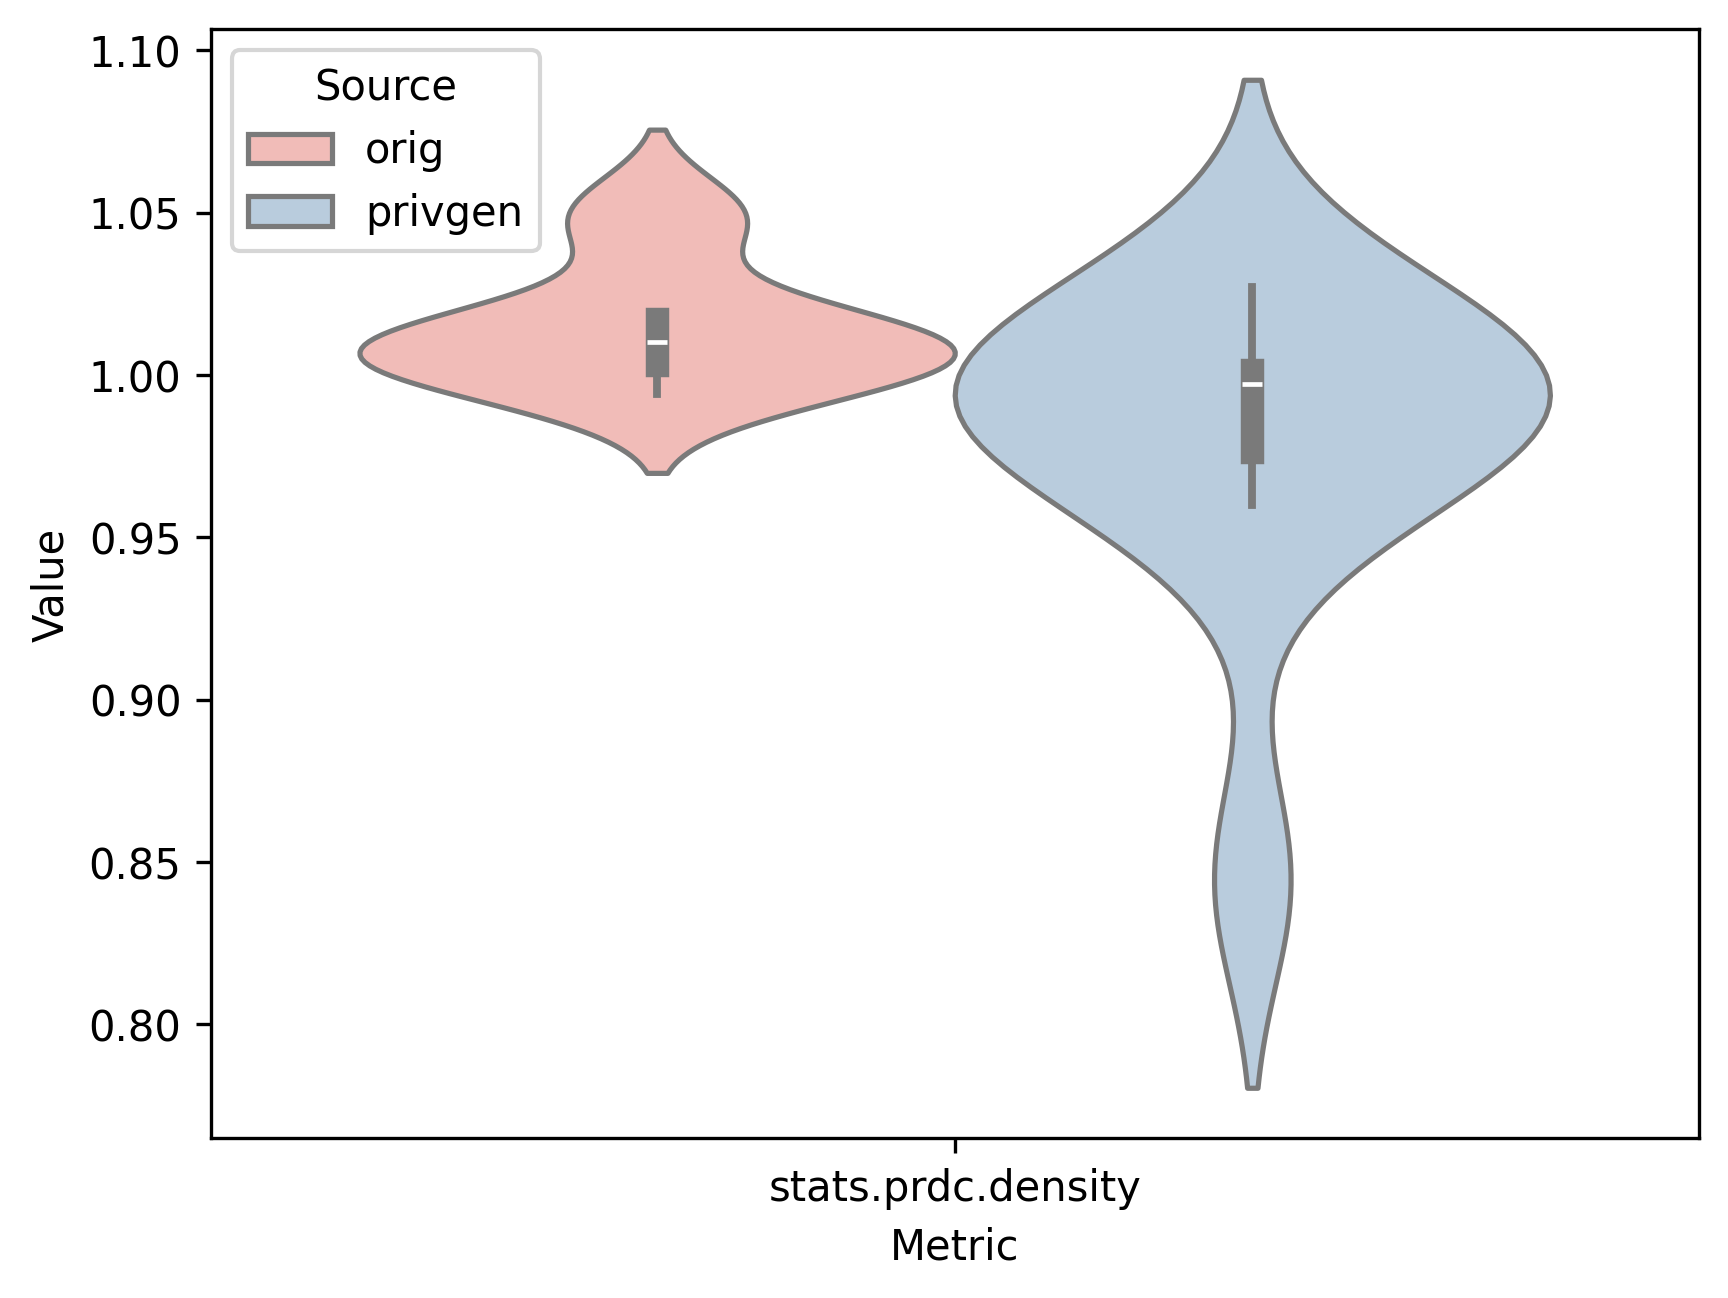

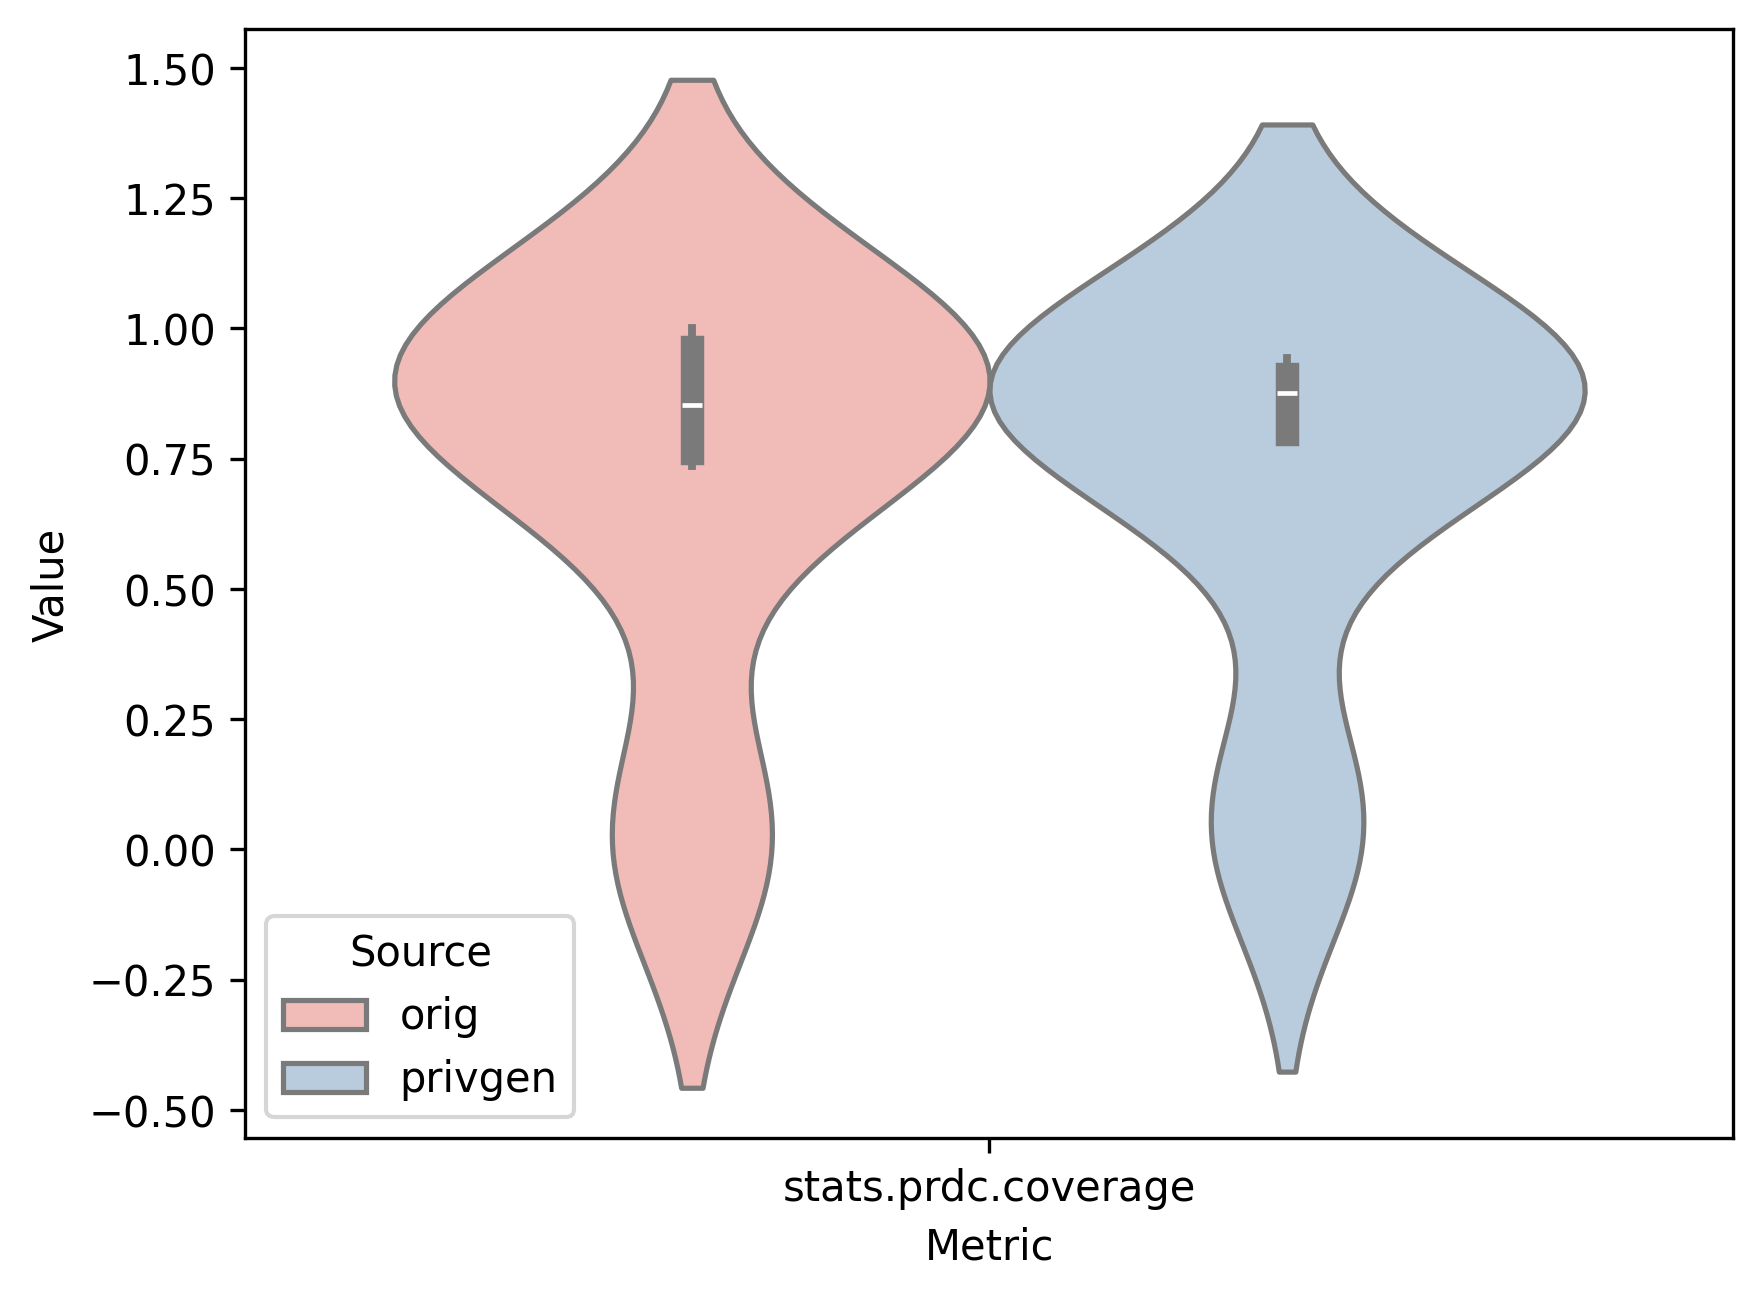

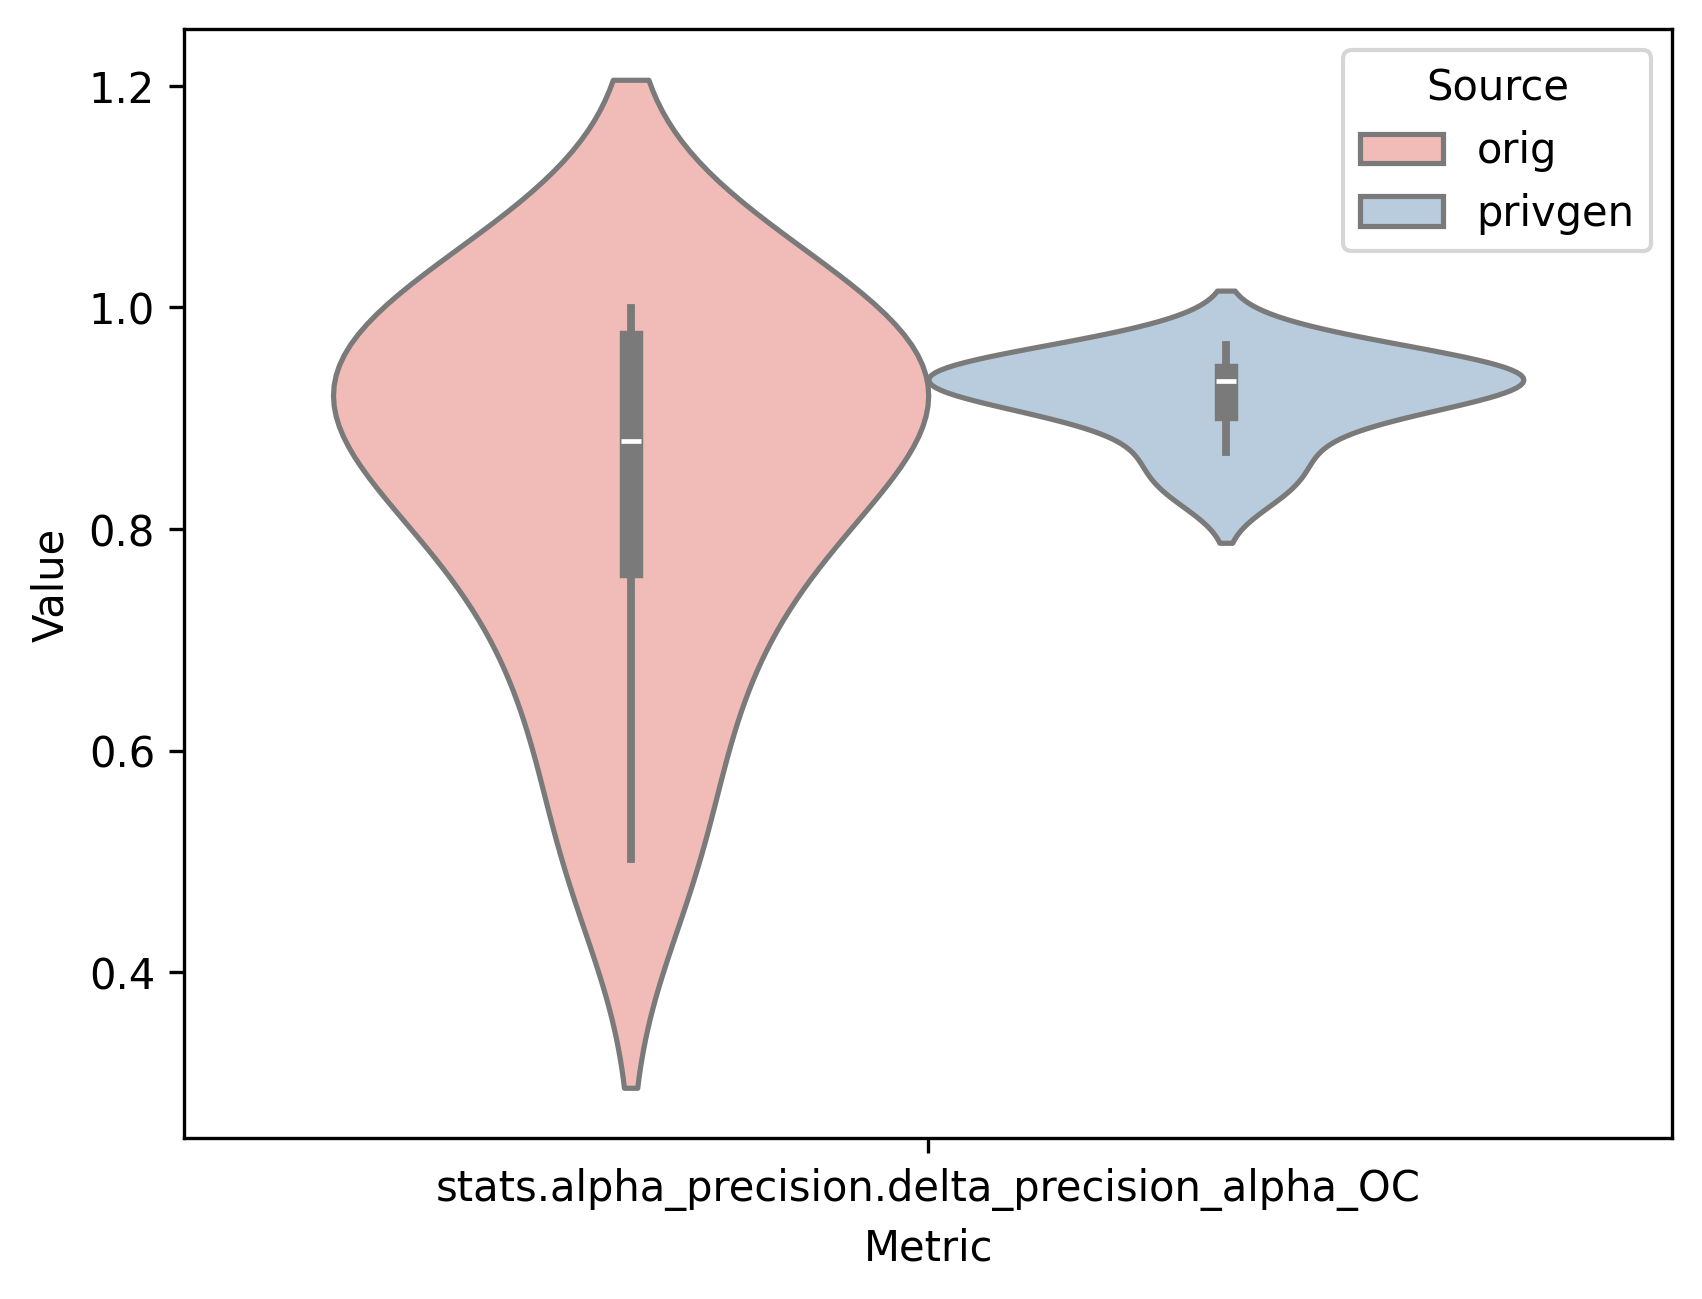

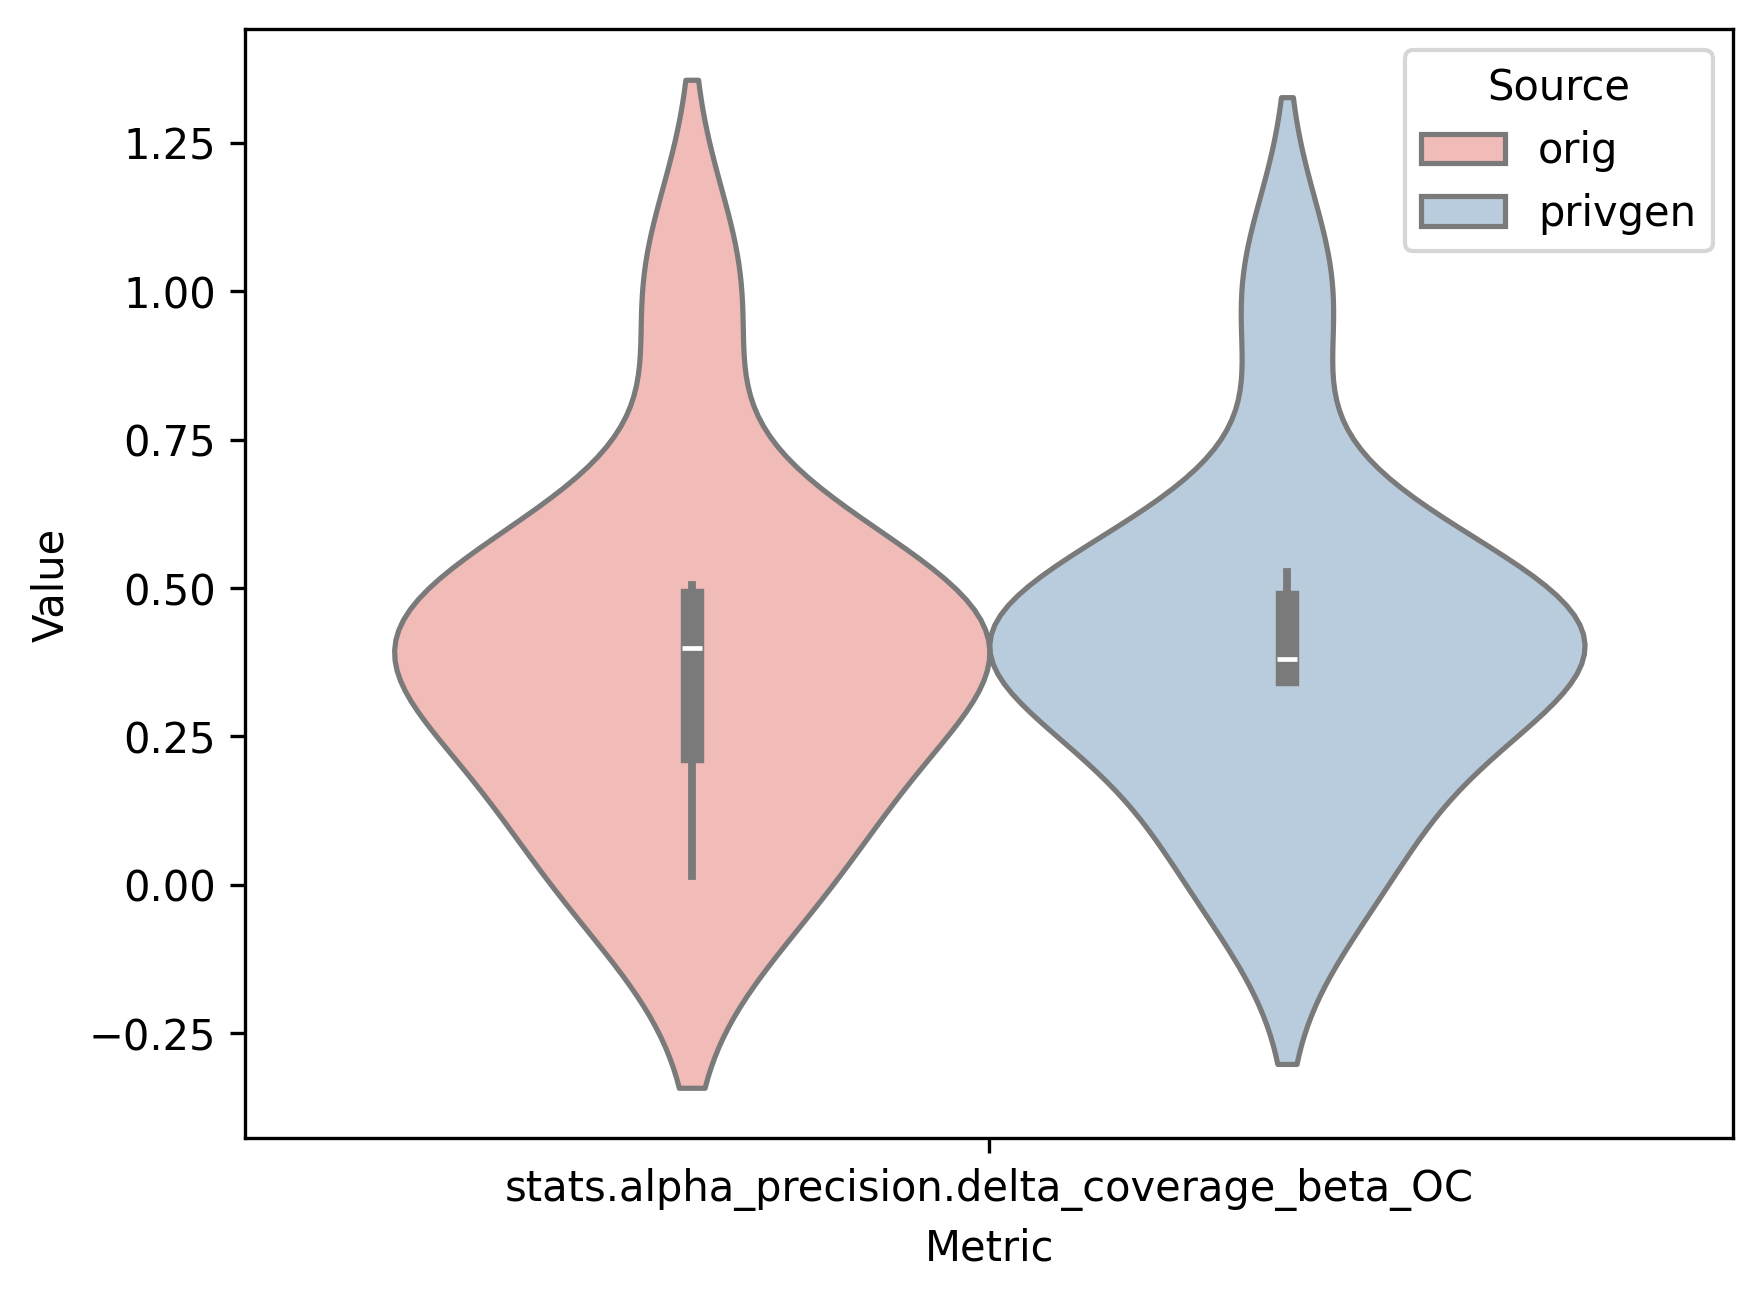

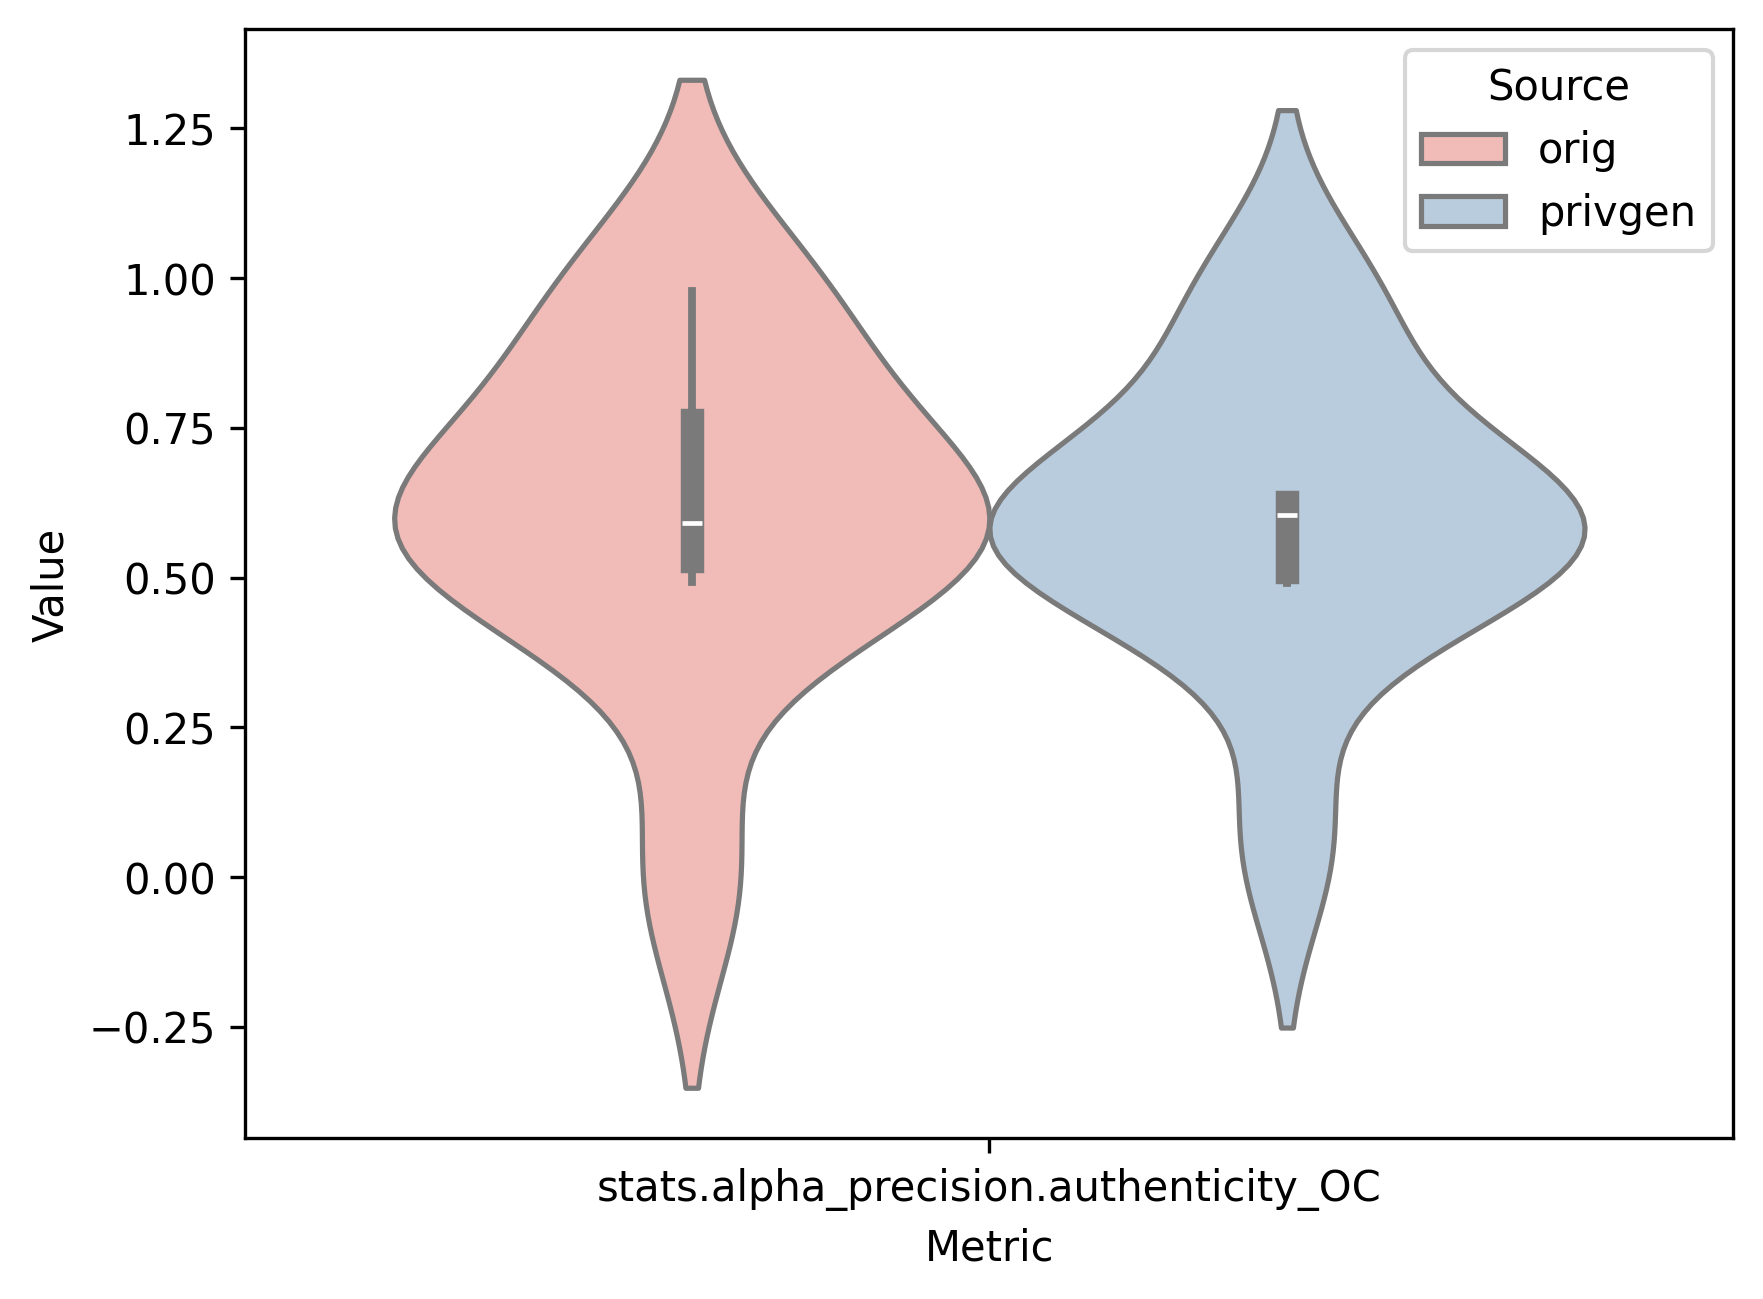

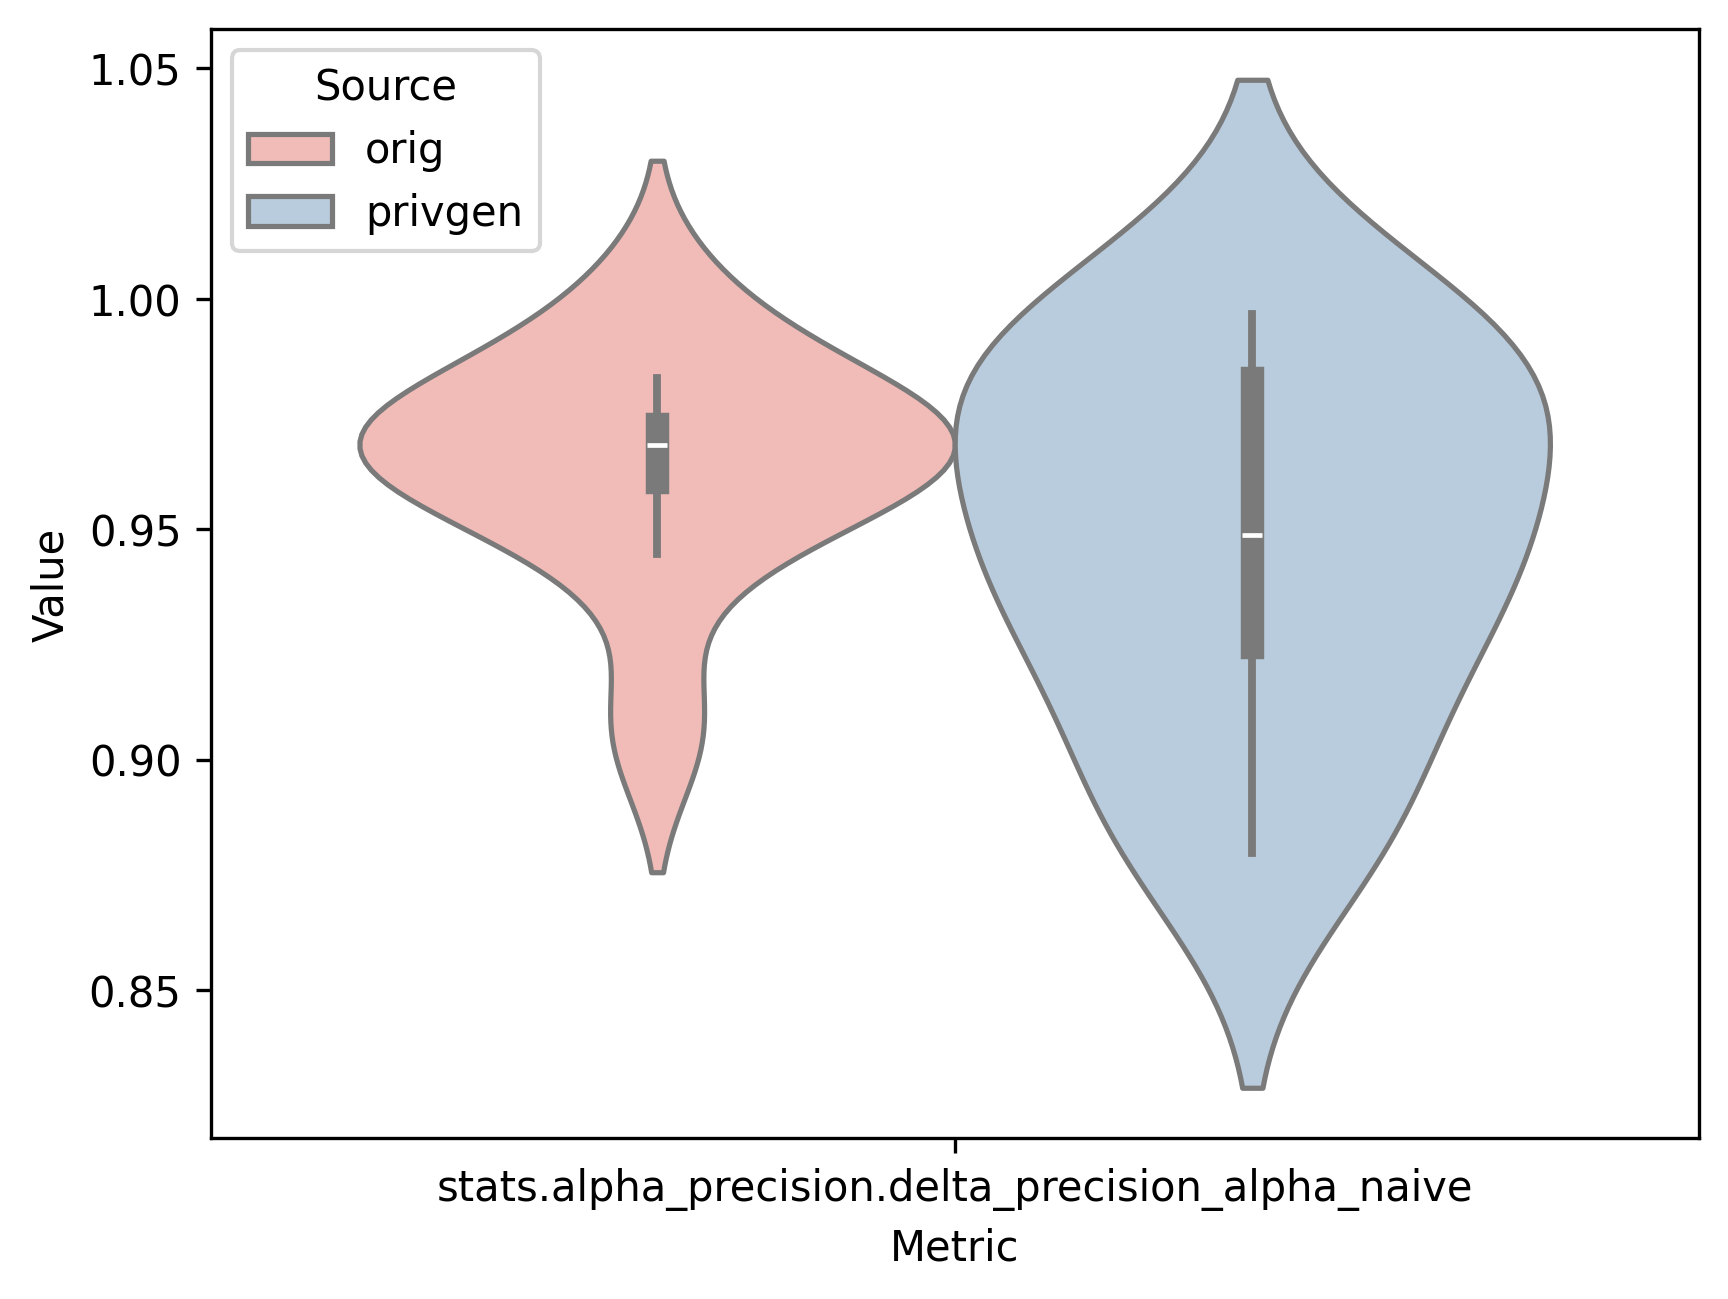

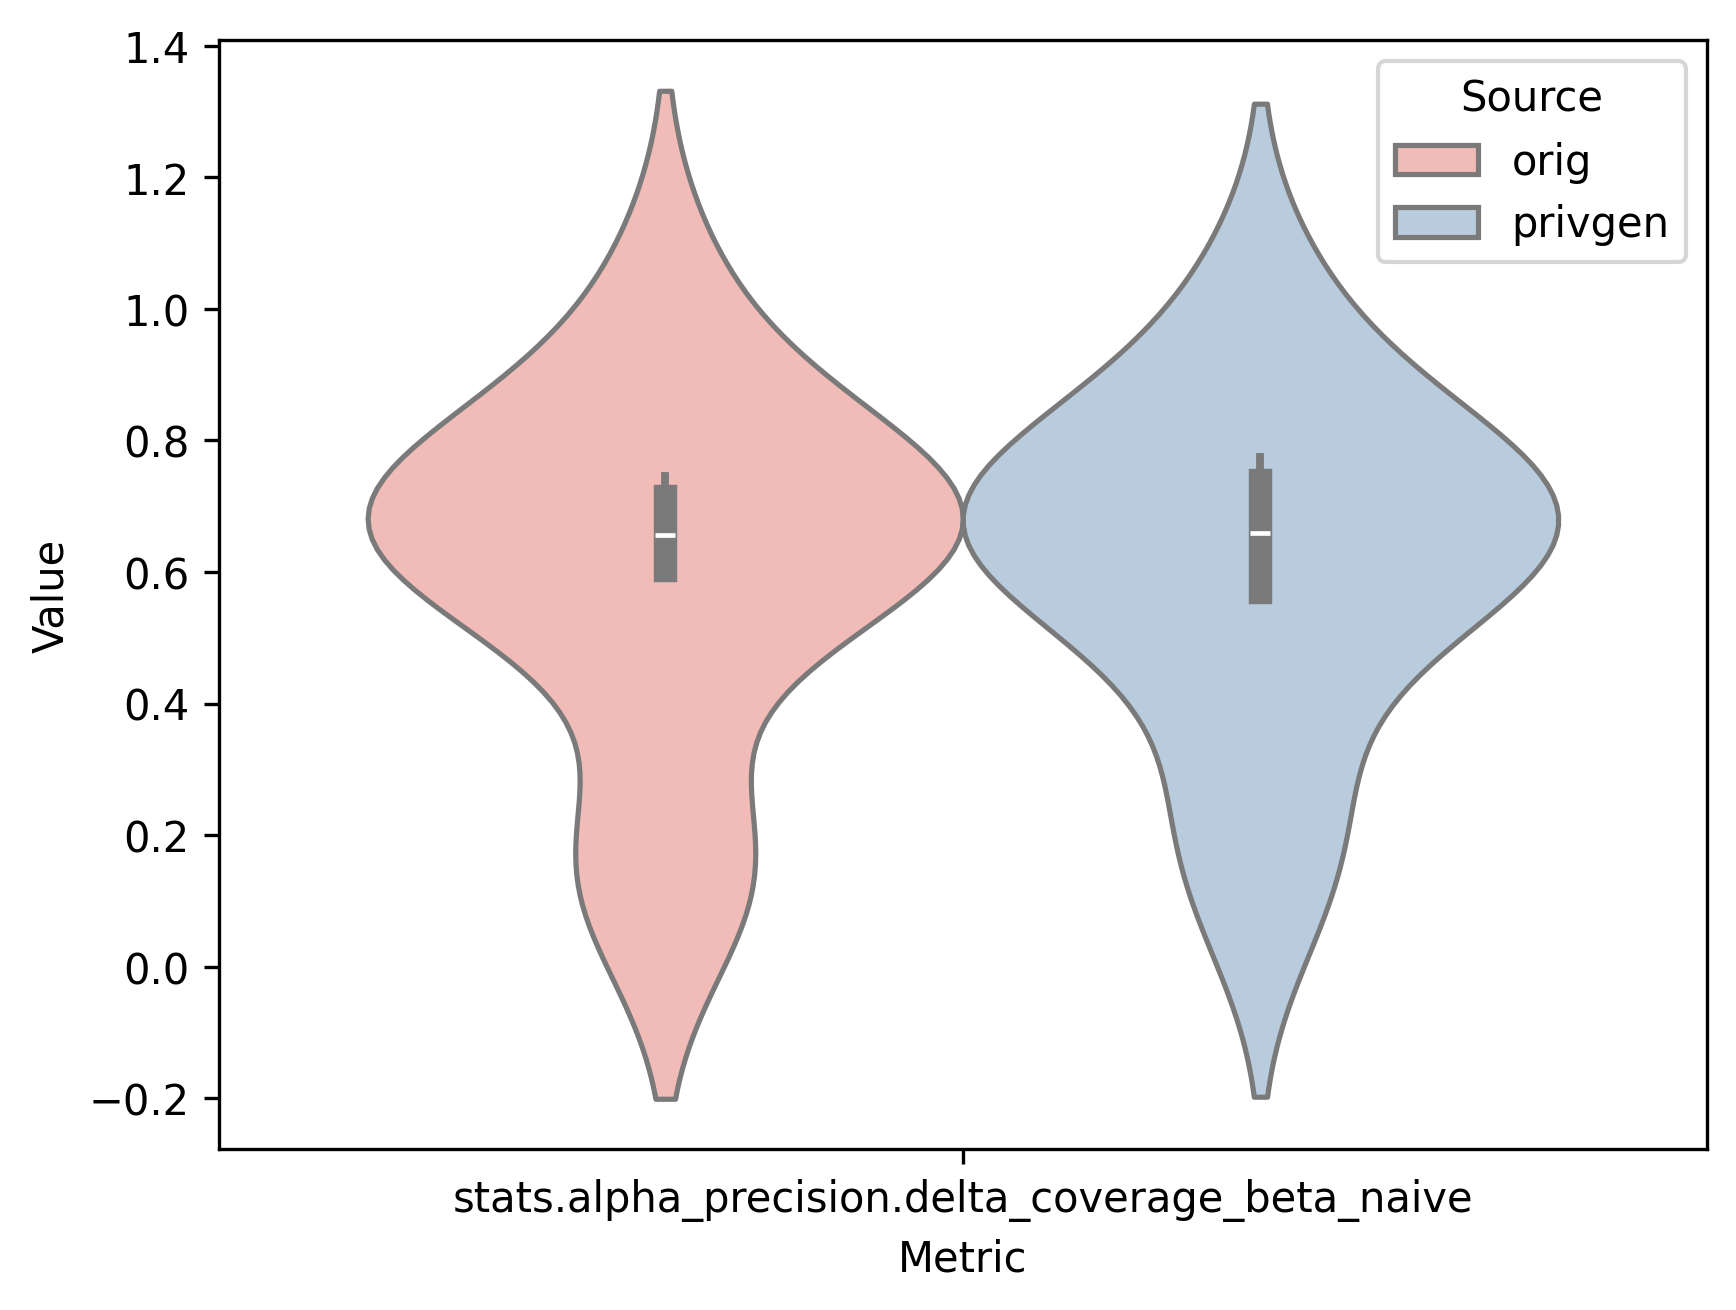

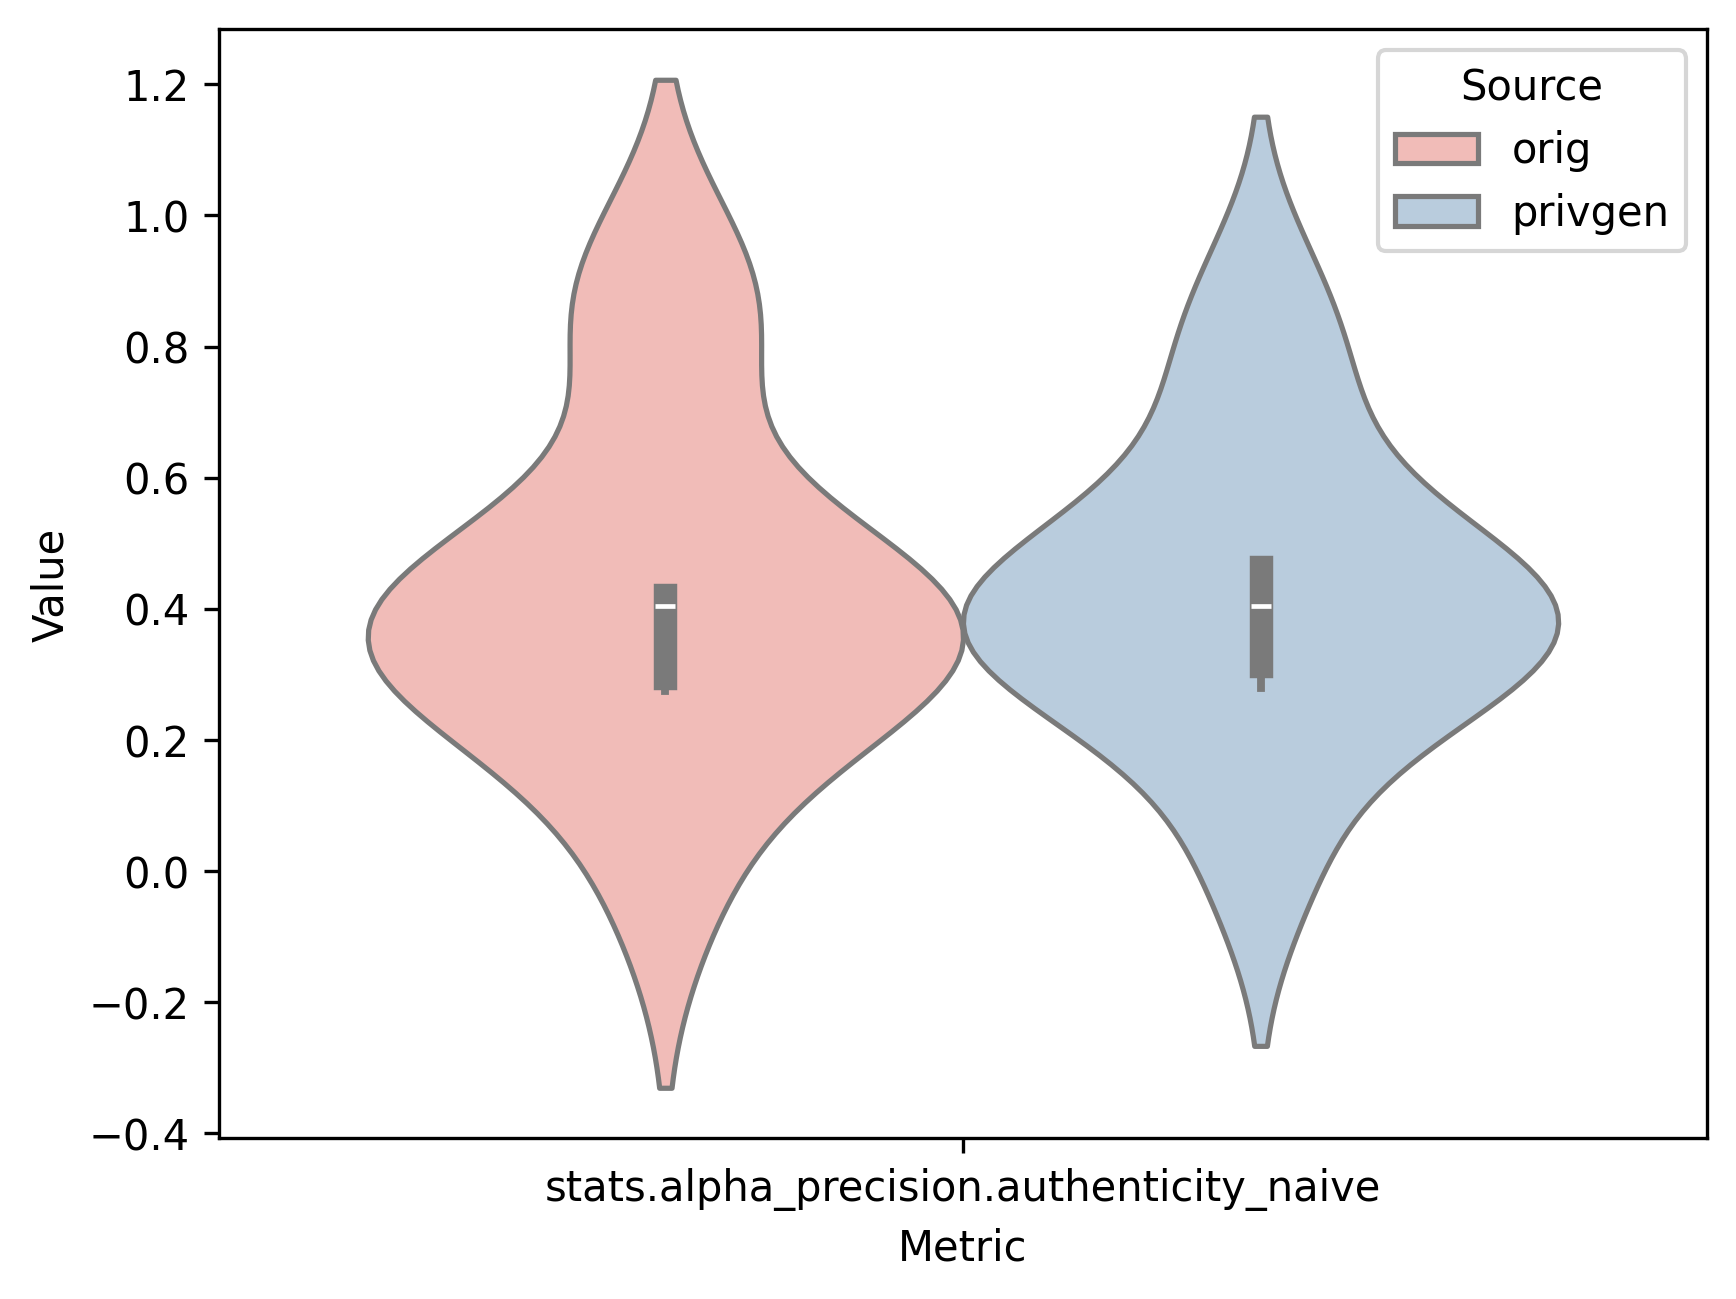

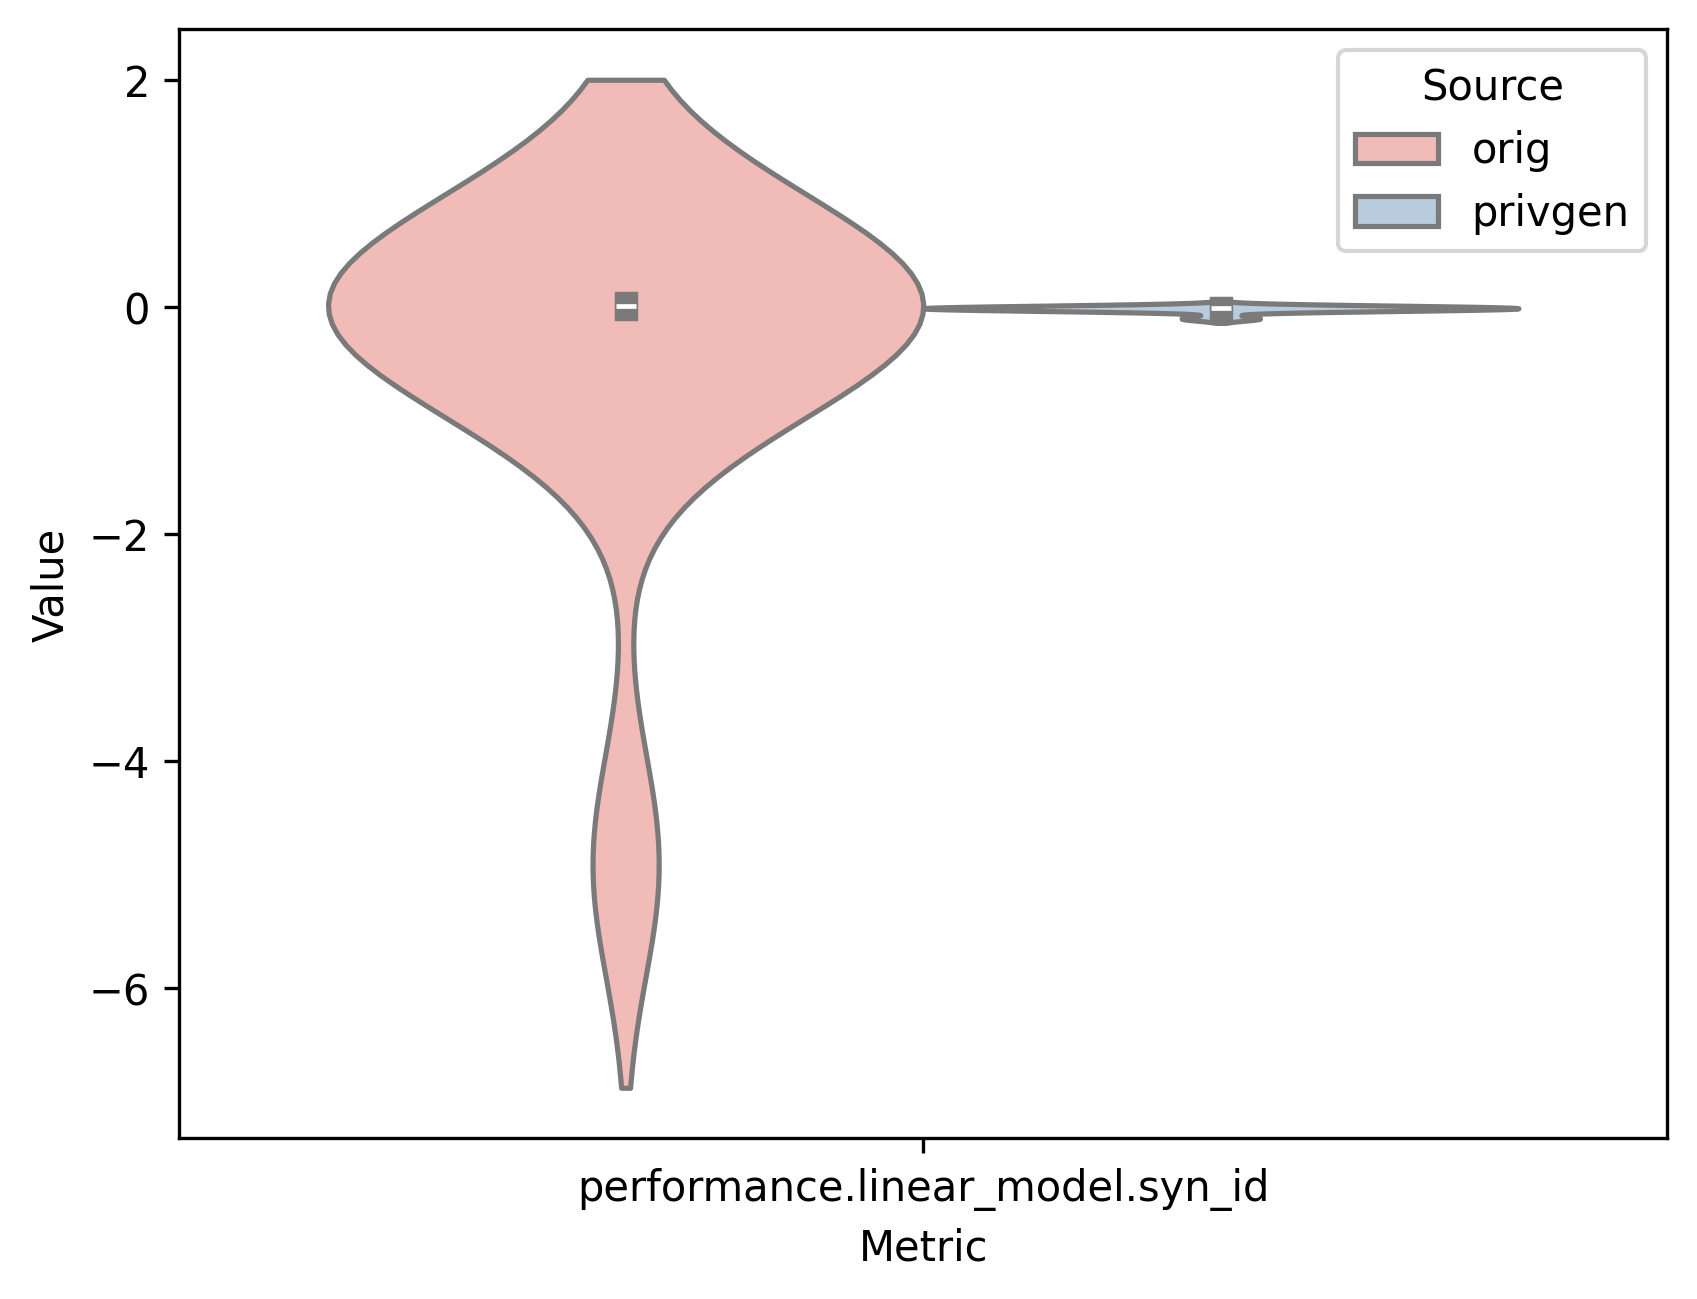

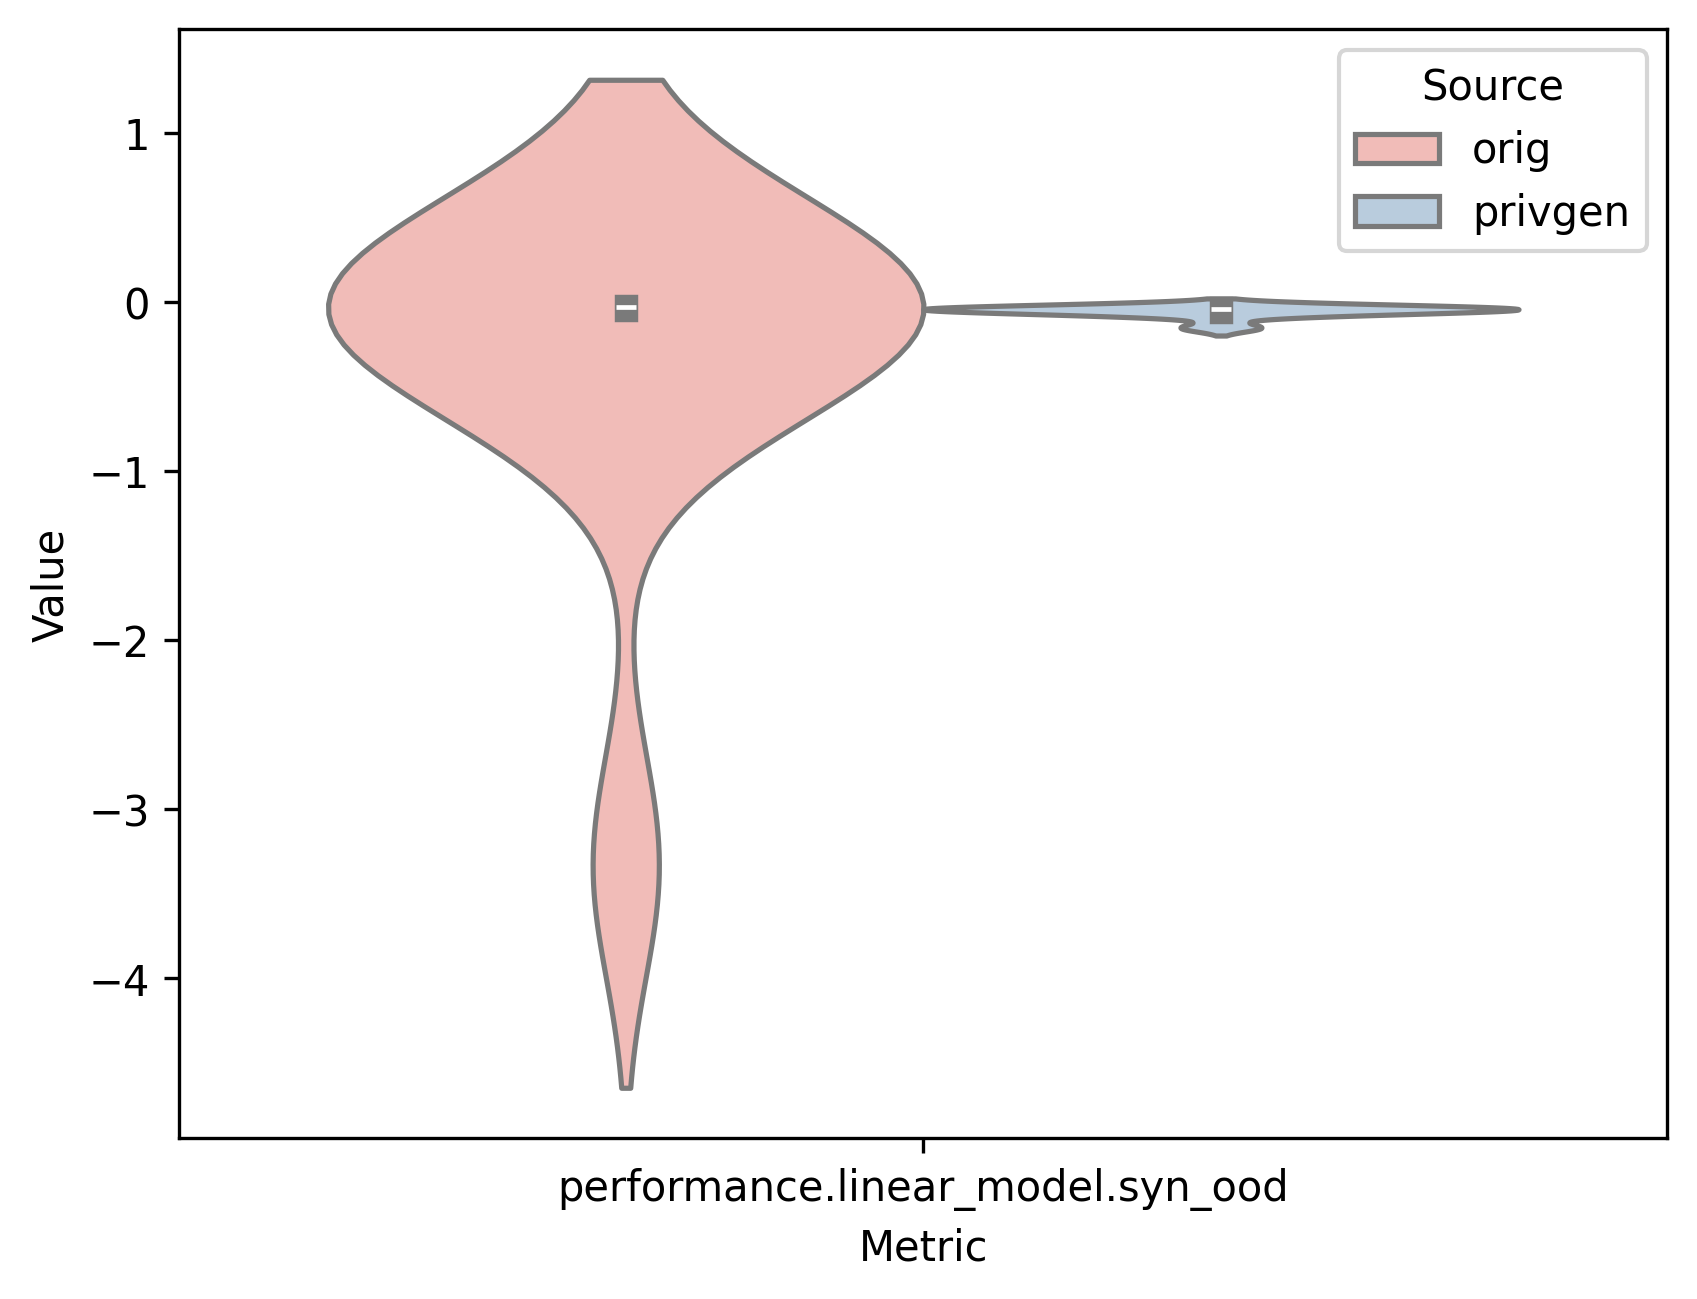

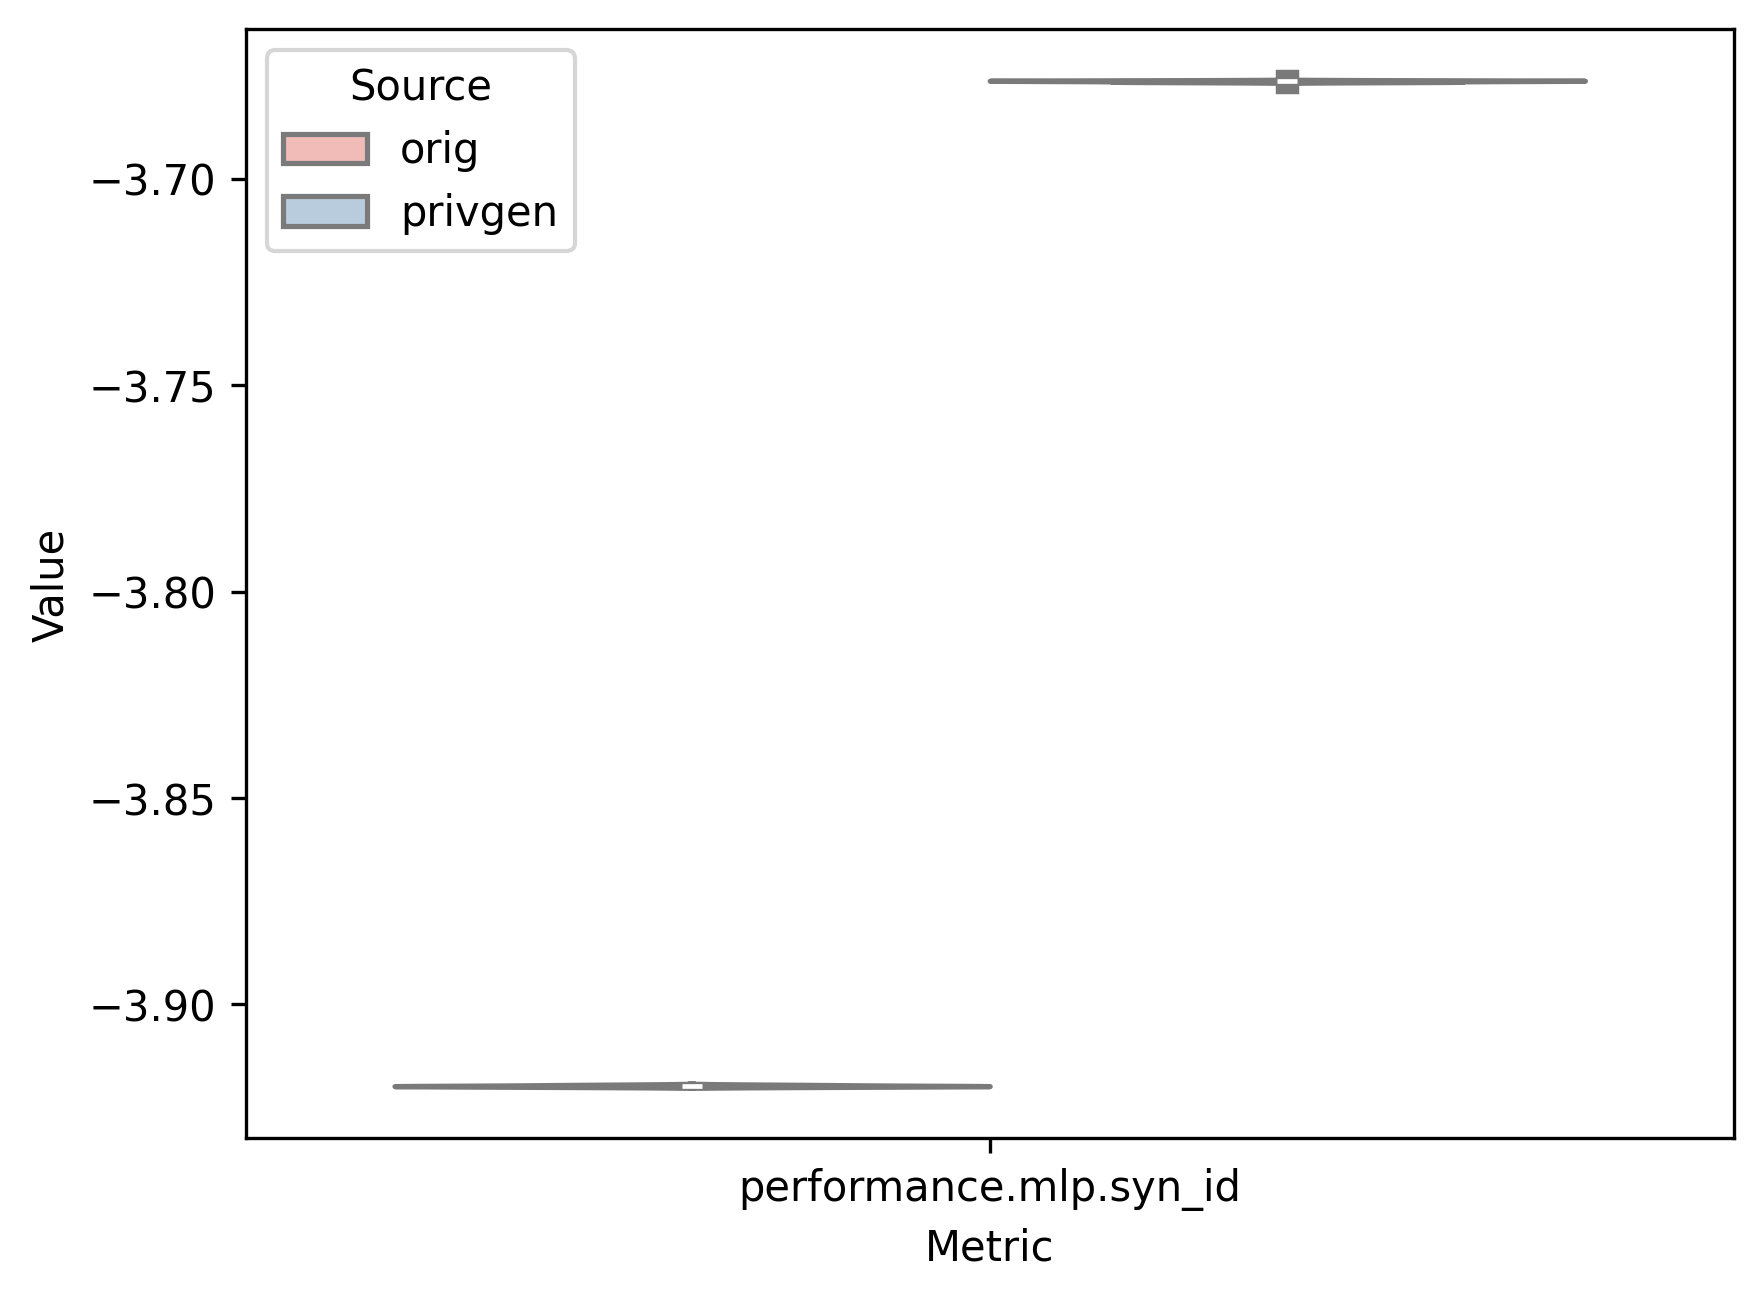

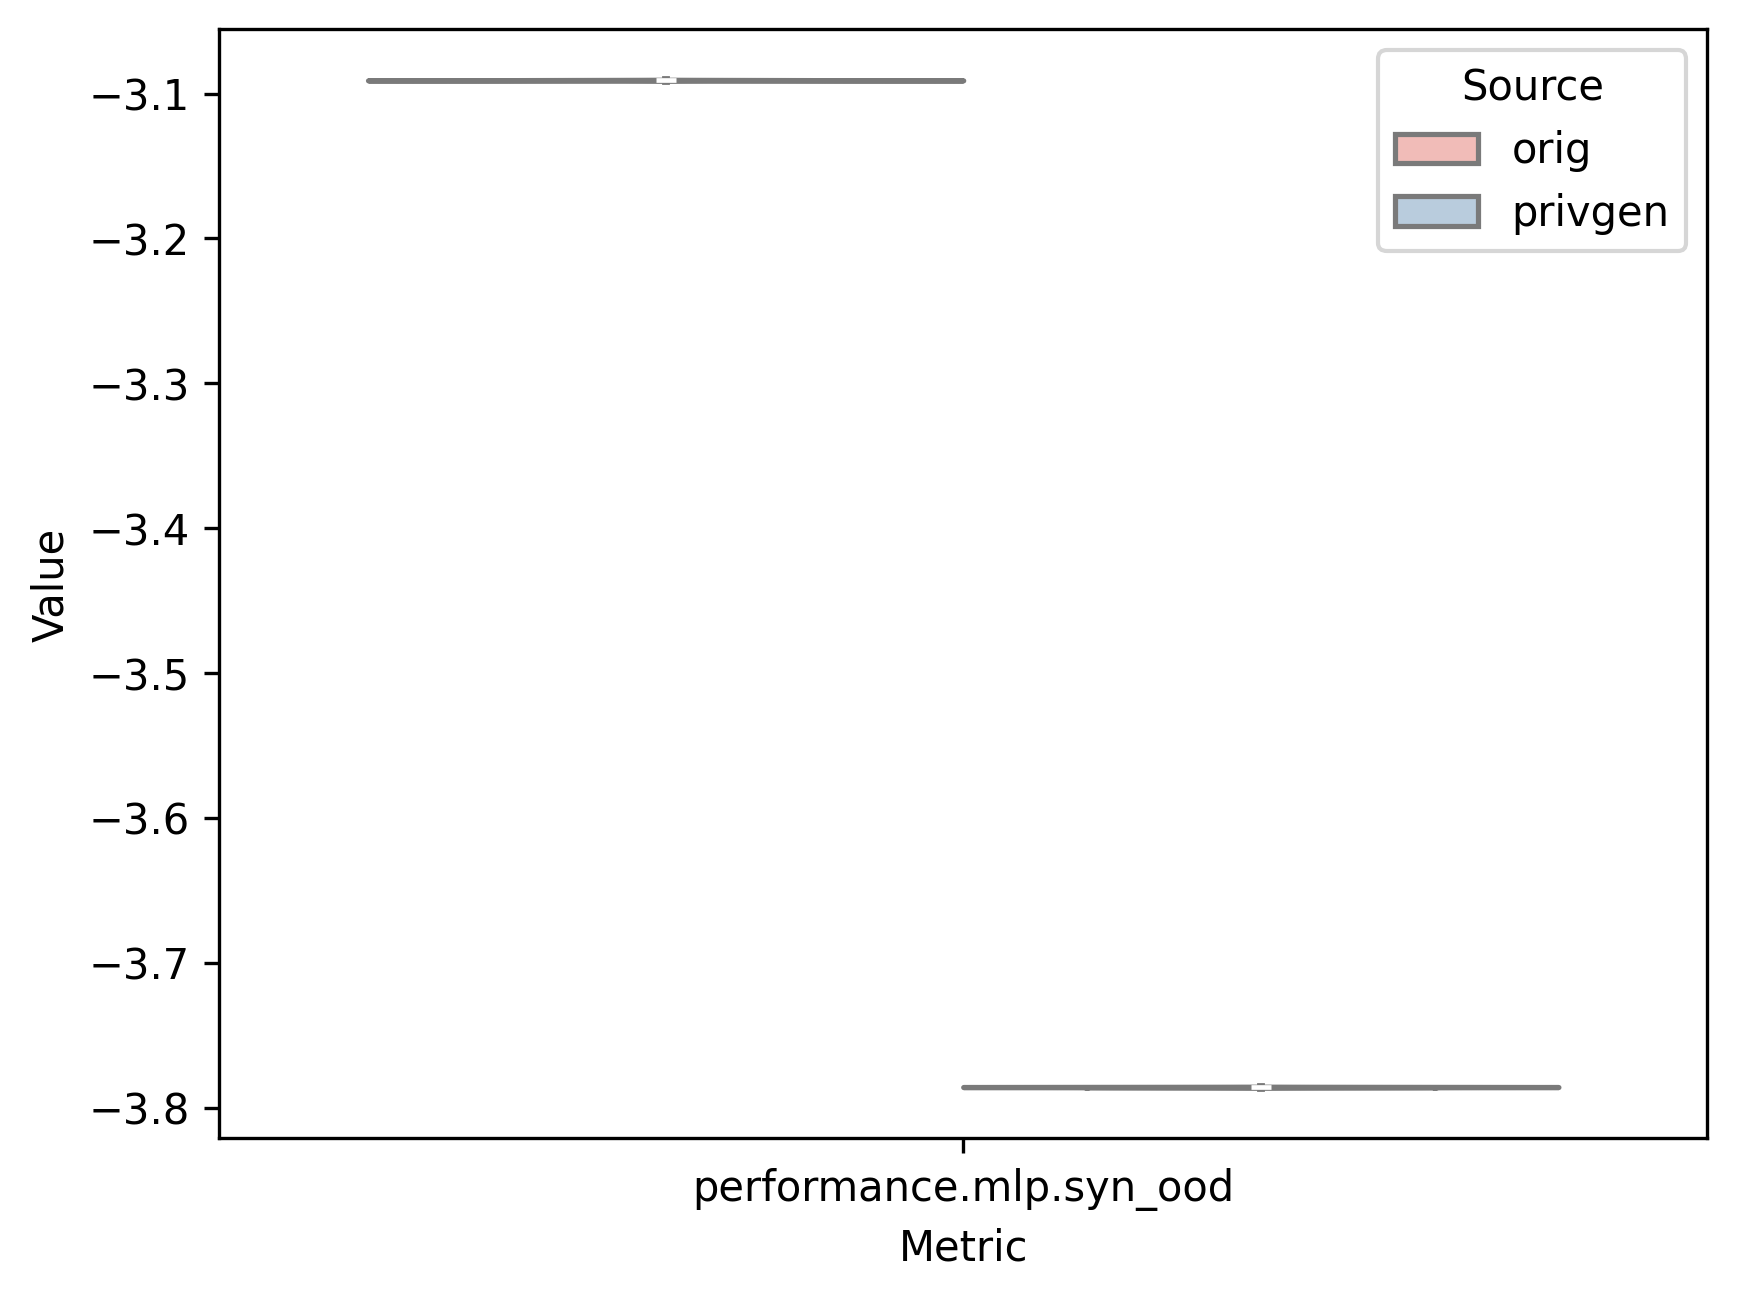

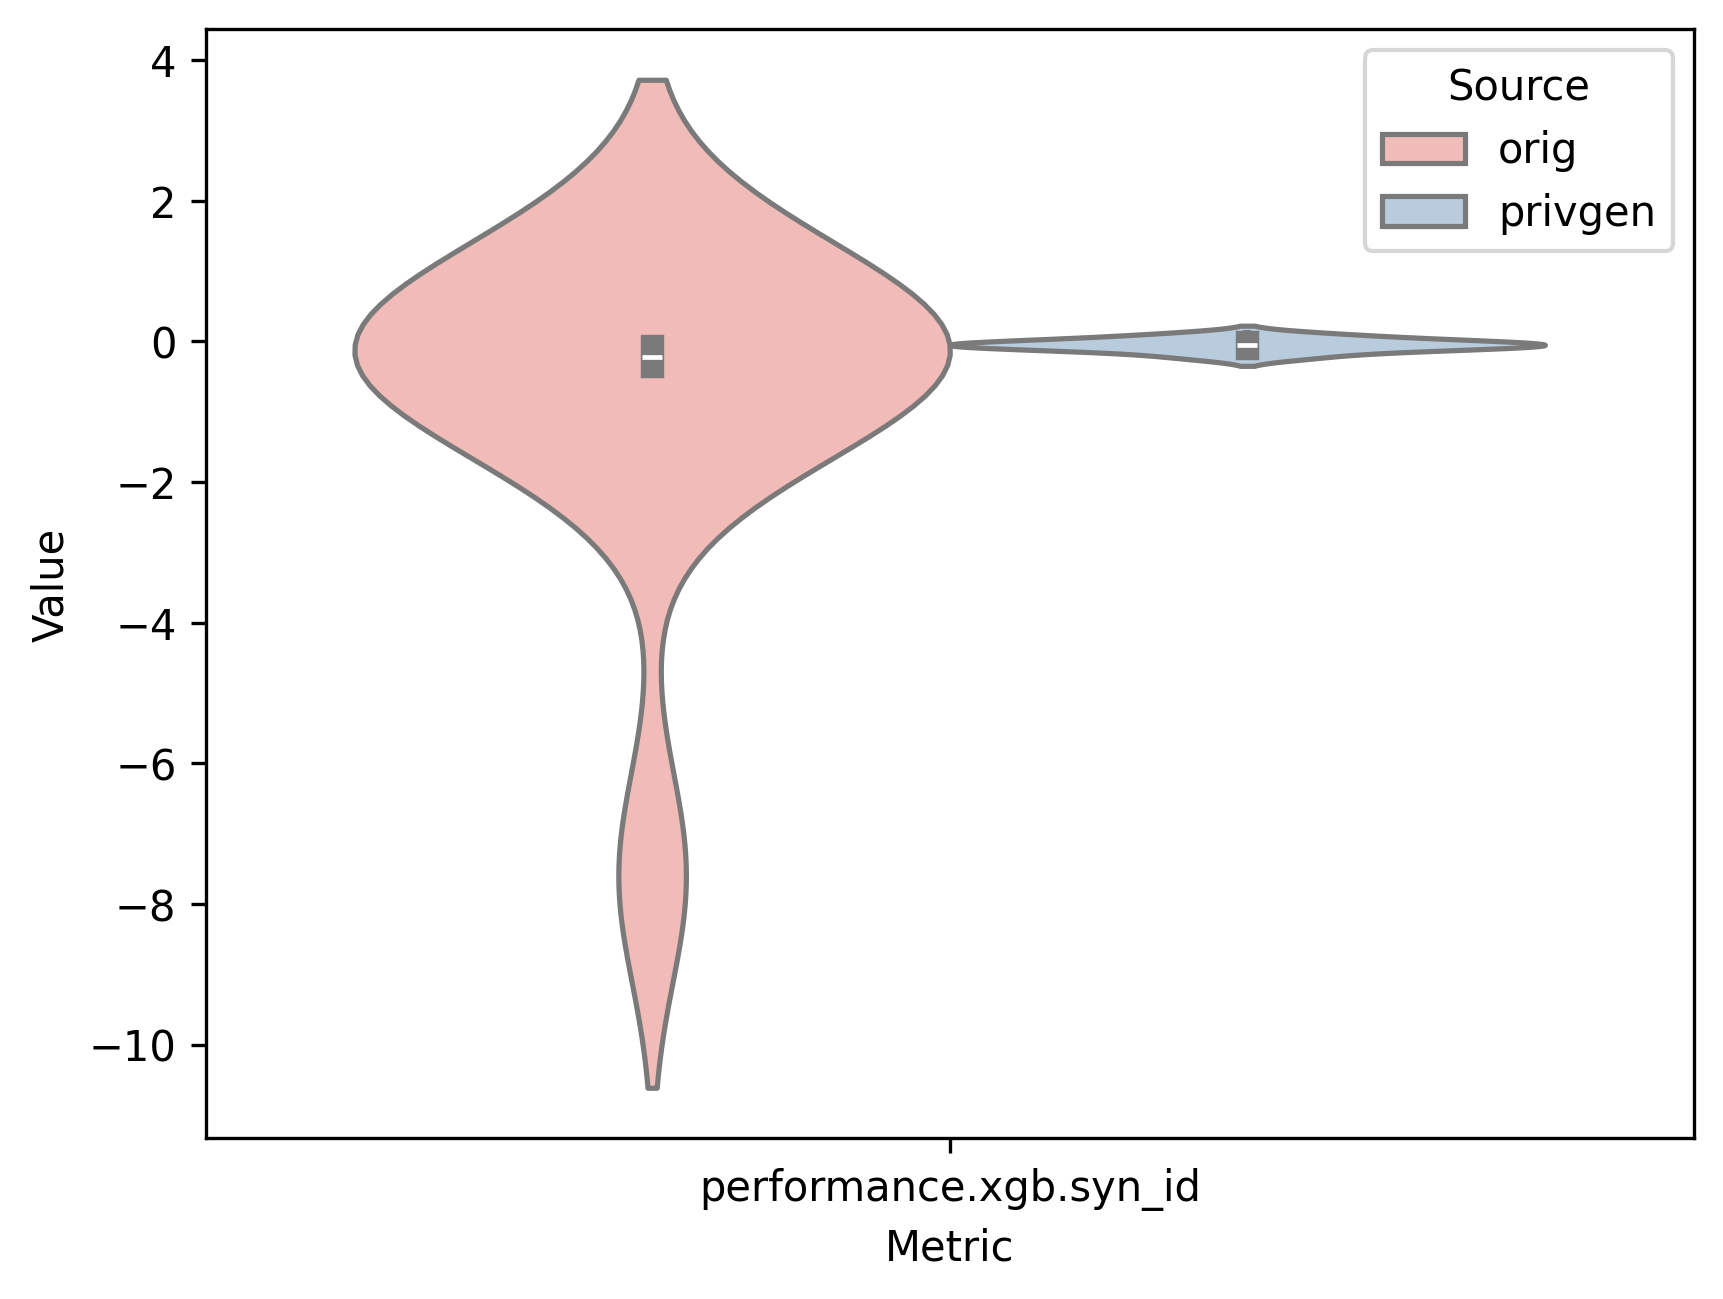

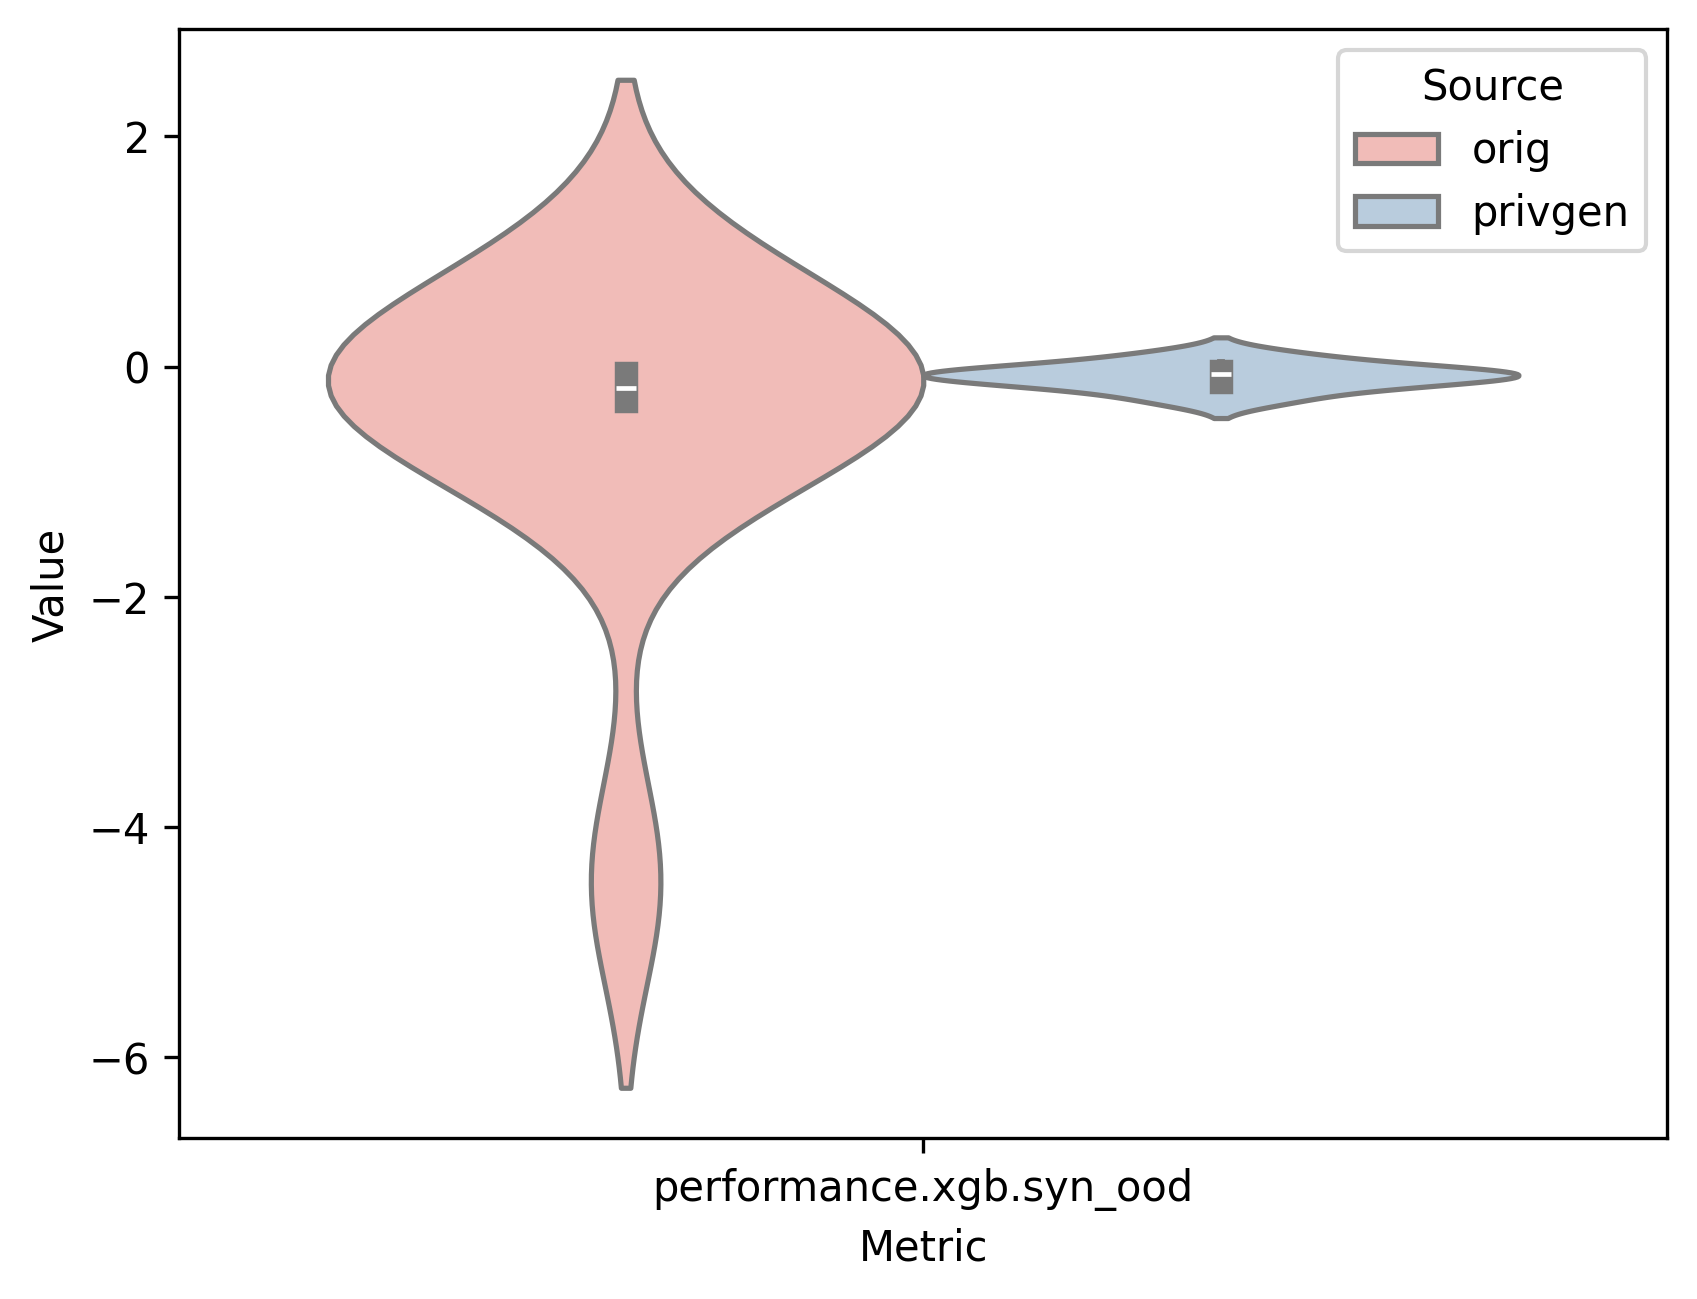

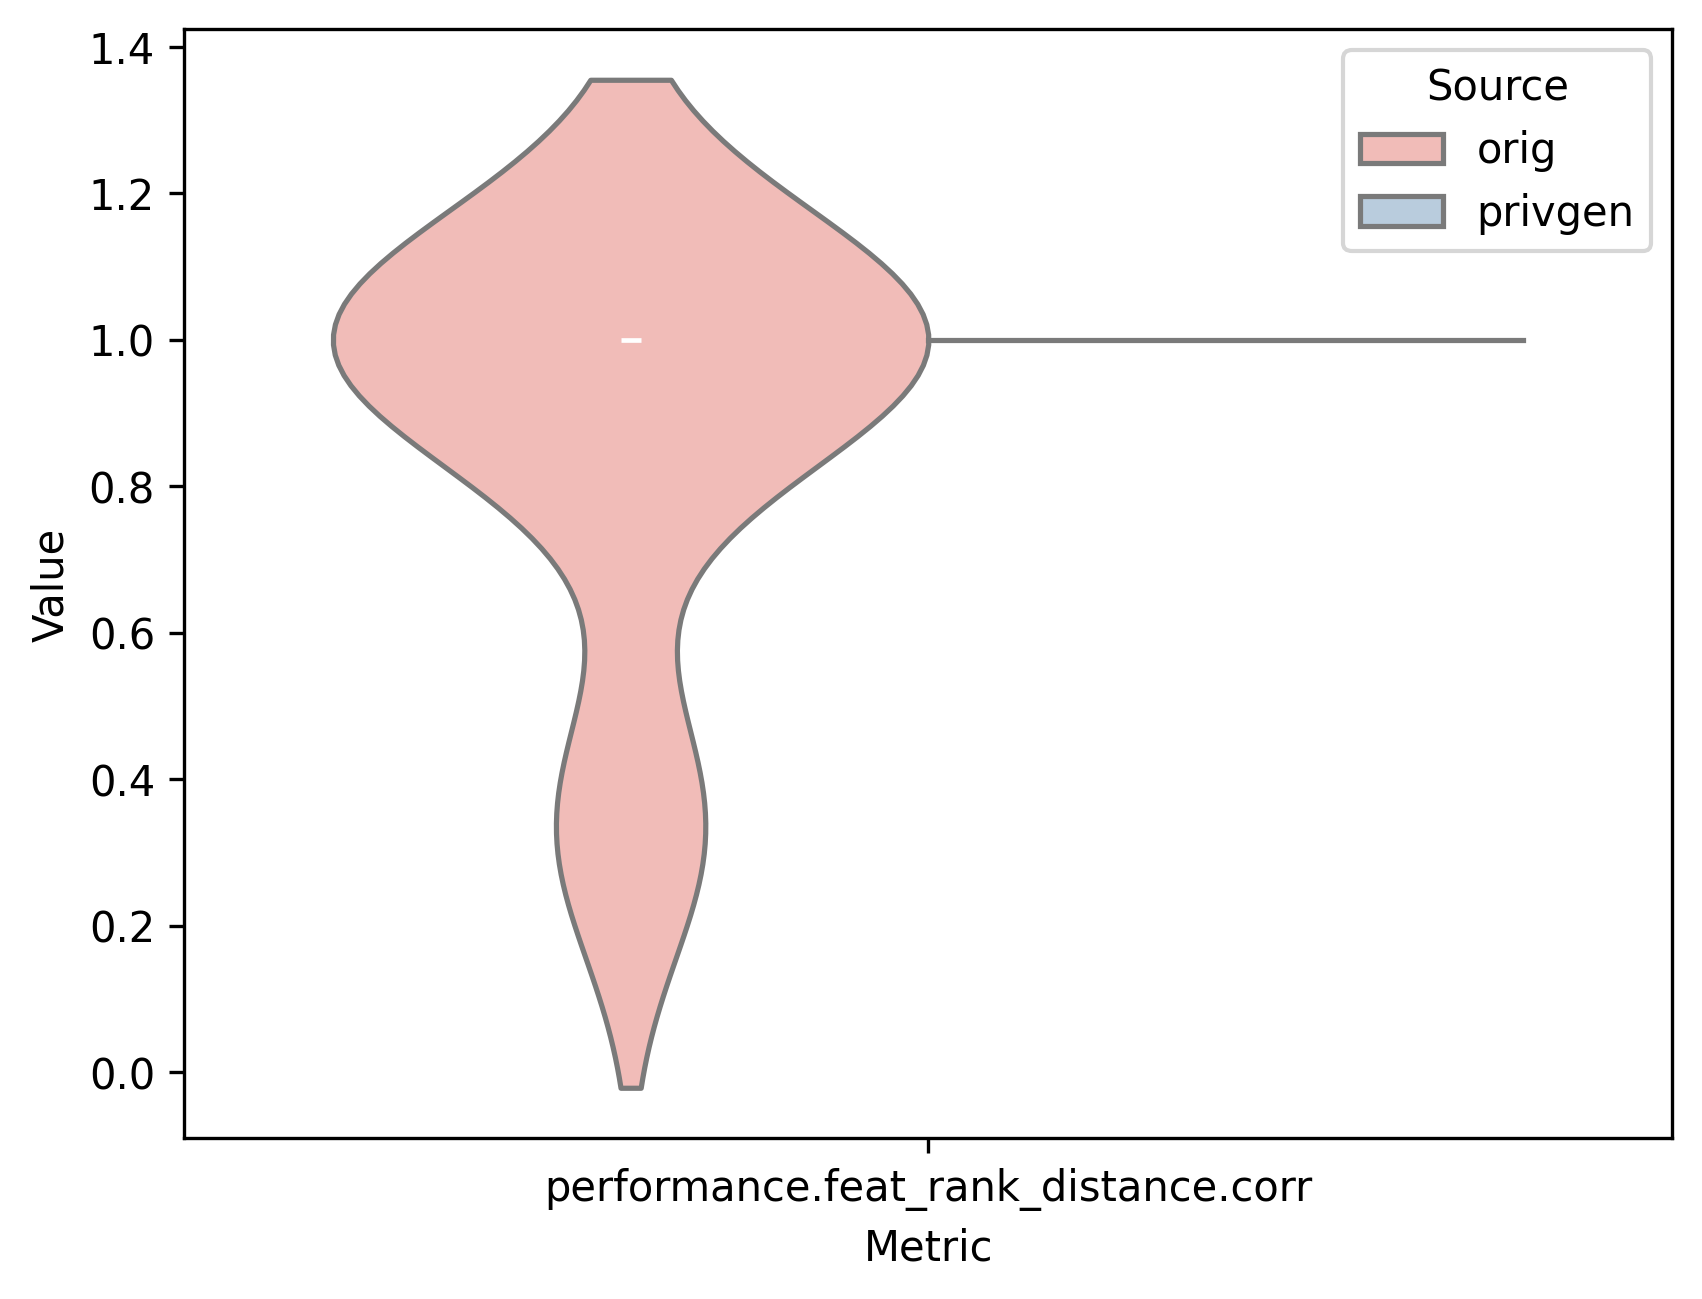

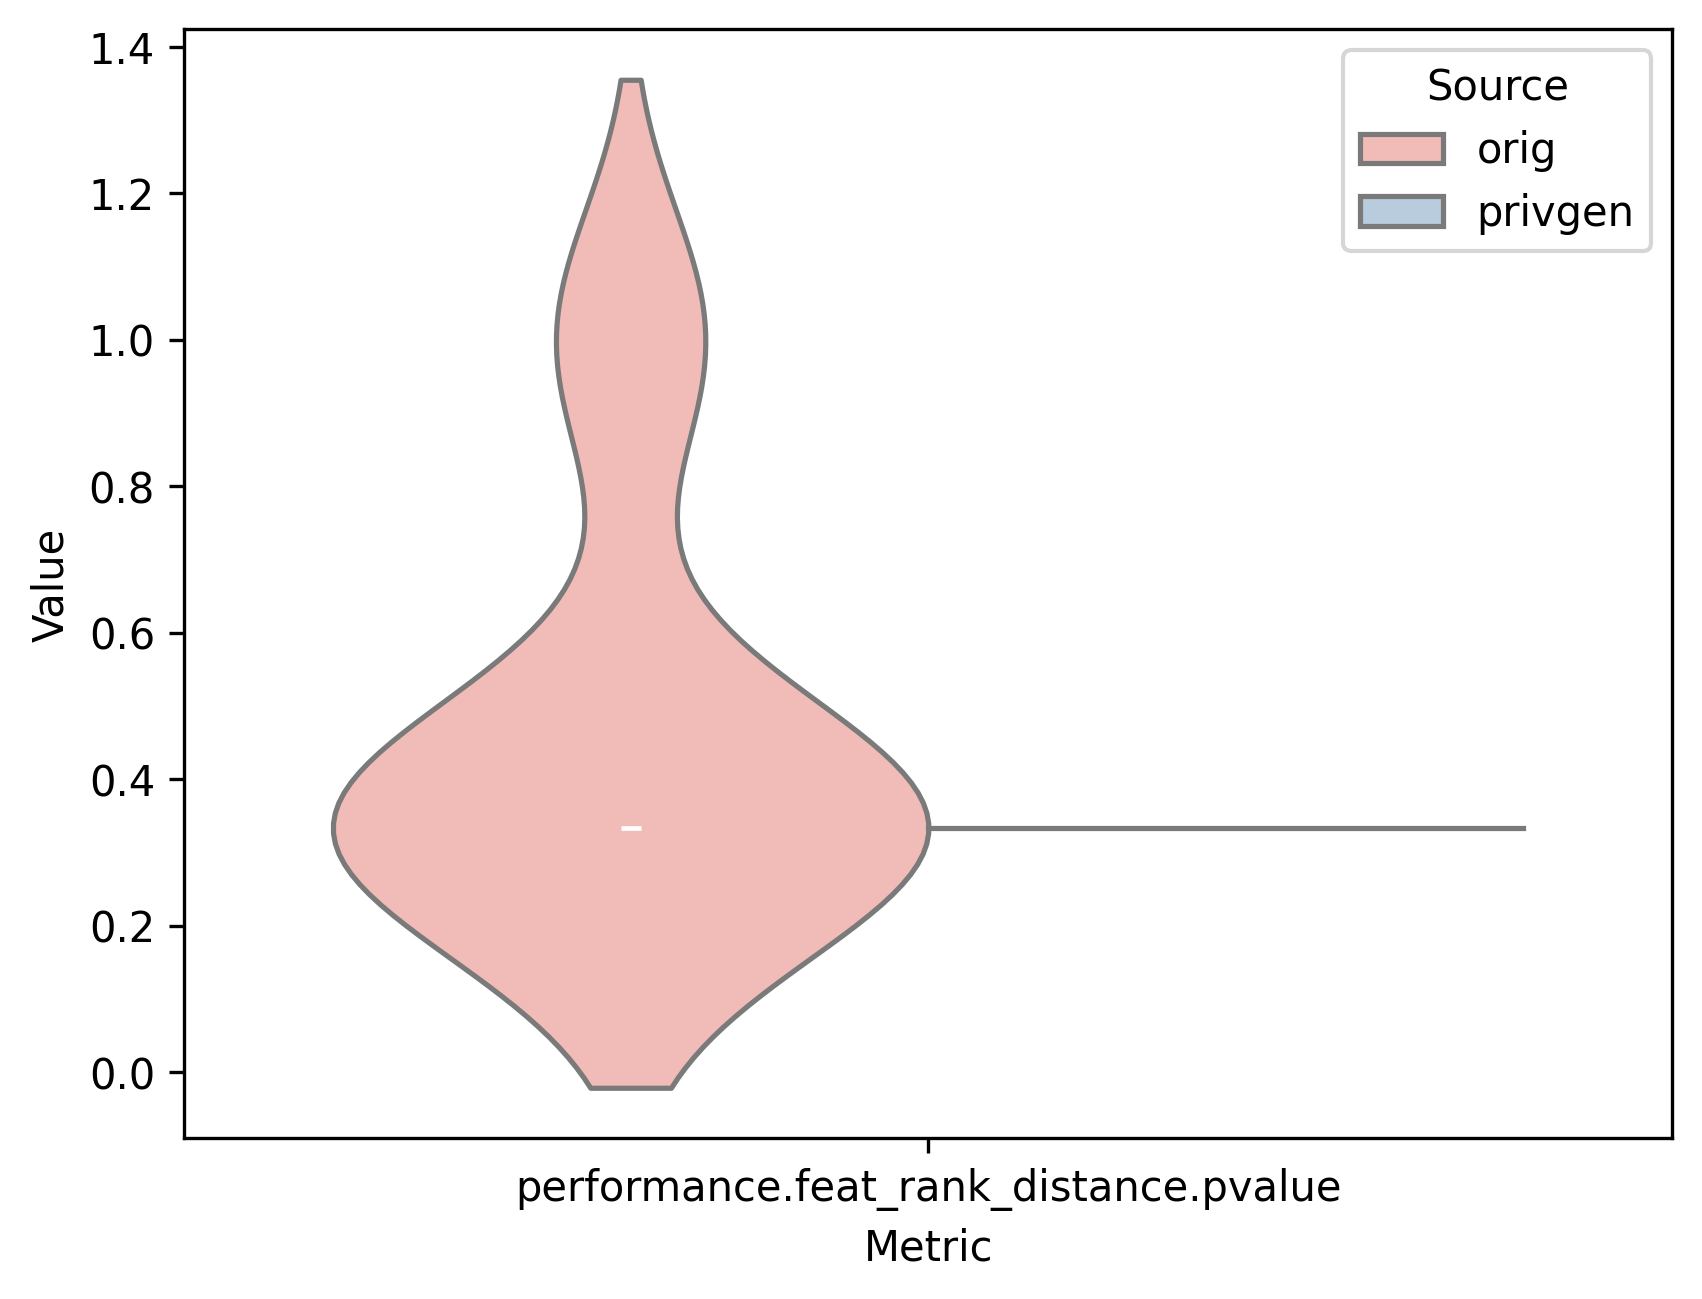

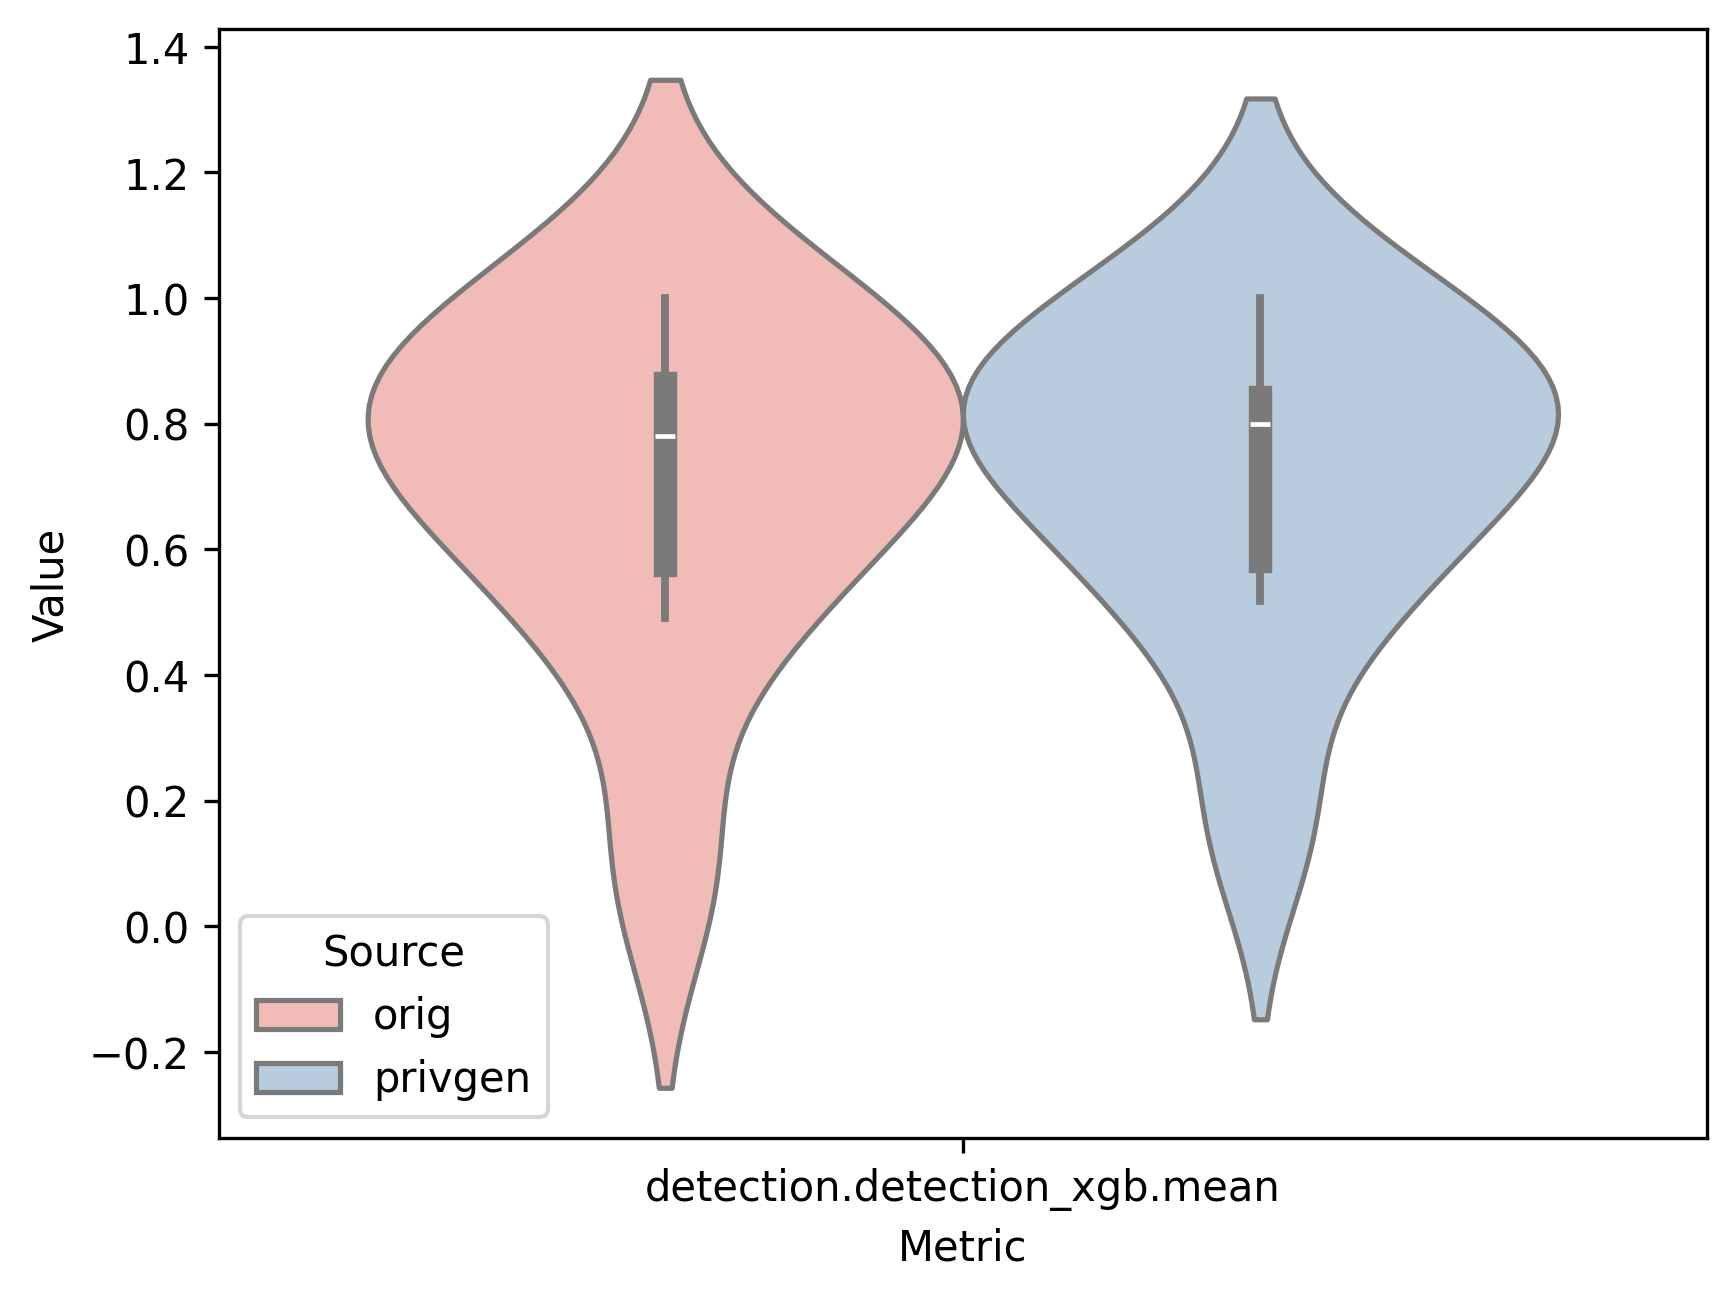

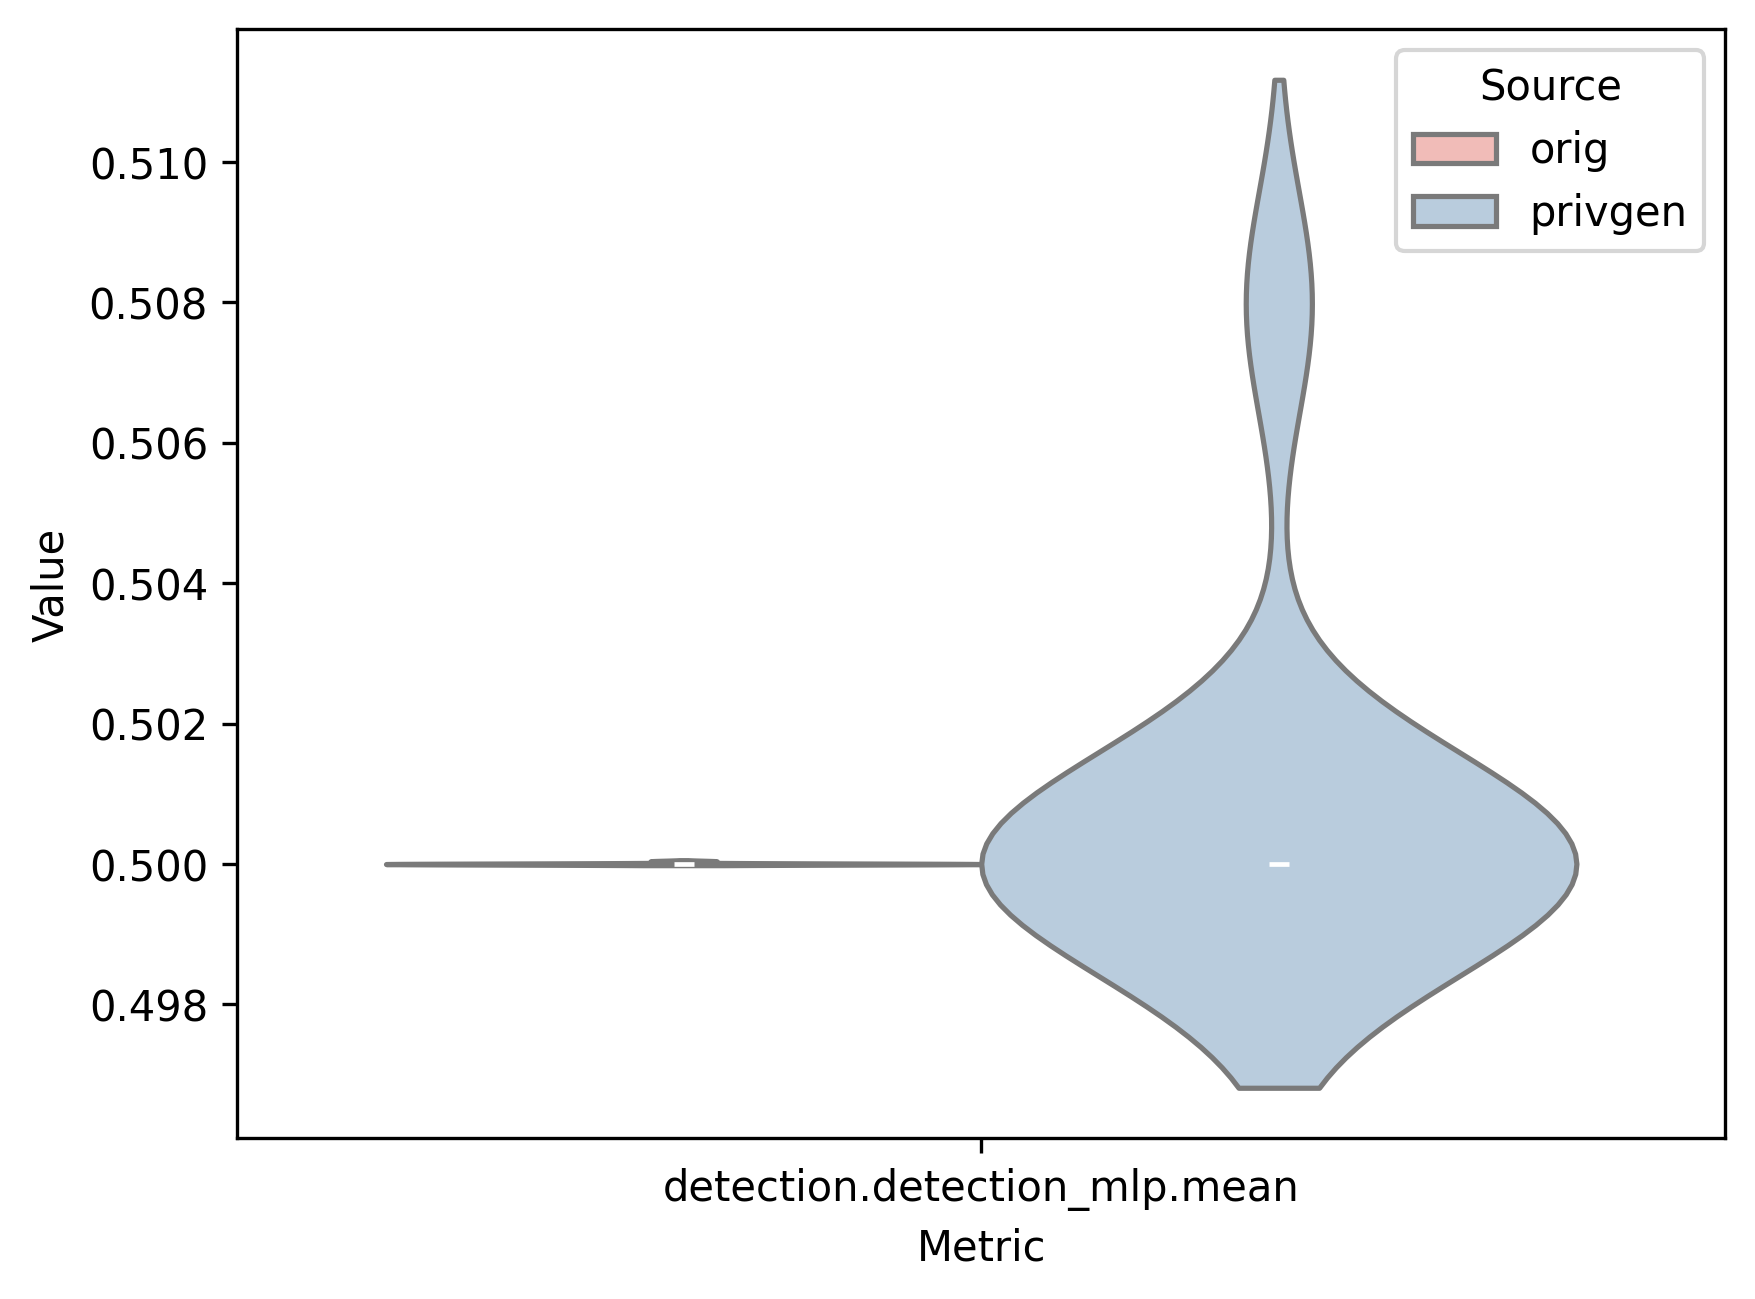

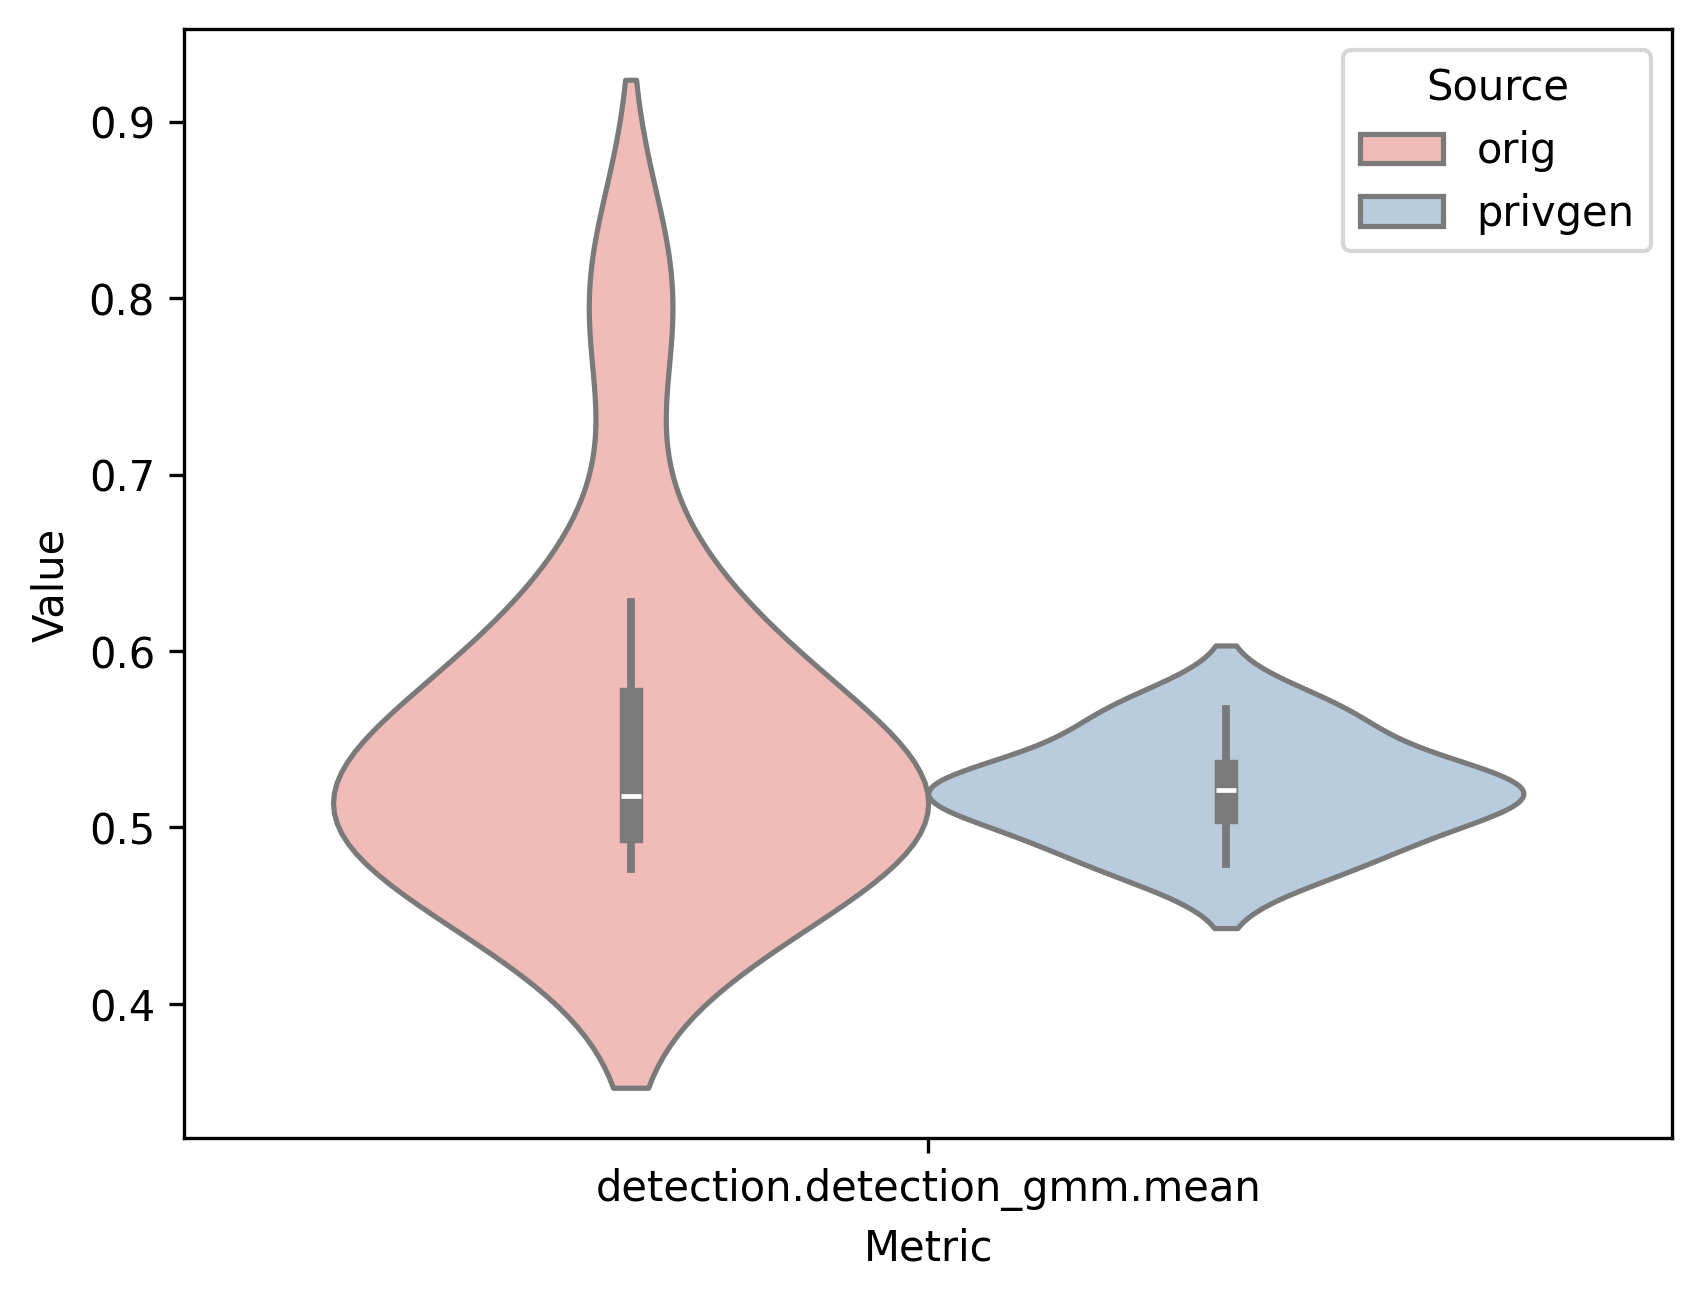

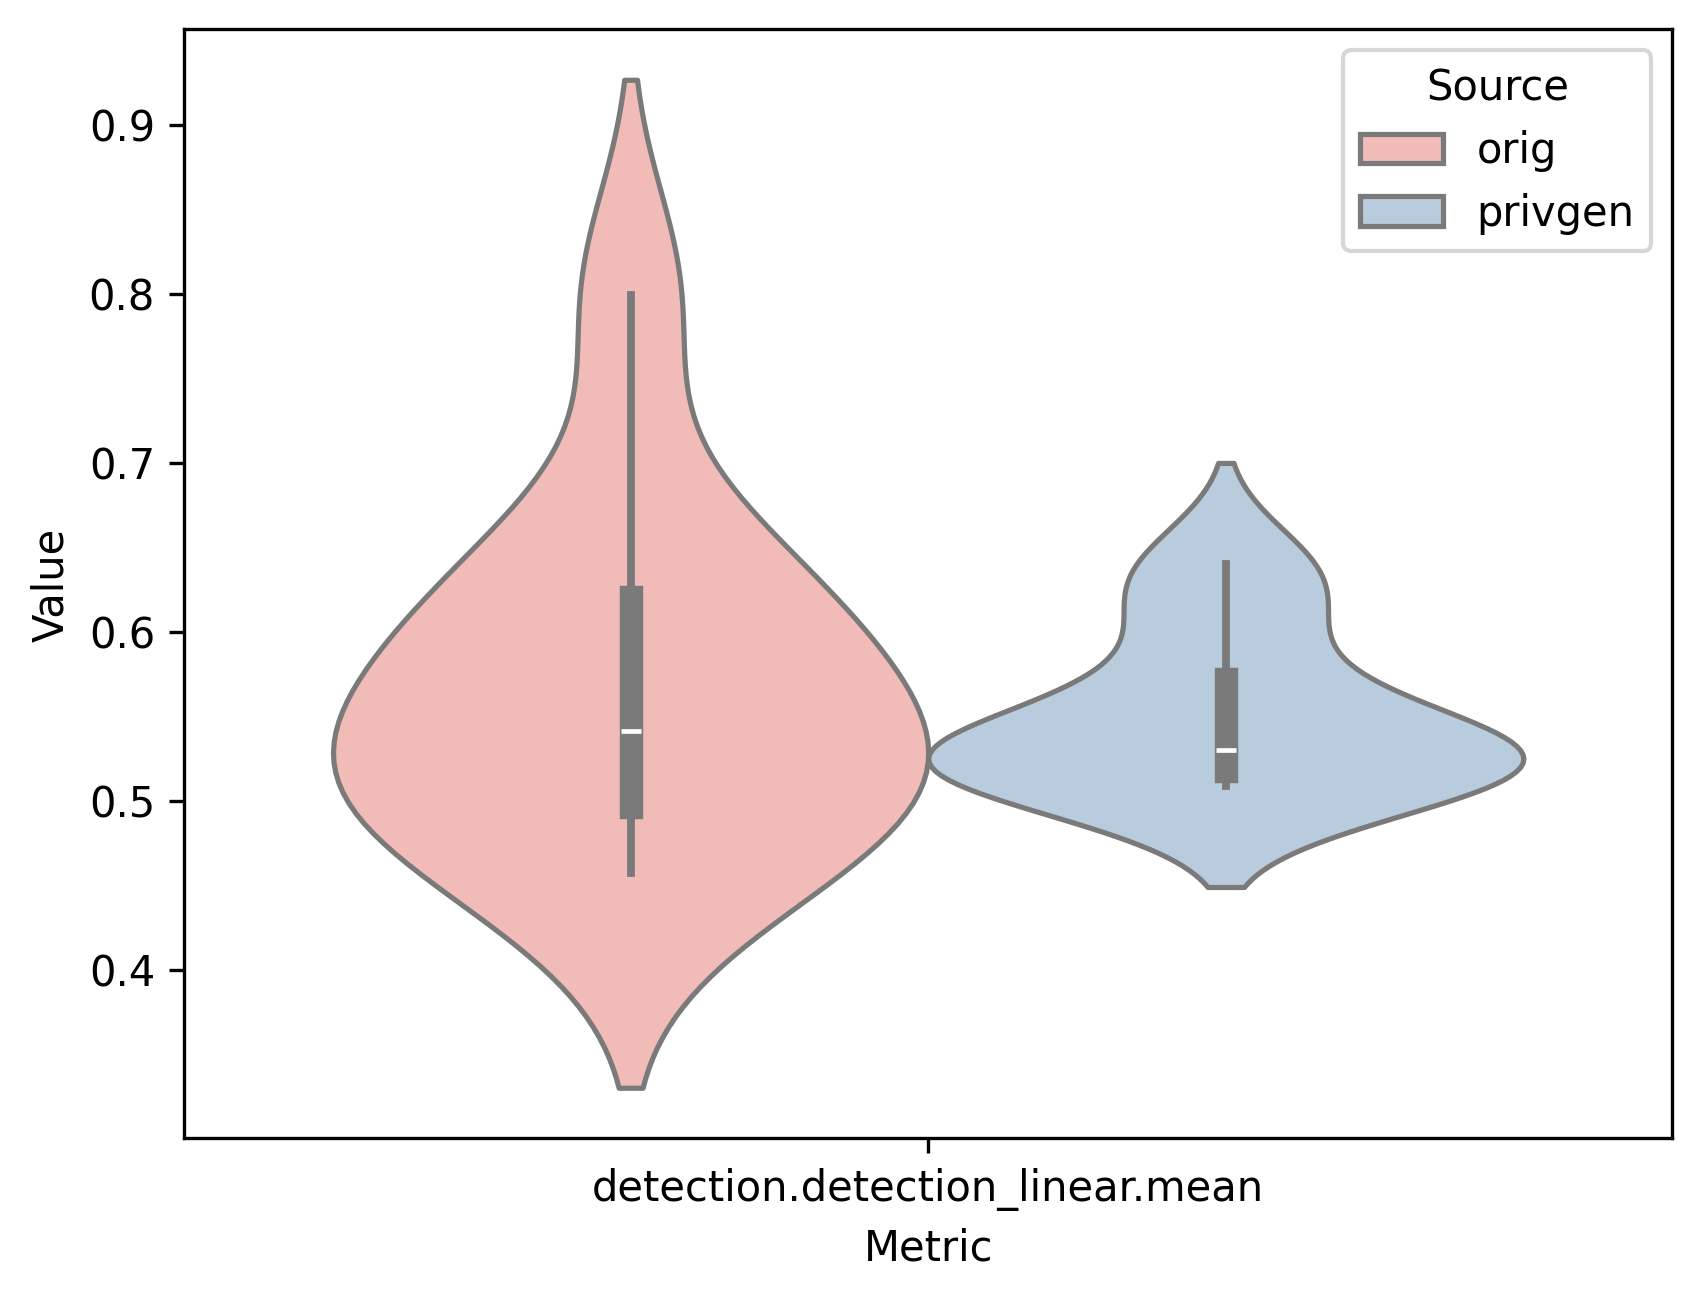

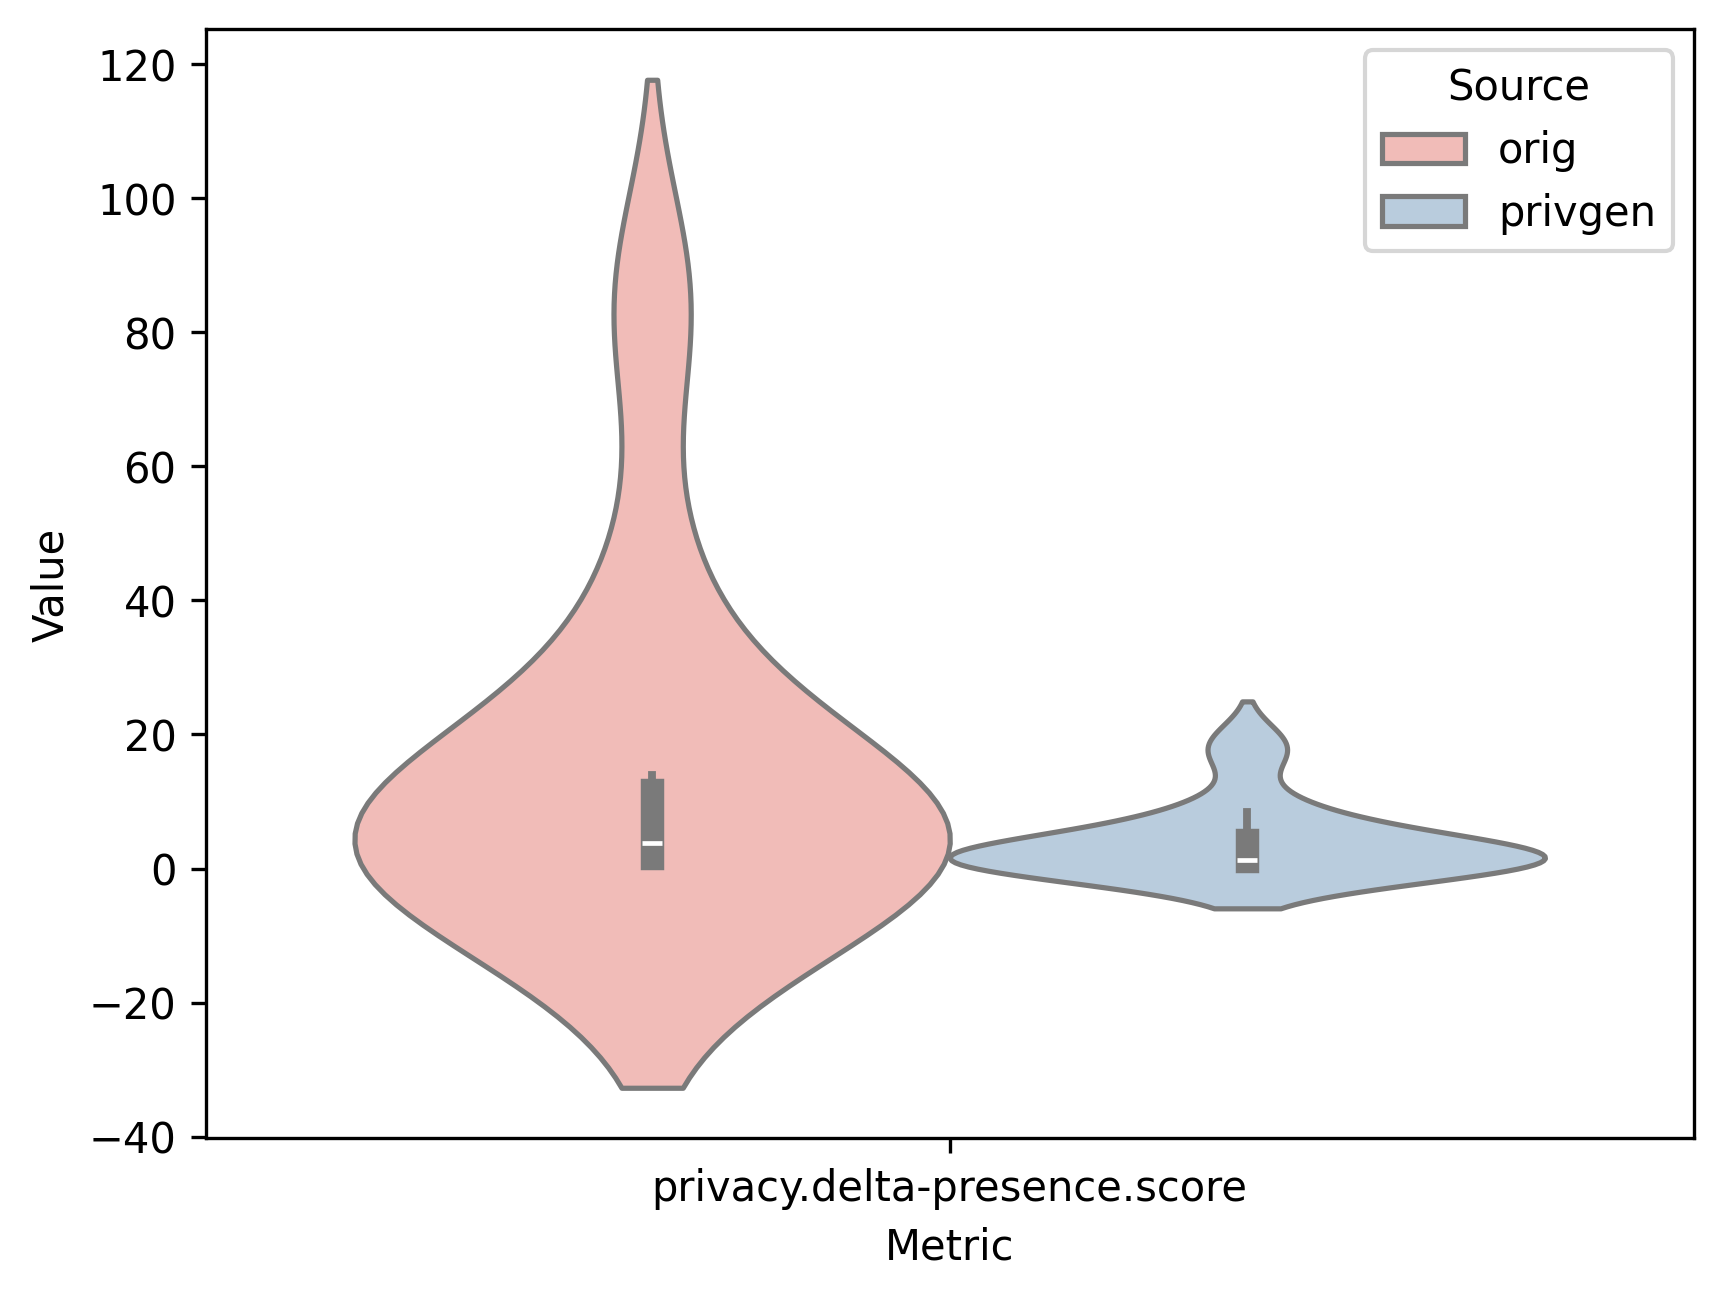

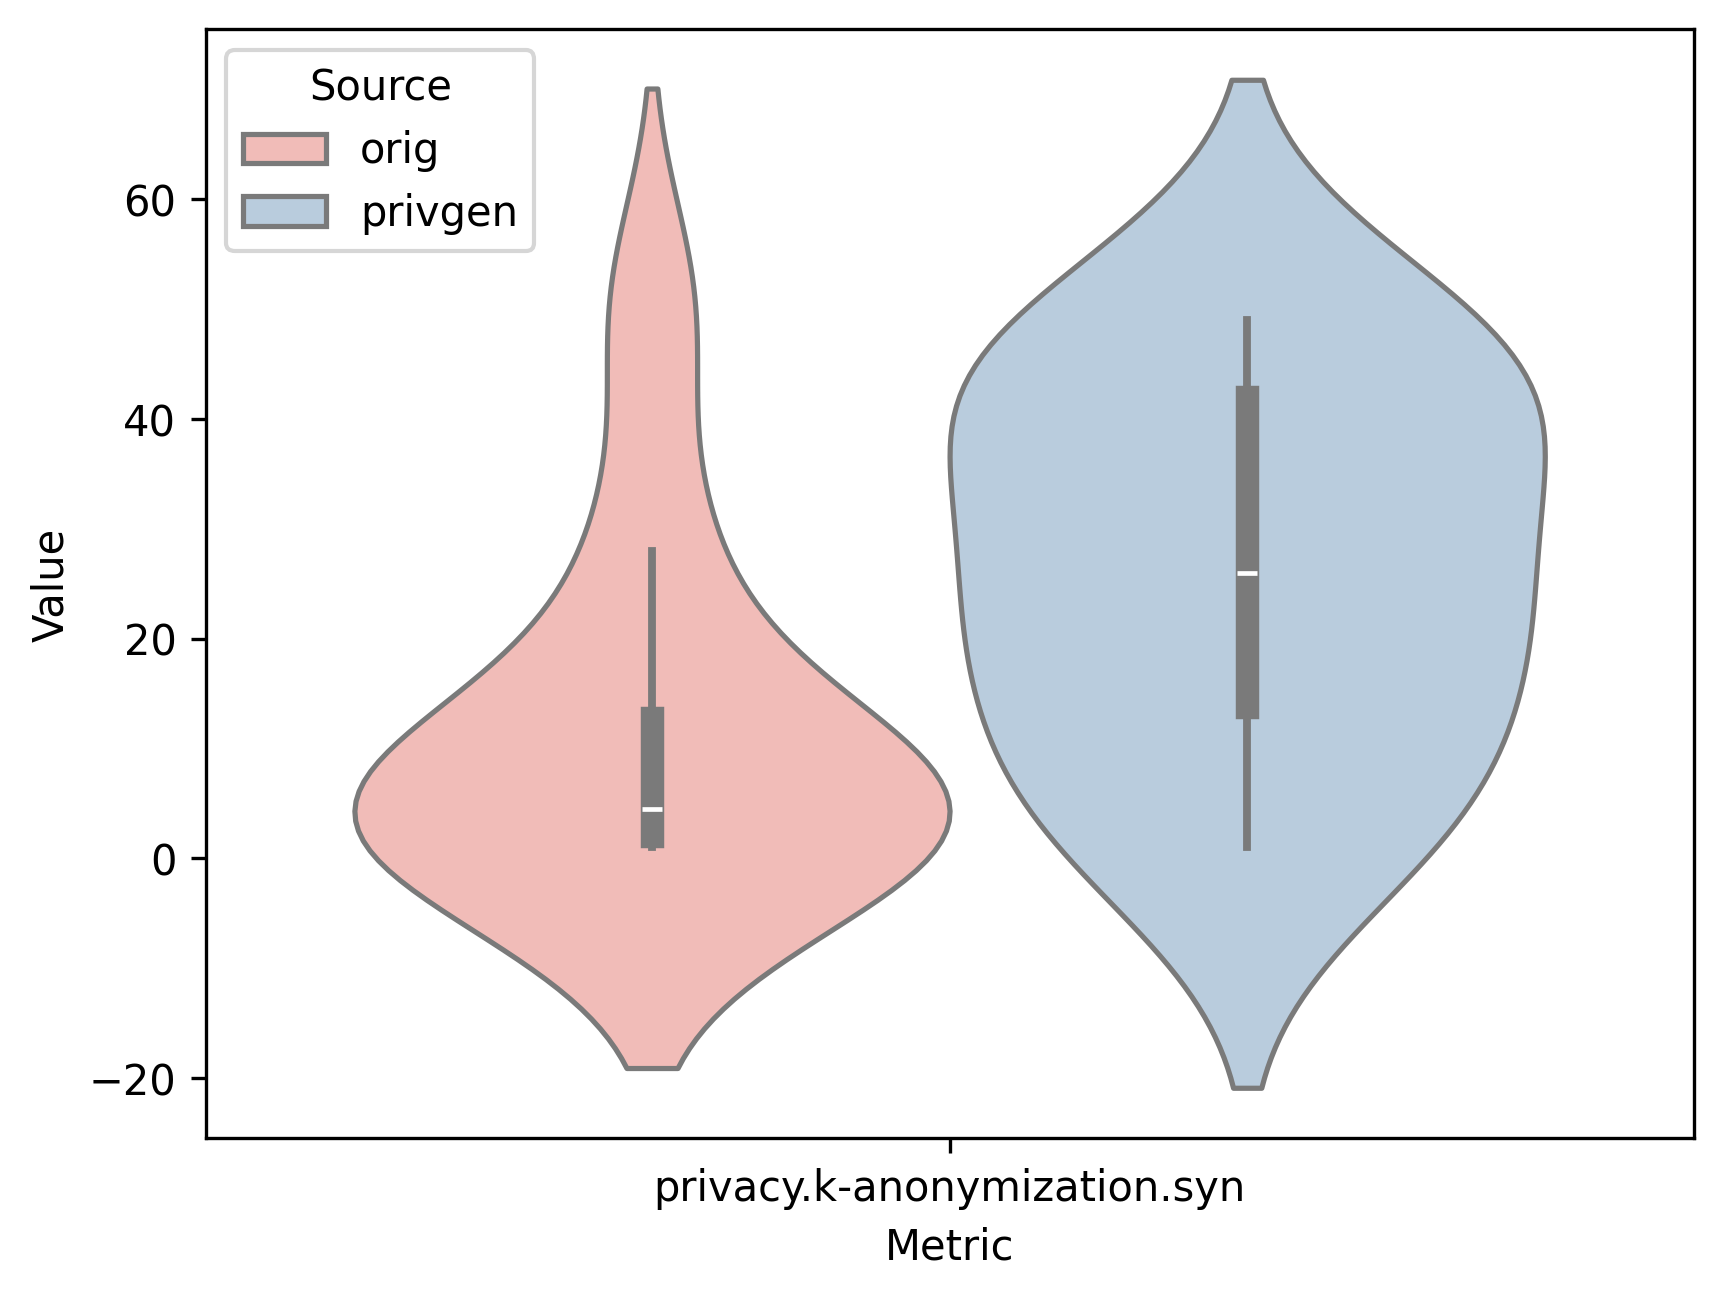

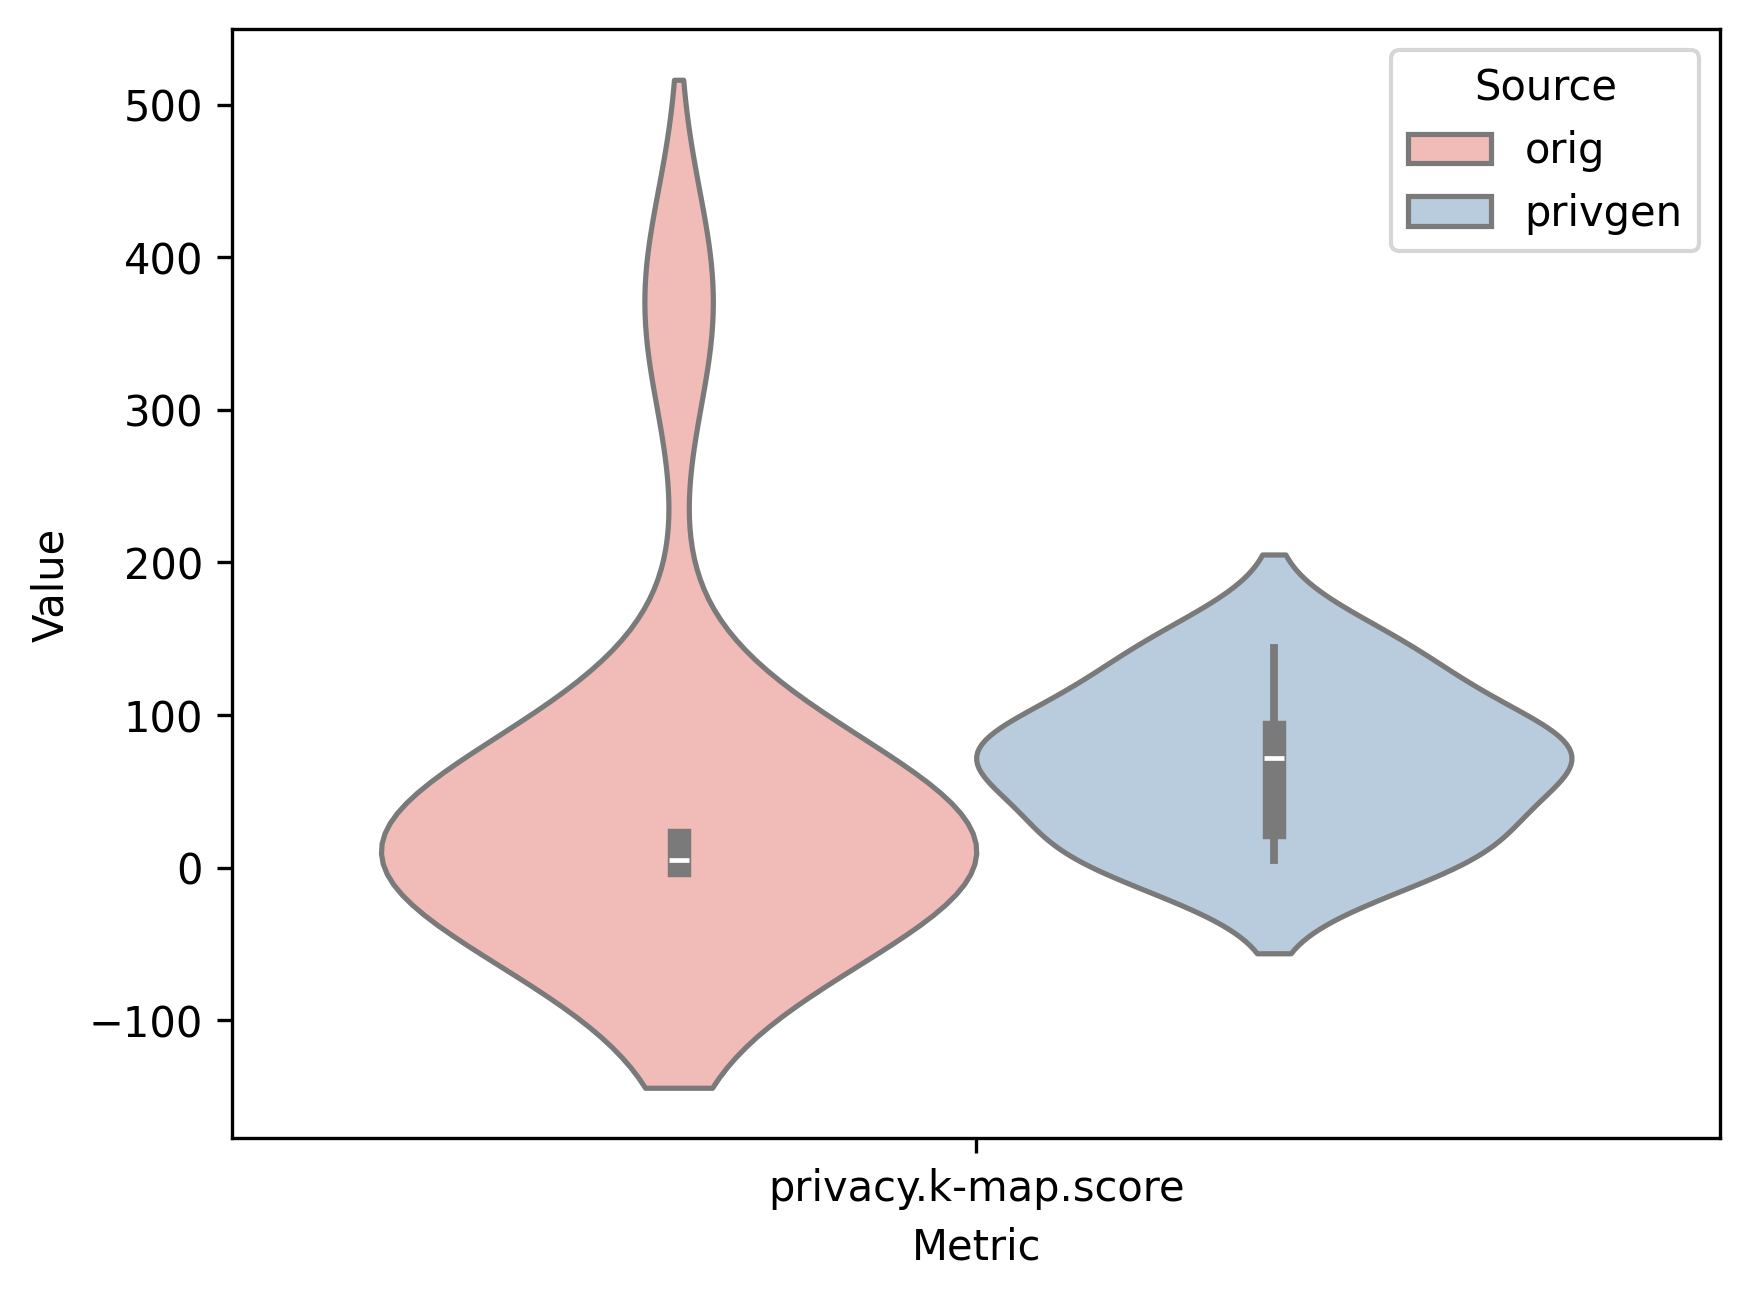

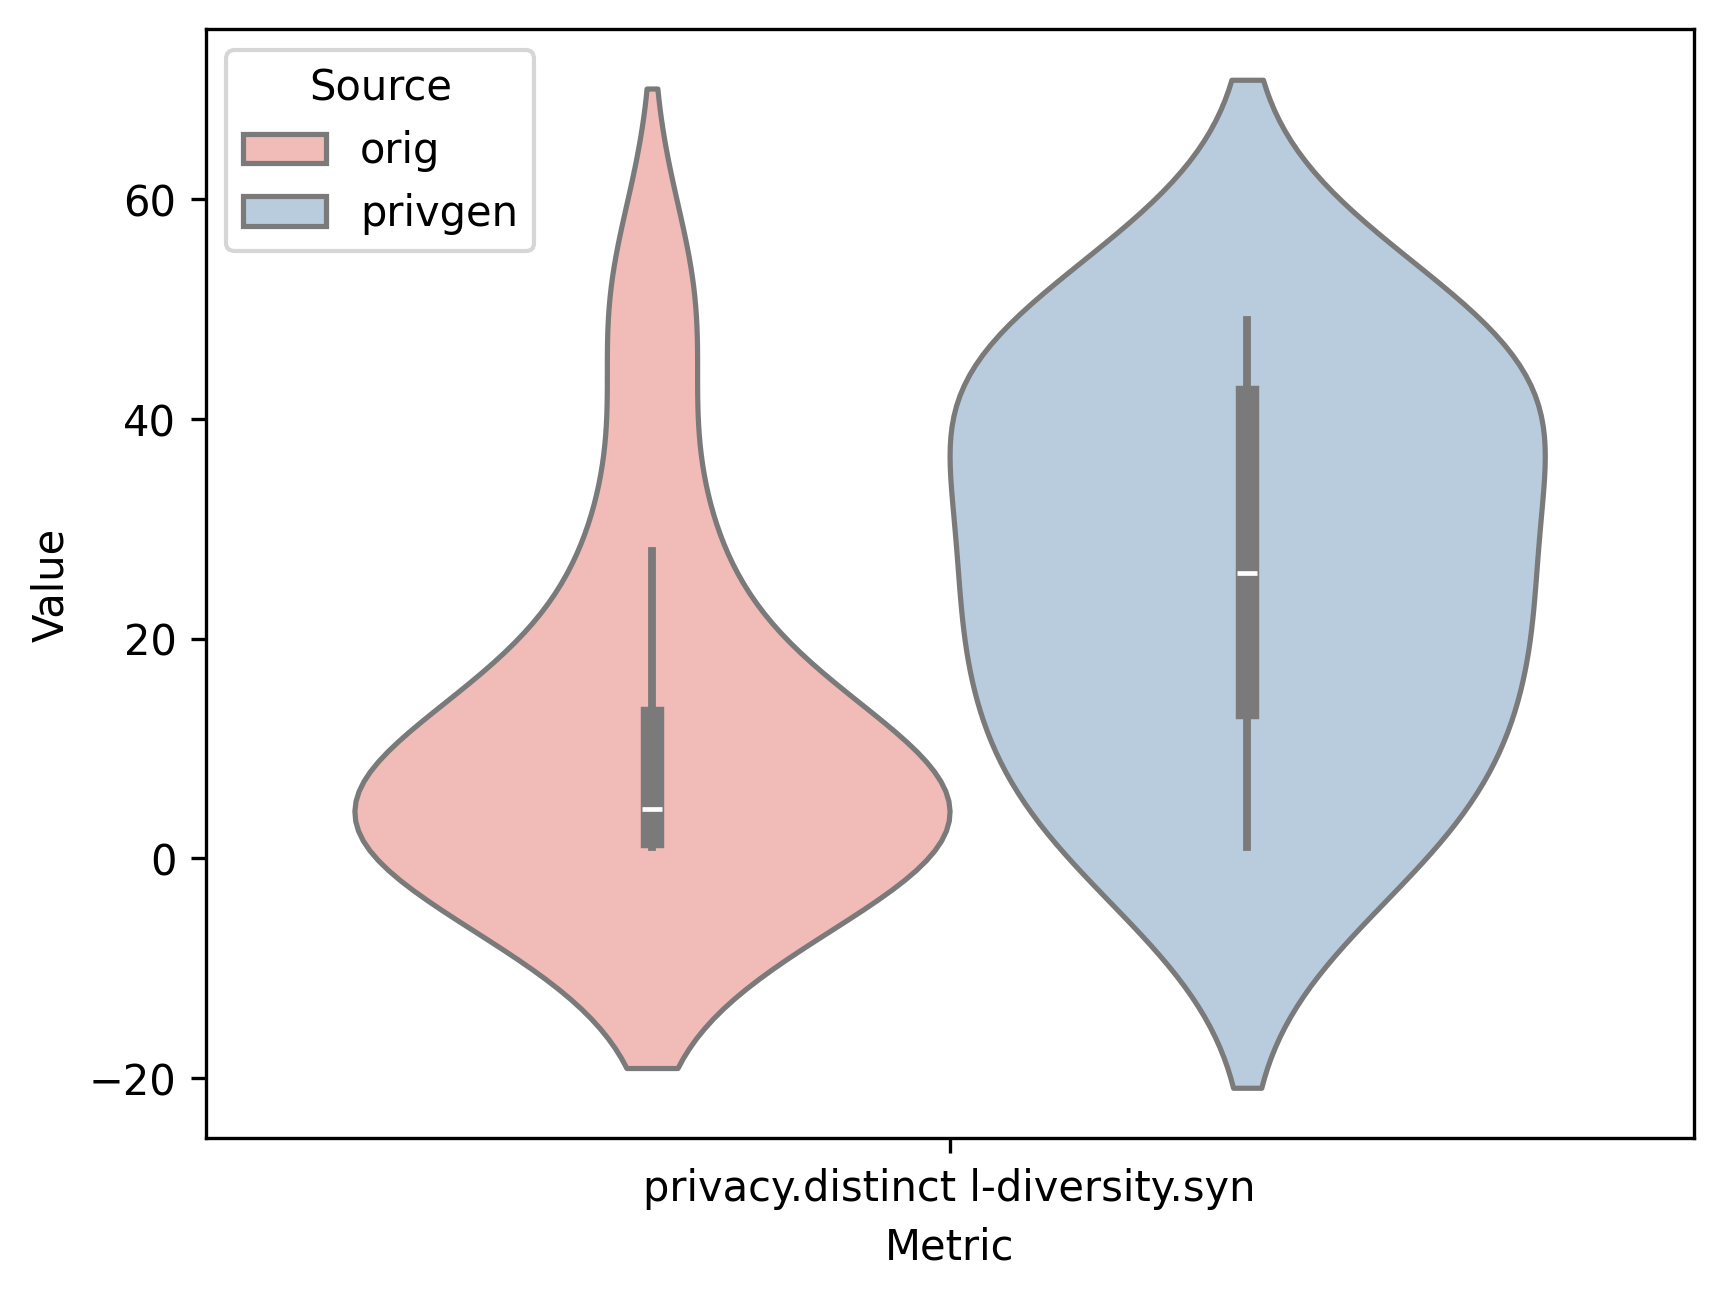

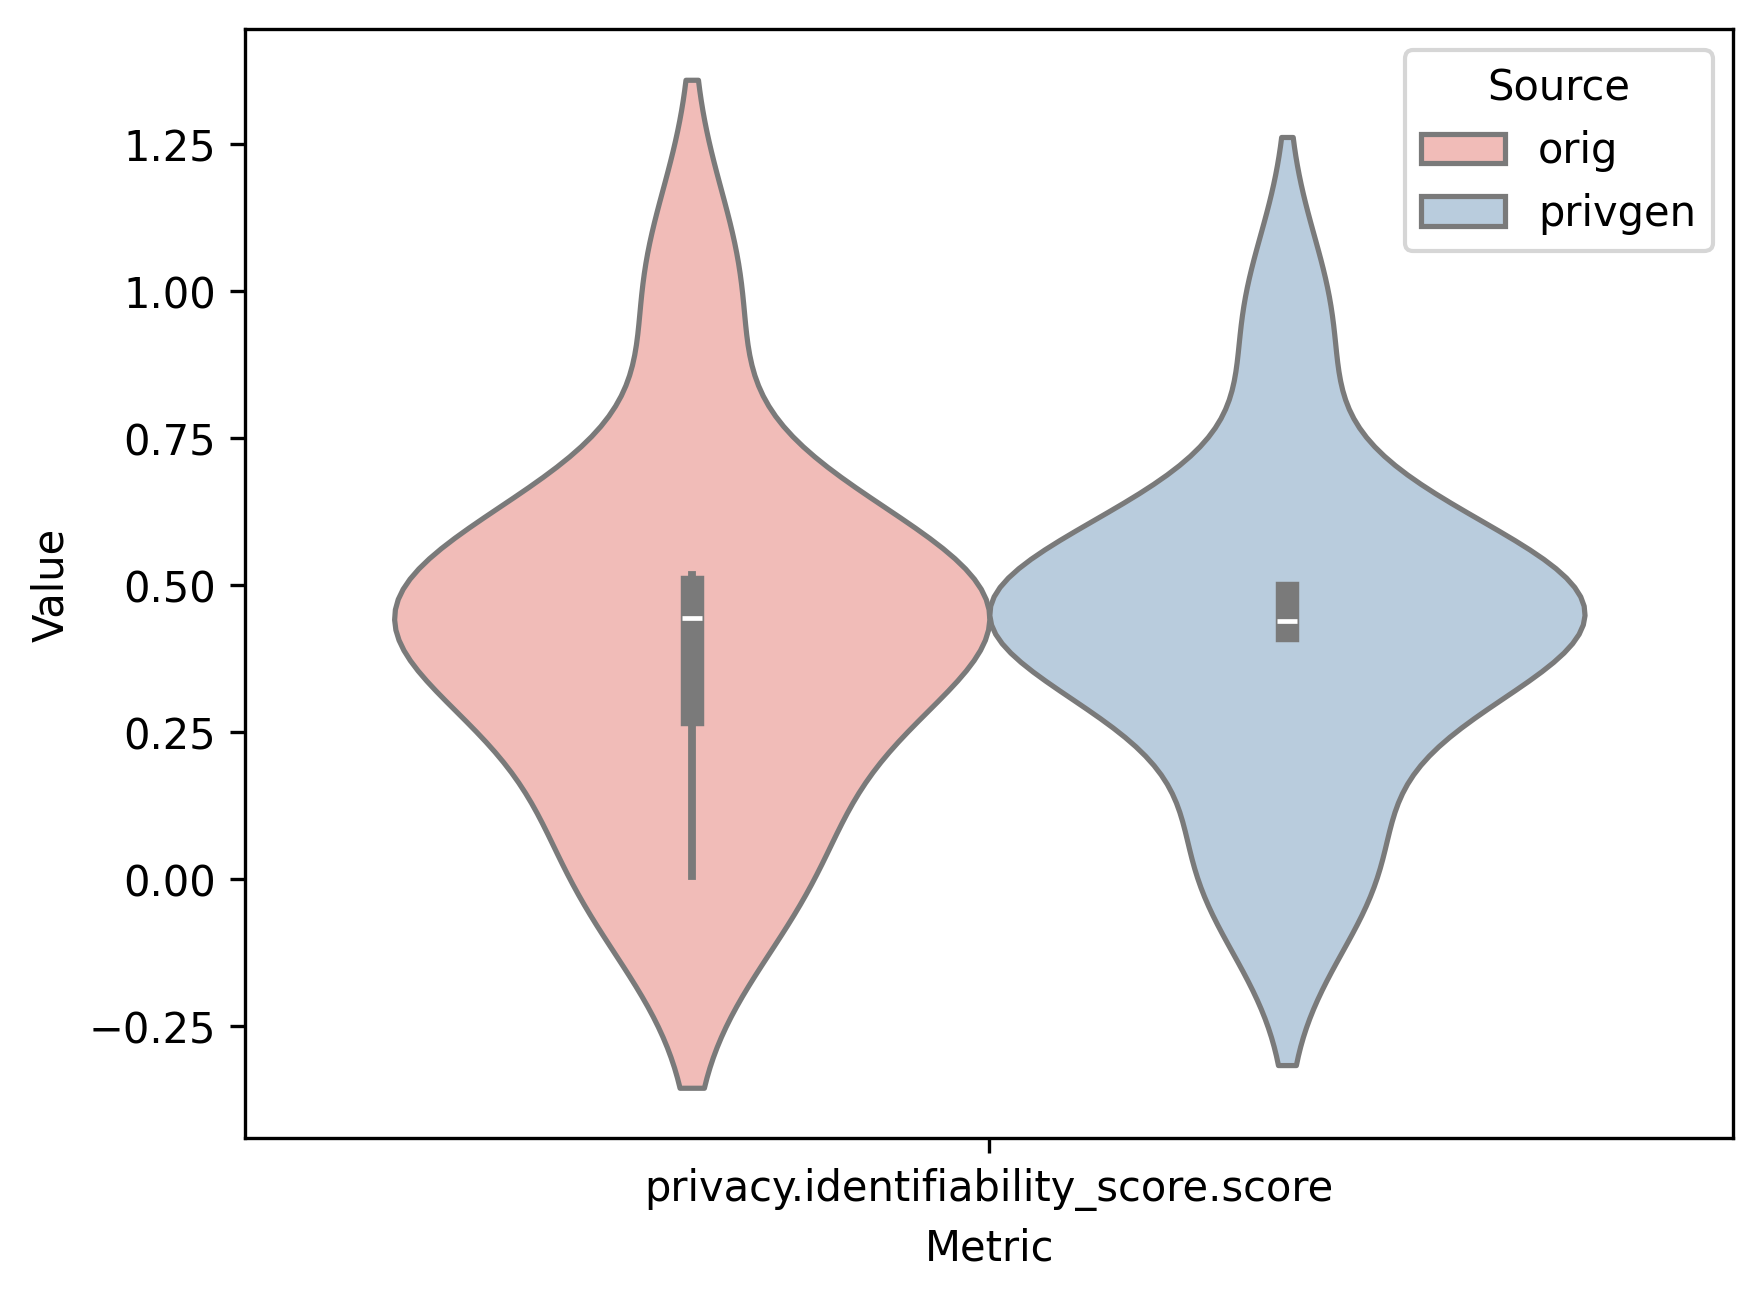

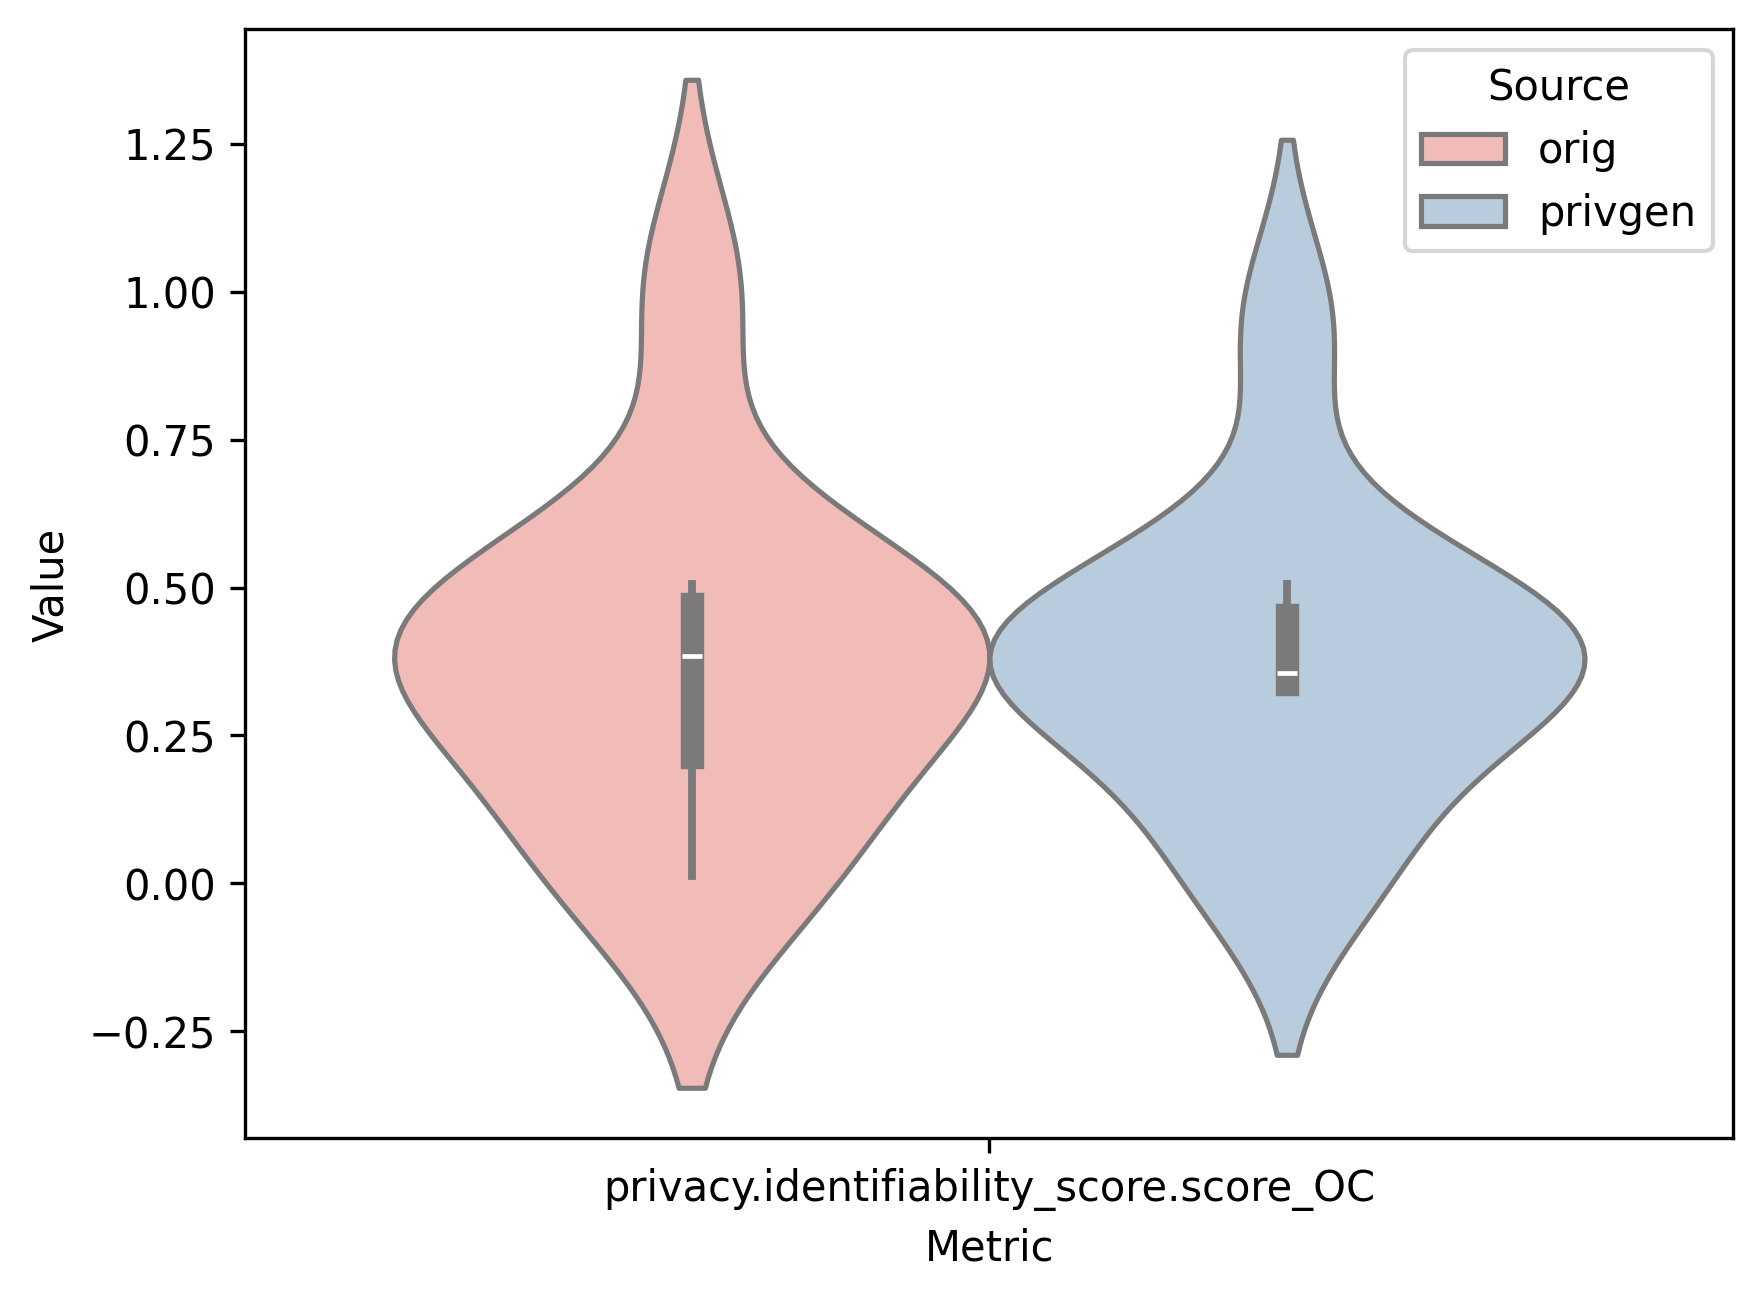

In [33]:
for metric in metrics:
    temp = melted_df[melted_df['Metric'] == metric]

    sns.violinplot(x="Metric",
                   y="Value",
                   hue="Source",
                   data=temp,
                   palette="Pastel1")
    plt.show()

In [35]:
  available_metrics = {
  'sanity': ['data_mismatch', 'common_rows_proportion', 'nearest_syn_neighbor_distance', 'close_values_probability', 'distant_values_probability'],
  'stats': ['jensenshannon_dist', 'chi_squared_test', 'feature_corr', 'inv_kl_divergence', 'ks_test', 'max_mean_discrepancy', 'wasserstein_dist', 'prdc', 'alpha_precision', 'survival_km_distance'],
  'performance': ['linear_model', 'mlp', 'xgb', 'feat_rank_distance'],
  'detection': ['detection_xgb', 'detection_mlp', 'detection_gmm', 'detection_linear'],
  'privacy': ['delta-presence', 'k-anonymization', 'k-map', 'distinct l-diversity', 'identifiability_score']
  }

In [36]:
for cat in available_metrics.keys():
    print(cat)

sanity
stats
performance
detection
privacy


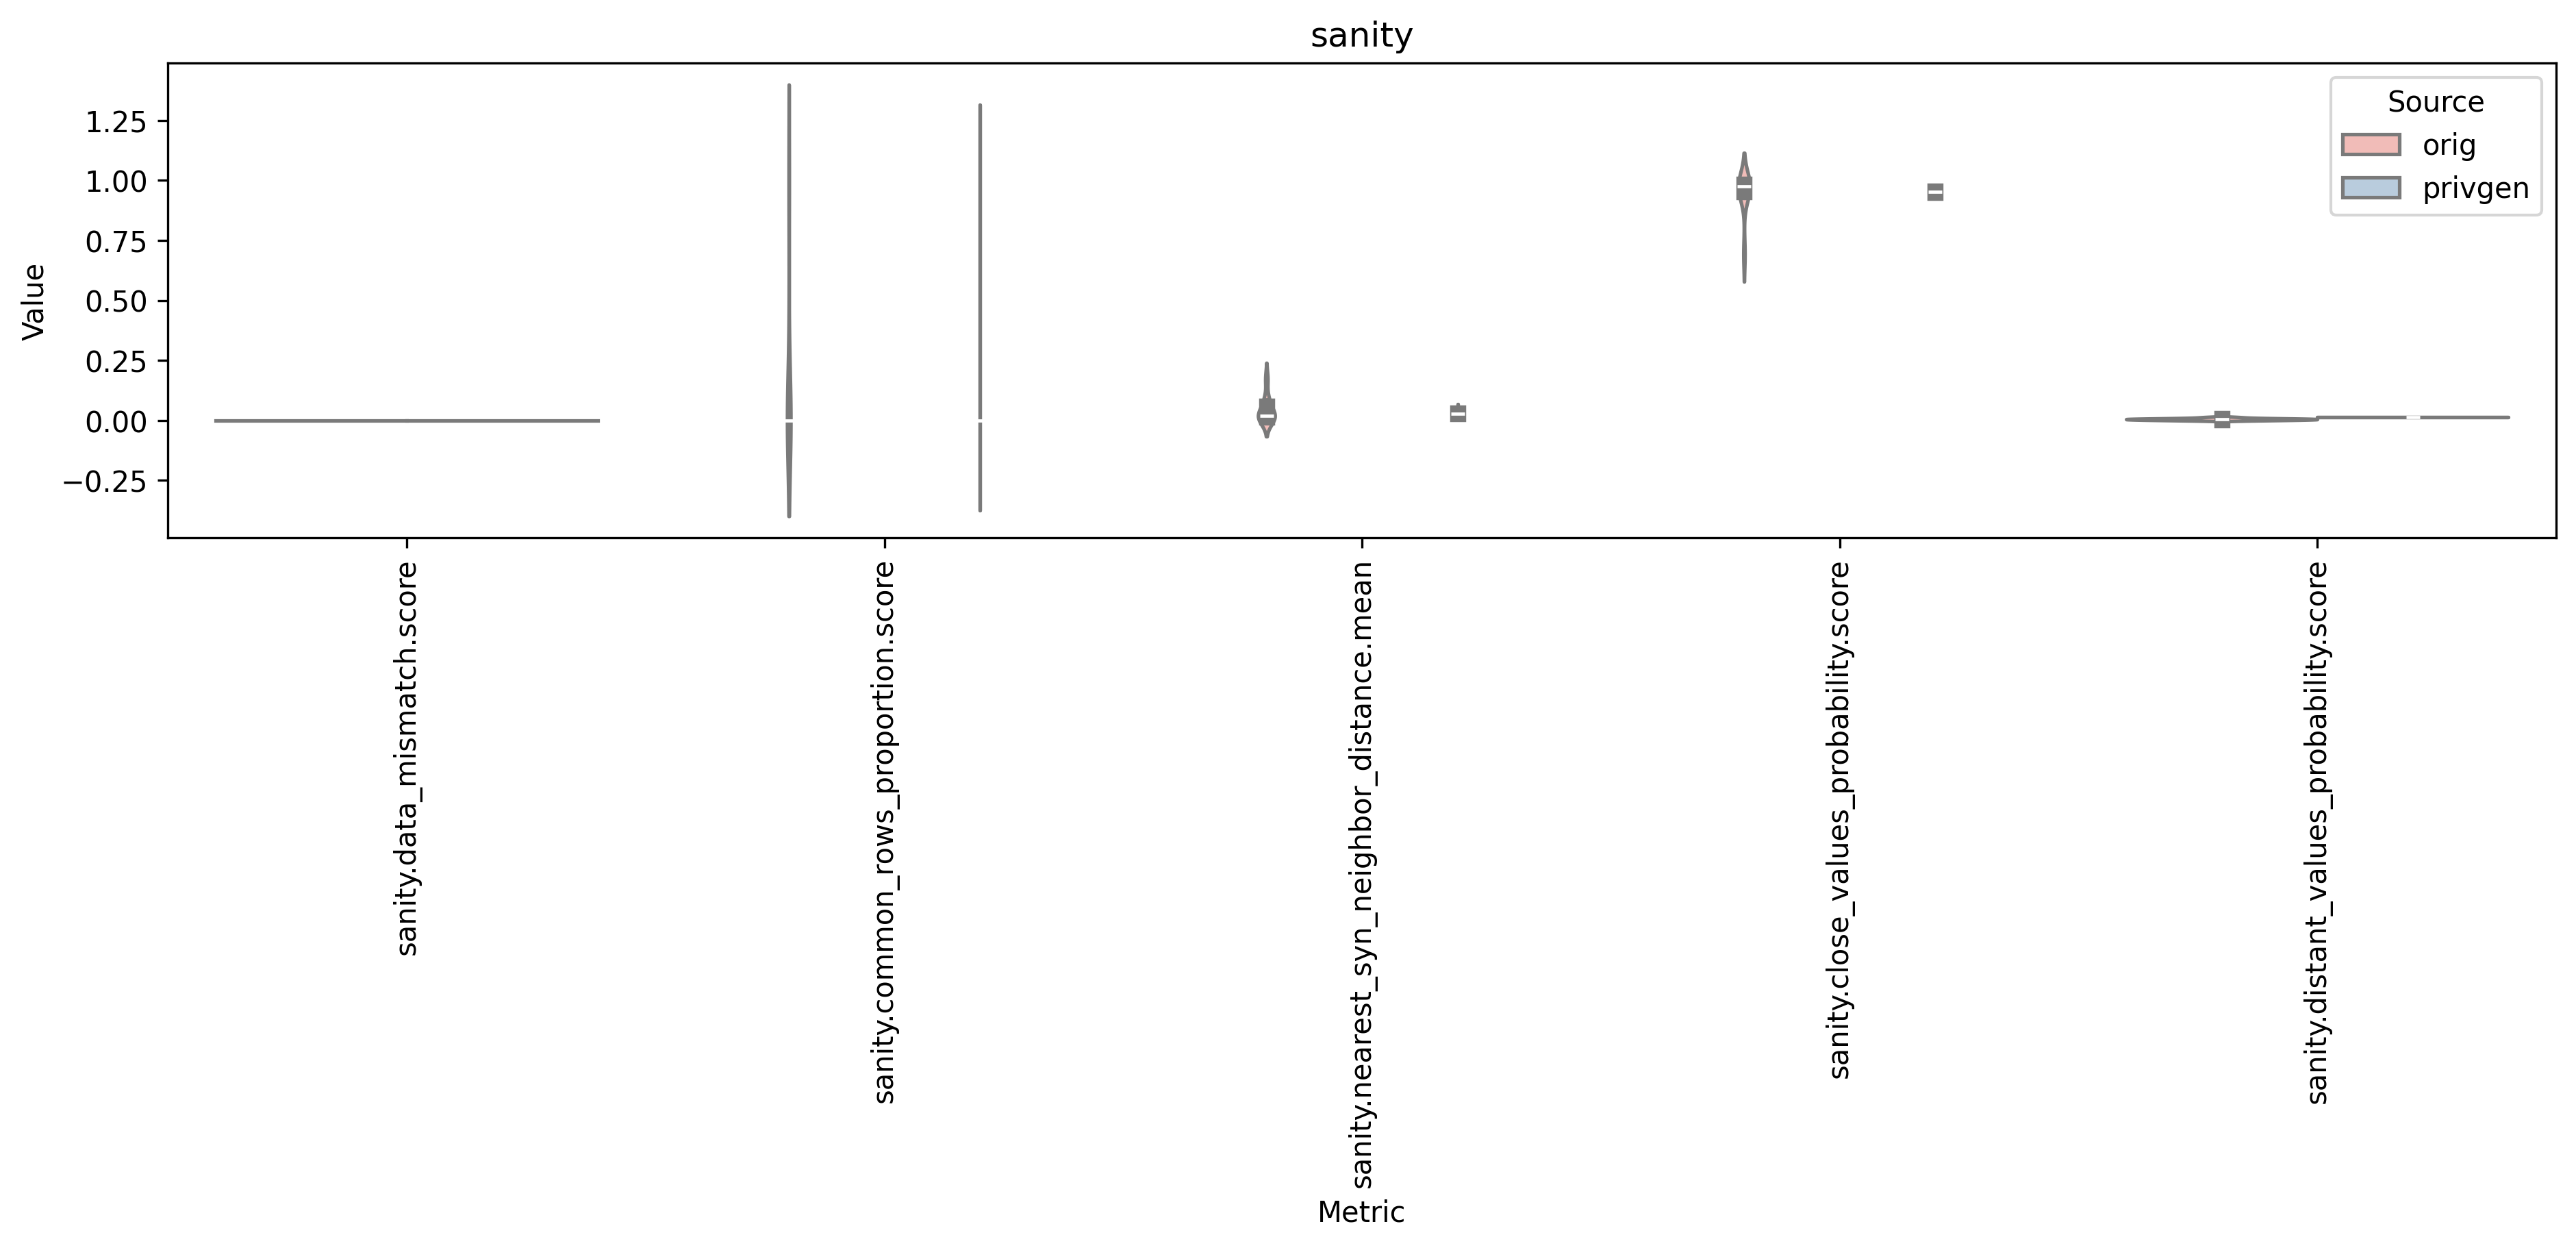

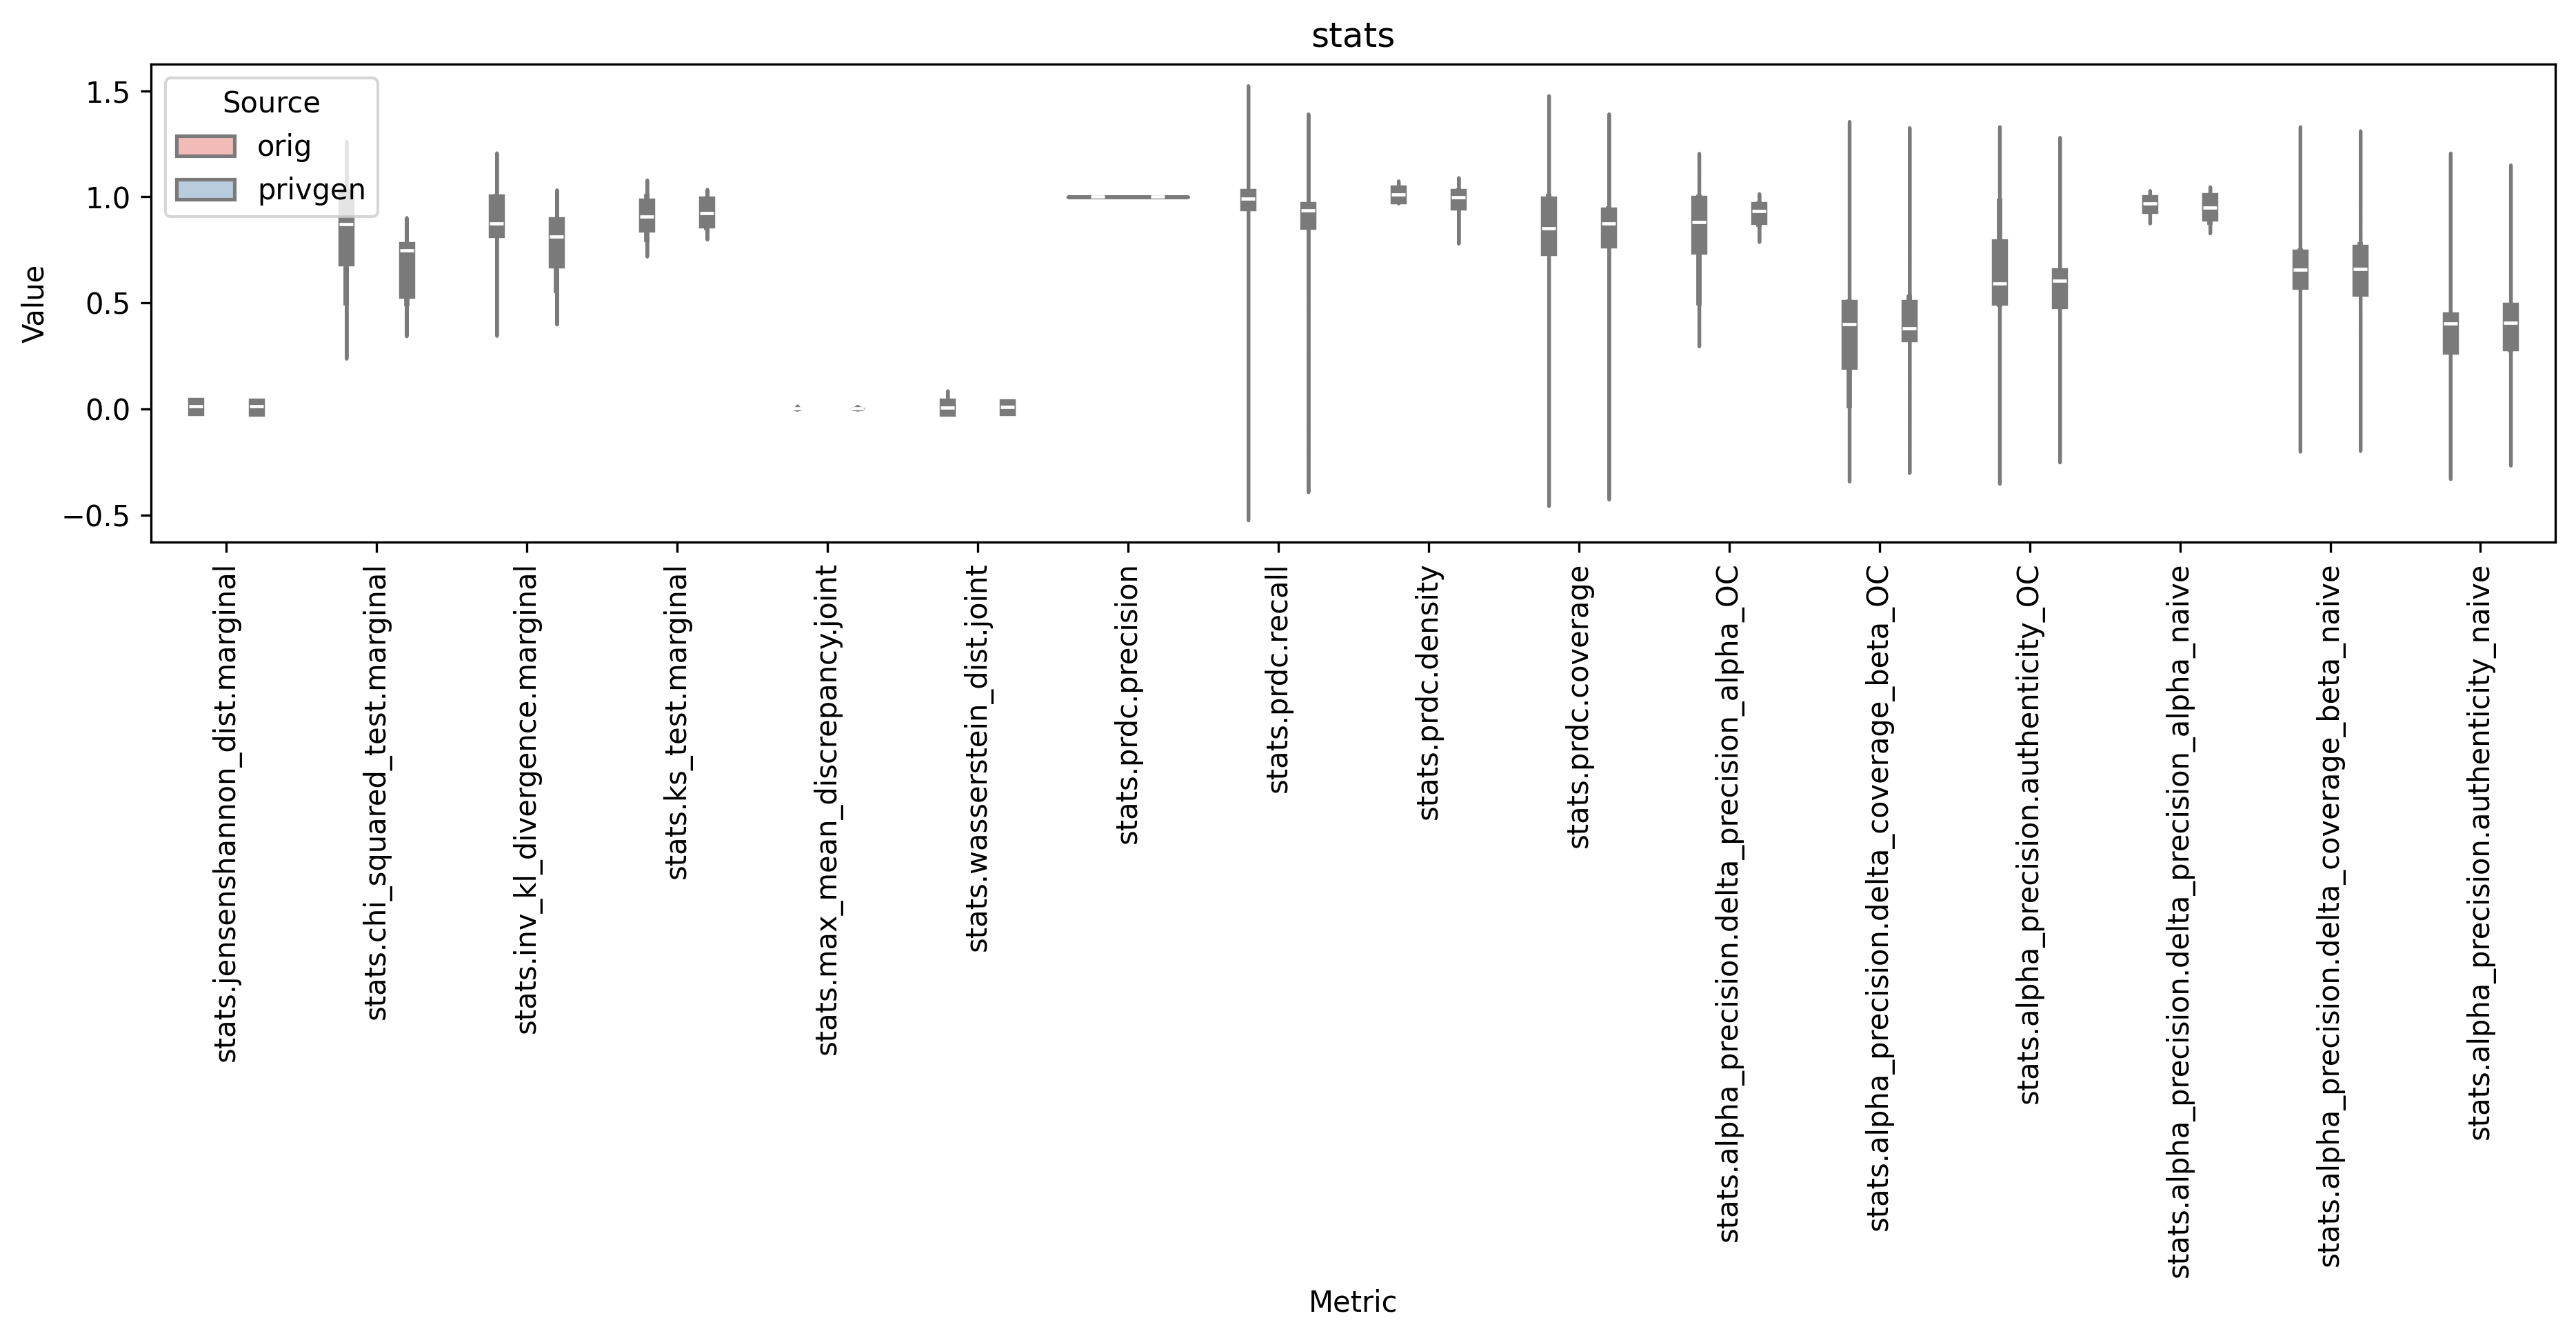

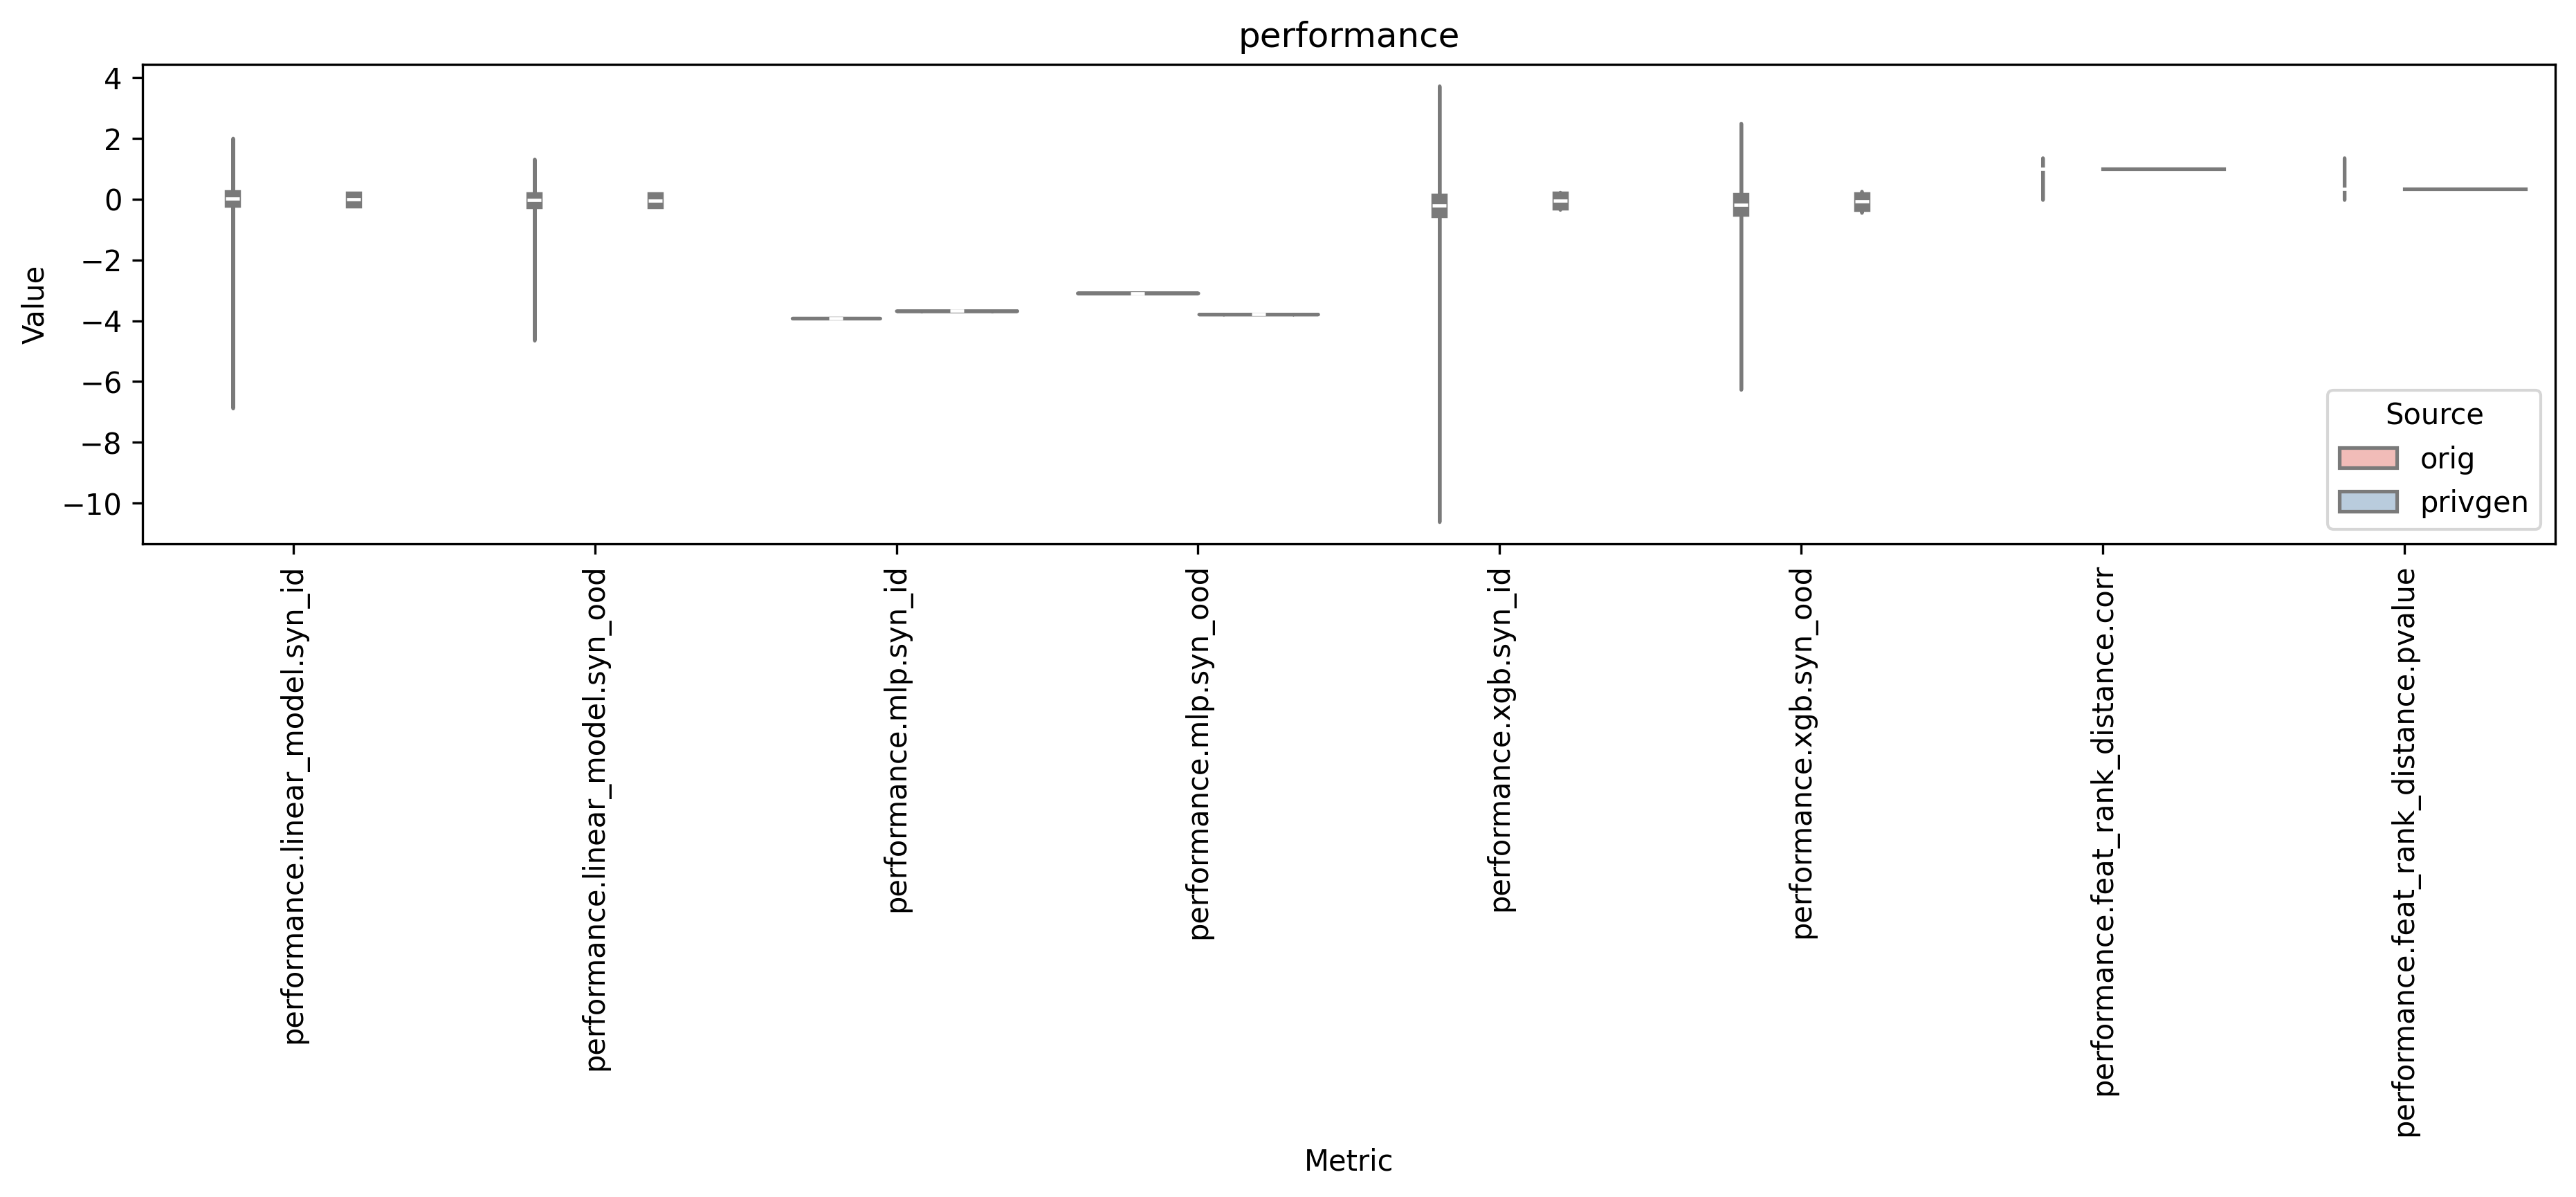

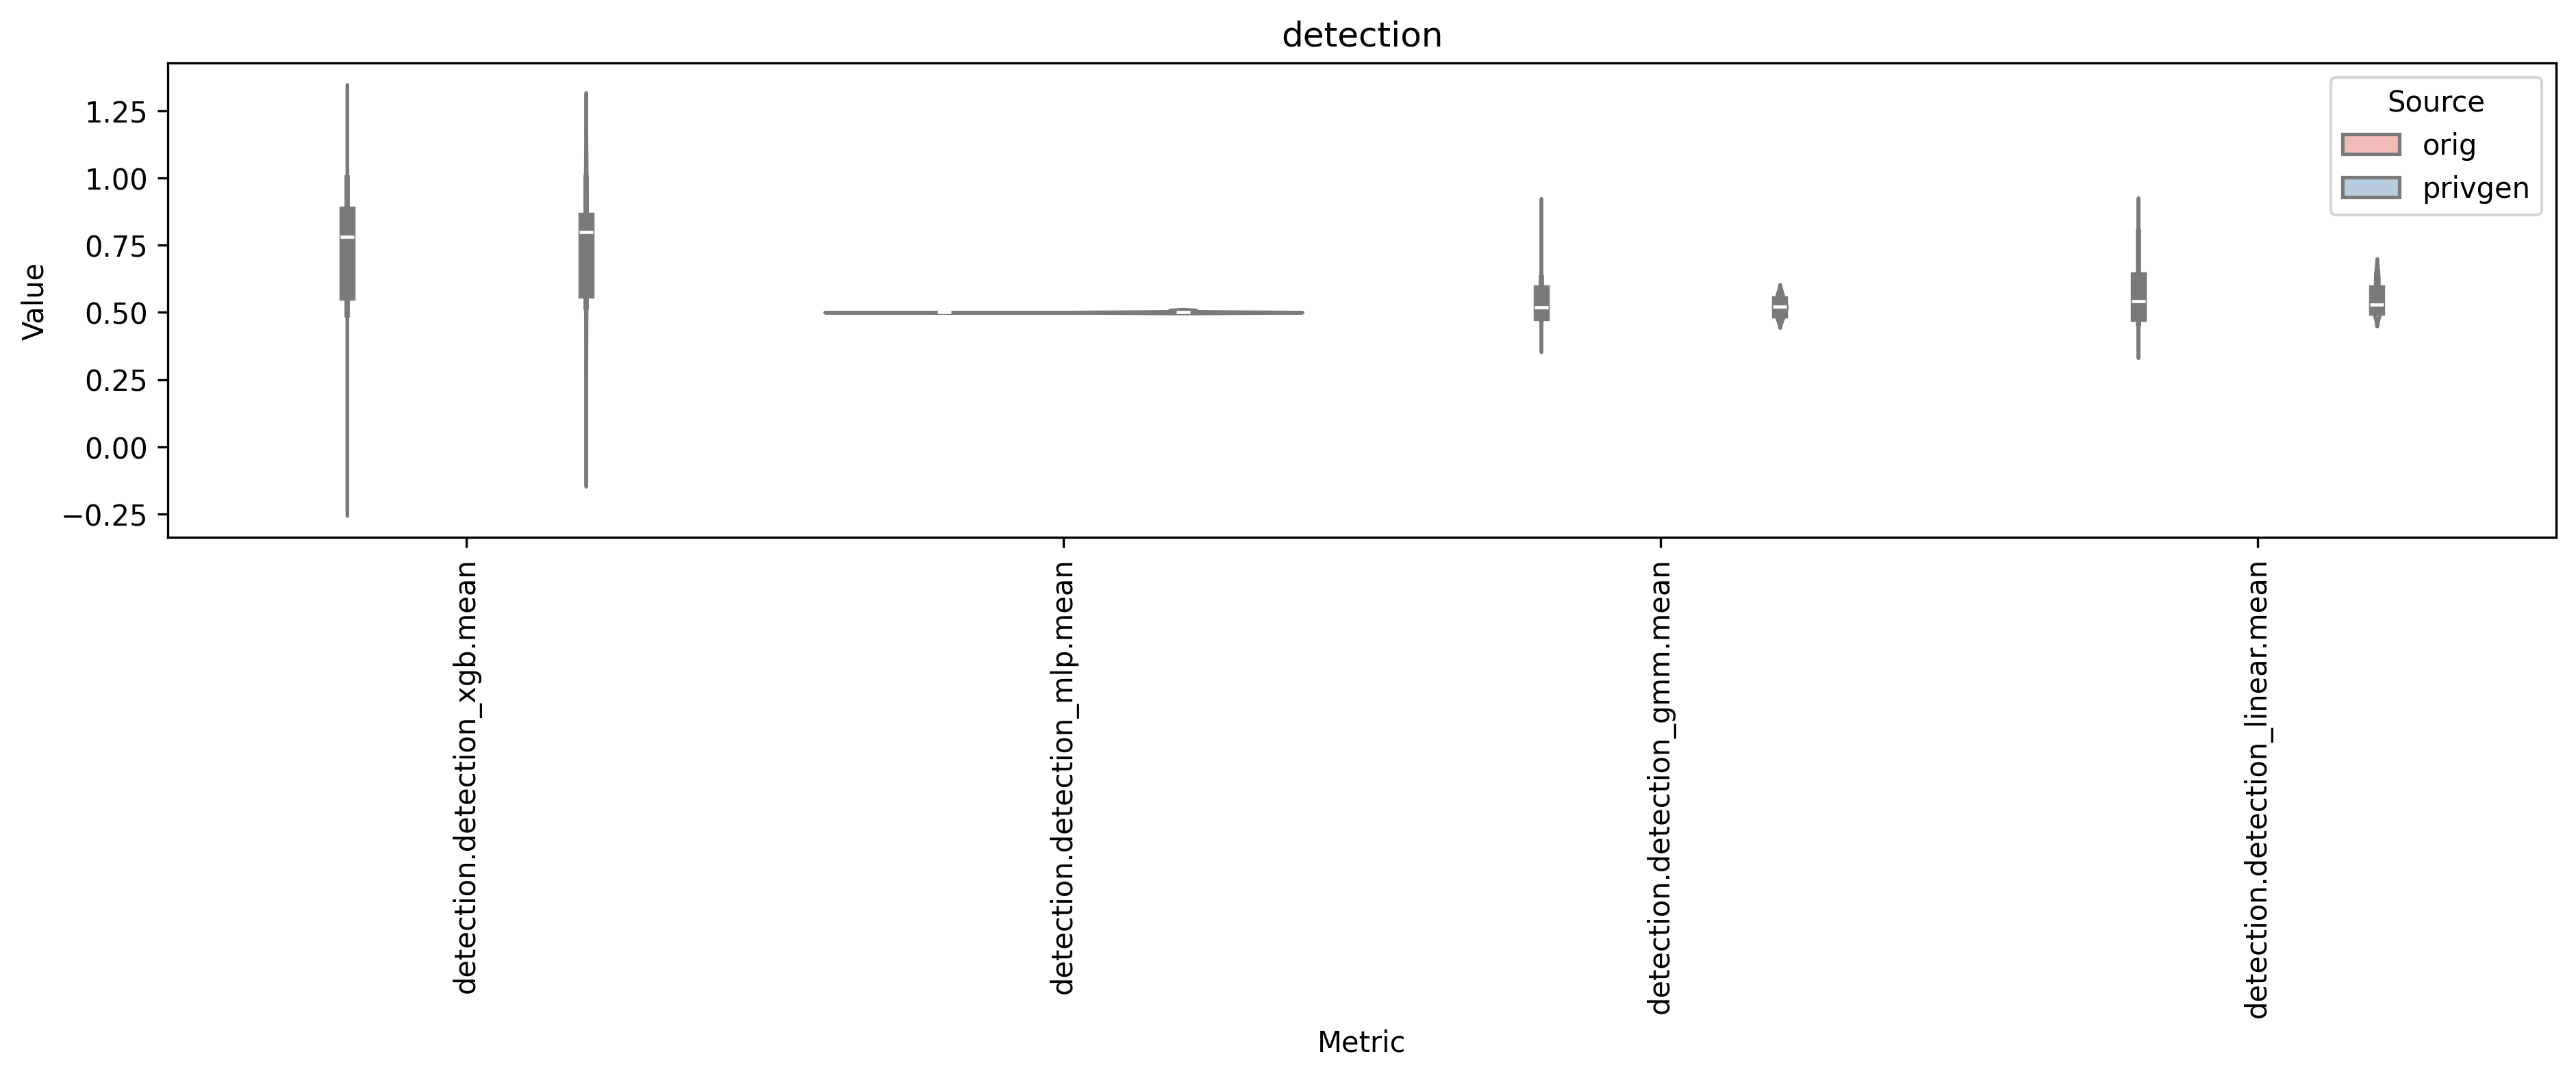

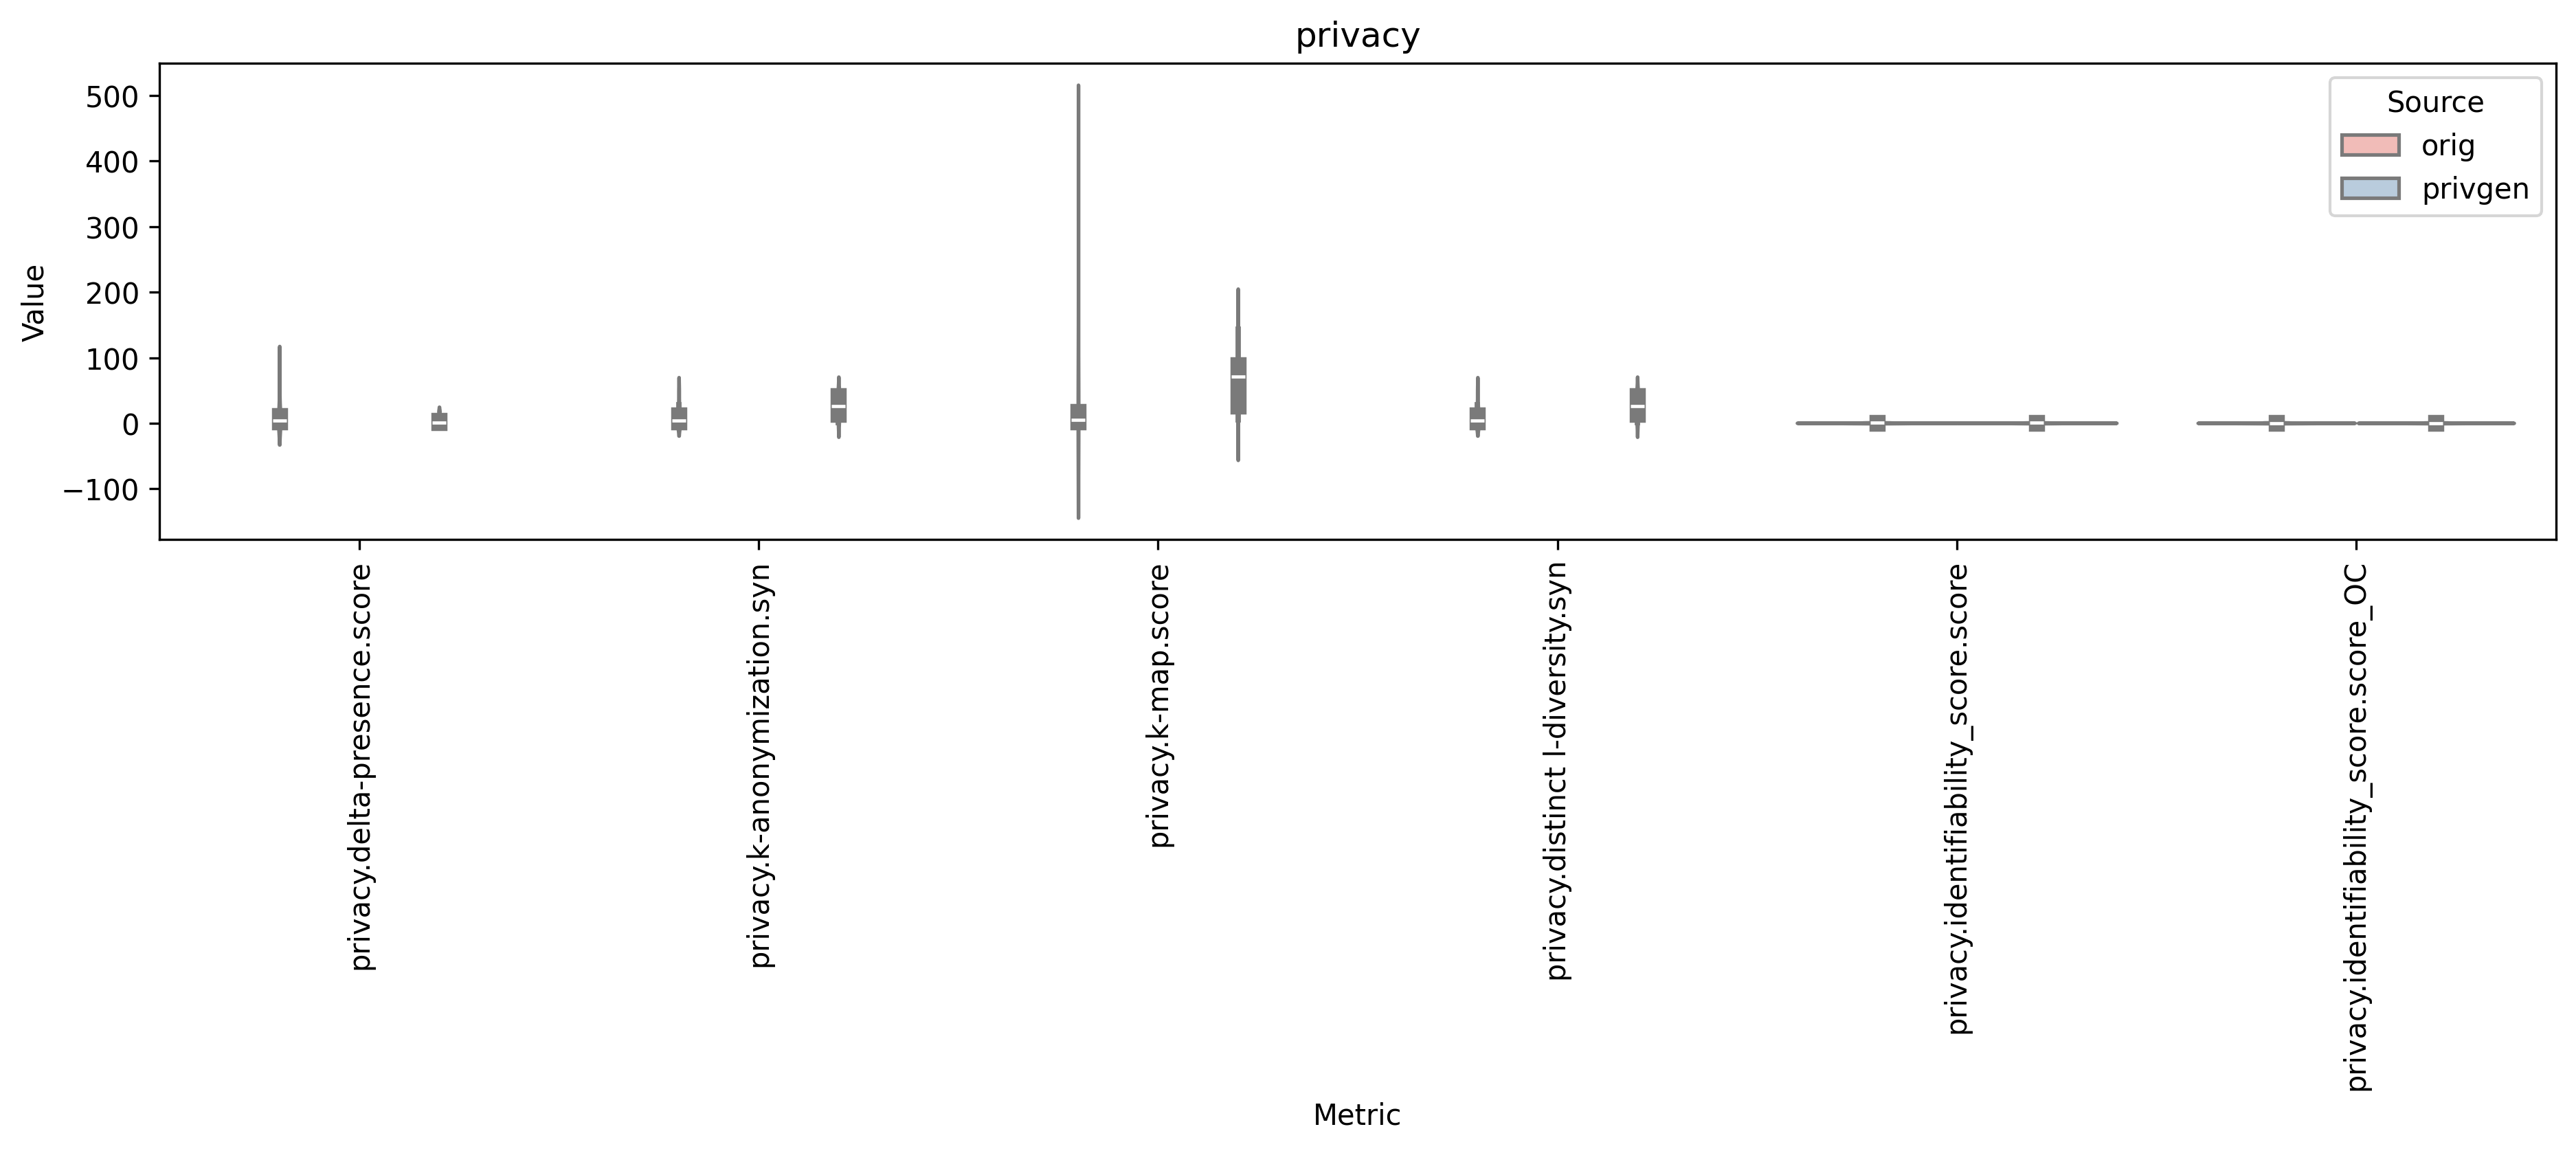

In [41]:
for cat in available_metrics.keys():
    temp = melted_df[melted_df['Metric'].str.startswith(cat)]
    
    # Set the figure size to make it wide and short
    plt.figure(figsize=(15, 3))  # Adjust the width (12) and height (5) as needed
    
    sns.violinplot(
        x="Metric",
        y="Value",
        hue="Source",
        data=temp,
        palette="Pastel1"
    ).set_title(cat)
    
    # Rotate x-axis labels by 90 degrees
    plt.xticks(rotation=90)
    
    plt.show()

In [49]:
df['Metric'].unique().tolist()

['sanity.data_mismatch.score',
 'sanity.common_rows_proportion.score',
 'sanity.nearest_syn_neighbor_distance.mean',
 'sanity.close_values_probability.score',
 'sanity.distant_values_probability.score',
 'stats.jensenshannon_dist.marginal',
 'stats.chi_squared_test.marginal',
 'stats.inv_kl_divergence.marginal',
 'stats.ks_test.marginal',
 'stats.max_mean_discrepancy.joint',
 'stats.wasserstein_dist.joint',
 'stats.prdc.precision',
 'stats.prdc.recall',
 'stats.prdc.density',
 'stats.prdc.coverage',
 'stats.alpha_precision.delta_precision_alpha_OC',
 'stats.alpha_precision.delta_coverage_beta_OC',
 'stats.alpha_precision.authenticity_OC',
 'stats.alpha_precision.delta_precision_alpha_naive',
 'stats.alpha_precision.delta_coverage_beta_naive',
 'stats.alpha_precision.authenticity_naive',
 'performance.linear_model.syn_id',
 'performance.linear_model.syn_ood',
 'performance.mlp.syn_id',
 'performance.mlp.syn_ood',
 'performance.xgb.syn_id',
 'performance.xgb.syn_ood',
 'performance.feat_

In [47]:
import inspect
from synthcity.metrics import (
    eval_sanity,
    eval_statistical,
    eval_performance,
    eval_detection,
    eval_privacy,
    eval_attacks,
)

# List of metric modules
metric_modules = [
    eval_sanity,
    eval_statistical,
    eval_performance,
    eval_detection,
    eval_privacy,
    eval_attacks,
]

# Iterate through each module and its metrics
for module in metric_modules:
    for name, obj in inspect.getmembers(module):
        # Check if the object is a class and is a subclass of MetricEvaluator
        if inspect.isclass(obj) and issubclass(obj, module.MetricEvaluator):
            try:
                # Attempt to call the direction method
                direction = obj.direction()
                print(f"Metric: {name}, Optimal Direction: {direction}")
            except NotImplementedError:
                # Handle cases where direction() is not implemented
                print(f"Metric: {name} does not implement direction()")

Metric: BasicMetricEvaluator does not implement direction()
Metric: CloseValuesProbability, Optimal Direction: maximize
Metric: CommonRowsProportion, Optimal Direction: minimize
Metric: DataMismatchScore, Optimal Direction: minimize
Metric: DistantValuesProbability, Optimal Direction: minimize
Metric: MetricEvaluator, Optimal Direction: None
Metric: NearestSyntheticNeighborDistance, Optimal Direction: minimize
Metric: AlphaPrecision, Optimal Direction: maximize
Metric: ChiSquaredTest, Optimal Direction: maximize
Metric: FrechetInceptionDistance, Optimal Direction: minimize
Metric: InverseKLDivergence, Optimal Direction: maximize
Metric: JensenShannonDistance, Optimal Direction: minimize
Metric: KolmogorovSmirnovTest, Optimal Direction: maximize
Metric: MaximumMeanDiscrepancy, Optimal Direction: minimize
Metric: MetricEvaluator, Optimal Direction: None
Metric: PRDCScore, Optimal Direction: maximize
Metric: StatisticalEvaluator, Optimal Direction: None
Metric: SurvivalKMDistance, Optimal

In [51]:
import inspect
from synthcity.metrics import (
    eval_sanity,
    eval_statistical,
    eval_performance,
    eval_detection,
    eval_privacy,
    eval_attacks,
)

# List of metric modules
metric_modules = [
    eval_sanity,
    eval_statistical,
    eval_performance,
    eval_detection,
    eval_privacy,
    eval_attacks,
]


res = {}
# Iterate through each module and its metrics
for module in metric_modules:
    for name, obj in inspect.getmembers(module):
        # Check if the object is a class and is a subclass of MetricEvaluator
        if inspect.isclass(obj) and issubclass(obj, module.MetricEvaluator):
            try:
                # Attempt to call the direction method
                direction = obj.direction()
                res[name] = direction
            except:
                pass

In [52]:
res

{'CloseValuesProbability': 'maximize',
 'CommonRowsProportion': 'minimize',
 'DataMismatchScore': 'minimize',
 'DistantValuesProbability': 'minimize',
 'MetricEvaluator': None,
 'NearestSyntheticNeighborDistance': 'minimize',
 'AlphaPrecision': 'maximize',
 'ChiSquaredTest': 'maximize',
 'FrechetInceptionDistance': 'minimize',
 'InverseKLDivergence': 'maximize',
 'JensenShannonDistance': 'minimize',
 'KolmogorovSmirnovTest': 'maximize',
 'MaximumMeanDiscrepancy': 'minimize',
 'PRDCScore': 'maximize',
 'StatisticalEvaluator': None,
 'SurvivalKMDistance': 'minimize',
 'WassersteinDistance': 'minimize',
 'AugmentationPerformanceEvaluatorLinear': 'maximize',
 'AugmentationPerformanceEvaluatorMLP': 'maximize',
 'AugmentationPerformanceEvaluatorXGB': 'maximize',
 'FeatureImportanceRankDistance': 'minimize',
 'PerformanceEvaluator': 'maximize',
 'PerformanceEvaluatorLinear': 'maximize',
 'PerformanceEvaluatorMLP': 'maximize',
 'PerformanceEvaluatorXGB': 'maximize',
 'DetectionEvaluator': 'min

In [46]:
available_metrics['sanity']

['data_mismatch',
 'common_rows_proportion',
 'nearest_syn_neighbor_distance',
 'close_values_probability',
 'distant_values_probability']